# 🏥 Medical RAG Question Answering System
## Progetto Finale di Master — Clinical Document QA con RAG e Fine-Tuning


| Campo | Valore |
|-------|--------|
| **Modello generativo** | `BioMistral/BioMistral-7B` — pretraining su PubMed + PMC |
| **Encoder retrieval** | `pritamdeka/S-PubMedBert-MS-MARCO` — dominio biomedico |
| **Dataset** | MIMIC-III de-identificato (HIPAA-compliant) — ~100.000 note cliniche reali |
| **Hardware** | Kaggle 2× T4 GPU — 16 GB VRAM |
| **Fine-tuning** | QLoRA via Unsloth — 2× speed, −40% VRAM |

---

### Architettura generale della pipeline

```
┌──────────────────────────────────────────────────────────────────┐
│                      MEDICAL RAG PIPELINE                        │
│                                                                  │
│  Domanda clinica (query q)                                       │
│         │                                                        │
│         ▼                                                        │
│  ┌─────────────────────────────────────────────────────────┐    │
│  │            HYBRID RETRIEVER (Sezione 4)                │    │
│  │                                                          │    │
│  │   BM25 Okapi ──► ranking_BM25(q, K)                     │    │
│  │   PubMedBERT  ──► ranking_Dense(q, K)  [FAISS IVF/Flat] │    │
│  │                         │                               │    │
│  │                         ▼                               │    │
│  │               Reciprocal Rank Fusion                    │    │
│  │         score(d) = Σᵢ wᵢ / (k + rankᵢ(d))              │    │
│  └─────────────────────────────────────────────────────────┘    │
│         │                                                        │
│         ▼  Top-K chunks filtrati per HADM_ID                     │
│  ┌──────────────────────────────────────────────────────────┐   │
│  │             PROMPT ENGINEERING (Sezione 5)               │   │
│  │   System prompt clinico + Context budget tokenizer       │   │
│  └──────────────────────────────────────────────────────────┘   │
│         │                                                        │
│         ▼                                                        │
│  ┌──────────────────────────────────────────────────────────┐   │
│  │         BioMistral-7B (4-bit QLoRA) (Sezione 5, 8)      │   │
│  └──────────────────────────────────────────────────────────┘   │
│         │                                                        │
│         ▼                                                        │
│   Risposta grounded  ──oppure──  NO_ANSWER                       │
│                                                                  │
└──────────────────────────────────────────────────────────────────┘
```

### Sistemi confrontati

| # | Sistema | Retrieval | Modello |
|---|---------|-----------|---------| 
| S1 | Baseline Prompt-Only | nessuno | BioMistral-7B |
| S2 | RAG BM25 | BM25 Okapi | BioMistral-7B |
| S3 | RAG Hybrid RRF | BM25 + PubMedBERT | BioMistral-7B |
| S4 | RAG + QLoRA FT | Hybrid RRF | BioMistral-7B fine-tuned |
| S5 | Adaptive Router | BM25/Dense/Hybrid dinamico | BioMistral-7B fine-tuned |

> **Nota privacy:** MIMIC-III è de-identificato secondo lo standard HIPAA Safe Harbor.
> Nessun dato PHI (*Protected Health Information*) viene processato in forma identificabile.
> Cfr. *Johnson et al., 2016* per la procedura di anonimizzazione.


### Figura 1 — Schema formale dell'architettura RAG

Lo schema seguente illustra la biforcazione fondamentale tra il modulo di **Recupero delle Informazioni** (*Retriever*, ramo sinistro in blu) e il modulo di **Generazione** (*Generator*, ramo destro in rosso), che costituisce il principio architetturale alla base del paradigma RAG (*Lewis et al., 2020*).

![Architettura del Sistema RAG](https://raw.githubusercontent.com/NicolaM99/medical-rag-qa/refs/heads/main/architettura.svg)

> **Lettura del diagramma.** La query clinica percorre simultaneamente i due rami:
> il *Retriever* recupera i frammenti più rilevanti dalla Knowledge Base (MIMIC-III) tramite
> Reciprocal Rank Fusion di BM25 e PubMedBERT; il *Generator* (BioMistral-7B, opzionalmente
> fine-tuned con QLoRA) riceve la query e il contesto recuperato (freccia verde tratteggiata)
> e produce la risposta finale o emette `NO_ANSWER` in assenza di evidenza sufficiente.
> Il pannello inferiore riassume le metriche di valutazione adottate.

## Sezione 1 — Setup e Installazioni

In questa sezione vengono installate e importate tutte le dipendenze necessarie all'esecuzione della pipeline.
L'ambiente è configurato per l'esecuzione su Kaggle con due GPU NVIDIA T4 (16 GB VRAM ciascuna),
sfruttando la libreria **Unsloth** per l'ottimizzazione del fine-tuning in termini di velocità e consumo di memoria.

Le dipendenze principali includono:
- `unsloth` / `trl`: fine-tuning efficiente con SFT (Supervised Fine-Tuning) e LoRA
- `sentence-transformers`: encoding denso dei chunk con S-PubMedBERT
- `rank_bm25`: implementazione Okapi BM25 per il retrieval sparso
- `faiss-gpu`: approximate nearest neighbor search su GPU per il retrieval denso
- `nltk`: tokenizzazione a livello di frase per il chunking
- `evaluate` / `rouge_score`: calcolo metriche ROUGE-L e EM/F1 (SQuAD 2.0)


In [1]:
# ============================================================
# CELL 1.1 — Environment Setup (Kaggle Stable)
# ============================================================
# STRATEGIA: installare prima i pacchetti RAG/ML senza toccare
# torch/numpy preinstallati, poi provare unsloth con --no-deps
# per evitare che trascini numpy 1.26.4 incompatibile.

import os
import sys
import subprocess
import warnings
import logging

# ------------------------------------------------------------
# Environment flags
# ------------------------------------------------------------
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["CUDA_MODULE_LOADING"] = "LAZY"

warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

def pip_install(pkg, extra_args=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q"]
    if extra_args:
        cmd.extend(extra_args)
    cmd.append(pkg)
    subprocess.check_call(cmd)

print("Installing core dependencies...")

# ------------------------------------------------------------
# DO NOT reinstall torch/torchvision/torchaudio/numpy
# Kaggle's preinstalled stack is optimized for T4 GPUs.
# Reinstalling breaks CUDA compatibility and numpy ABI.
# ------------------------------------------------------------

# ------------------------------------------------------------
# Core ML libraries (versioni compatibili con Kaggle runtime)
# ------------------------------------------------------------
pip_install("transformers>=4.46")
pip_install("trl>=0.9.6")
pip_install("accelerate")
pip_install("datasets")

# ------------------------------------------------------------
# RAG stack
# ------------------------------------------------------------
pip_install("sentence-transformers")
pip_install("faiss-cpu")
pip_install("rank-bm25")

# ------------------------------------------------------------
# Fine-tuning stack
# ------------------------------------------------------------
pip_install("peft")
pip_install("bitsandbytes")

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
pip_install("evaluate")
pip_install("rouge-score")
pip_install("scikit-learn")

# ------------------------------------------------------------
# Unsloth: install con --no-deps per evitare downgrade numpy
# Se fallisce, il notebook usa PEFT standard come fallback
# ------------------------------------------------------------
UNSLOTH_AVAILABLE = False
try:
    from unsloth import FastLanguageModel
    UNSLOTH_AVAILABLE = True
    print("Unsloth: gia' disponibile")
except (ImportError, Exception):
    try:
        # unsloth_zoo: installa normalmente (non trascina numpy)
        pip_install("unsloth_zoo")
        # unsloth: installa con --no-deps perché le sue dipendenze
        # (torch, numpy, triton) sono già nel runtime Kaggle.
        # Senza --no-deps, pip forza numpy<2.0 rompendo l'ABI.
        pip_install("unsloth", extra_args=["--no-deps"])
        from unsloth import FastLanguageModel
        UNSLOTH_AVAILABLE = True
        print("Unsloth: installato (zoo normale + unsloth --no-deps)")
    except Exception as e:
        print(f"Unsloth non disponibile: {e}")
        print("  → Il notebook userà PEFT/bitsandbytes standard come fallback")
        UNSLOTH_AVAILABLE = False

print(f"\nSetup completato.")
print(f"  Unsloth: {'disponibile' if UNSLOTH_AVAILABLE else 'NON disponibile (fallback PEFT)'}")


Installing core dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 42.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 32.4 MB/s eta 0:00:00
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: installato (zoo normale + unsloth --no-deps)

Setup completato.
  Unsloth: disponibile


In [2]:
# CELL 1.2 — Import e configurazione globale (improved)

import os, re, json, random, string, warnings, inspect
from collections import defaultdict
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
import torch

# ── NLTK resources ───────────────────────────────────────────────────────────
import nltk
for _r in ("punkt_tab", "punkt", "stopwords"):
    try:
        nltk.download(_r, quiet=True)
    except Exception:
        pass

# ── Warning selettivi (non silenziare tutto!) ────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*tokenizer.*")
warnings.filterwarnings("ignore", category=UserWarning, message=".*TypedStorage.*")

# ── Configurazione centralizzata ─────────────────────────────────────────────
@dataclass
class Config:
    # Riproducibilità
    seed: int = 42

    # Modelli
    base_llm: str = "BioMistral/BioMistral-7B"
    dense_encoder: str = "pritamdeka/S-PubMedBert-MS-MARCO"
    fallback_encoder: str = "sentence-transformers/all-MiniLM-L6-v2"

    # Retrieval
    chunk_size: int = 512       # 256 troppo piccolo per testi biomedici
    chunk_overlap: int = 100    # ~20% overlap su 512
    top_k: int = 5              # 3 troppo conservativo, rerank dopo
    no_answer_token: str = "NO_ANSWER"

    # Paths Kaggle
    output_dir: str = "/kaggle/working"

    @property
    def adapter_dir(self) -> str:
        return f"{self.output_dir}/biomistral_lora"

    @property
    def ft_ckpt_dir(self) -> str:
        return f"{self.output_dir}/biomistral_ft"

cfg = Config()

# Recupera flag Unsloth dalla cella di setup
if 'UNSLOTH_AVAILABLE' not in dir():
    UNSLOTH_AVAILABLE = False

# ── Seed globale (riproducibilità completa) ──────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(cfg.seed)

# ── GPU setup ────────────────────────────────────────────────────────────────
# Nota: CUDA_VISIBLE_DEVICES rimosso — Unsloth gestisce il device_map
# e il DenseRetriever usa la logica single/multi-GPU dinamicamente.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPU = torch.cuda.device_count()

os.makedirs(cfg.output_dir, exist_ok=True)

# ── Diagnostica ──────────────────────────────────────────────────────────────
print(f"Device: {DEVICE} | GPU visibili: {N_GPU}")
if DEVICE == "cuda":
    for i in range(N_GPU):
        p = torch.cuda.get_device_properties(i)
        vram_gb = p.total_memory / 1e9
        print(f"  GPU {i}: {p.name} — {vram_gb:.1f} GB")
        if vram_gb < 14:
            print(f"   VRAM bassa: potrebbe servire aggressive quantization")

print(f"\nConfigurazione:")
for k, v in asdict(cfg).items():
    print(f"  {k:20s}: {v}")
print("\n Configurazione OK")

Device: cuda | GPU visibili: 2
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB

Configurazione:
  seed                : 42
  base_llm            : BioMistral/BioMistral-7B
  dense_encoder       : pritamdeka/S-PubMedBert-MS-MARCO
  fallback_encoder    : sentence-transformers/all-MiniLM-L6-v2
  chunk_size          : 512
  chunk_overlap       : 100
  top_k               : 5
  no_answer_token     : NO_ANSWER
  output_dir          : /kaggle/working

 Configurazione OK


## Sezione 2 — Dataset: MIMIC-III Clinical Notes

### 2.1 Descrizione del dataset

**MIMIC-III** (*Medical Information Mart for Intensive Care*, versione III) è un database clinico
open-access contenente dati anonimi di oltre 40.000 pazienti ricoverati in unità di terapia
intensiva (ICU) al Beth Israel Deaconess Medical Center (BIDMC) di Boston tra il 2001 e il 2012
(*Johnson et al., 2016*).

Il dataset include note cliniche in testo libero — note di dimissione, referti radiologici,
note infermieristiche — nelle quali tutte le entità PHI (*Protected Health Information*) sono
state sostituite con placeholder nella forma `[**tipo_entità**]`, in conformità con lo
standard **HIPAA Safe Harbor** (45 CFR § 164.514(b)).

### 2.2 Strategia di generazione delle coppie Q&A

Le coppie domanda-risposta vengono estratte automaticamente dalle note cliniche
tramite pattern *regex* specializzati per quattro categorie semantiche:

| Categoria | Esempio di pattern | Esempio di Q&A |
|-----------|--------------------|----------------|
| Valori di laboratorio | `WBC: 12.3 K/uL` | Q: "What is the WBC?" → A: "12.3 K/uL" |
| Farmaci e dosaggi | `Metoprolol 25 mg PO BID` | Q: "What is the dose of Metoprolol?" → A: "25 mg PO BID" |
| Diagnosi e procedure | `Diagnosis: NSTEMI` | Q: "What is the primary diagnosis?" → A: "NSTEMI" |
| Segni vitali | `BP: 130/85 mmHg` | Q: "What is the blood pressure?" → A: "130/85 mmHg" |

Questa strategia garantisce che le coppie siano **ancorate al testo** della nota corrispondente
(identificata da `HADM_ID`), evitando il fenomeno del *label leakage* tra train e test set.


In [3]:
# CELL 2.1 — Caricamento Dati MIMIC-III (improved)

import glob
import traceback

# ── 1. Cerca il CSV con glob robusto ─────────────────────────────────────────
real_candidates = glob.glob("/kaggle/input/**/NOTEEVENTS*.csv", recursive=True)
real_path = real_candidates[0] if real_candidates else None

df_real = pd.DataFrame(columns=["HADM_ID", "SUBJECT_ID", "TEXT", "CATEGORY"])

if real_path and os.path.exists(real_path):
    print(f"📂 File trovato: {real_path}")
    print(f"   Dimensione: {os.path.getsize(real_path) / 1e6:.1f} MB")

    try:
        # ── Carica solo le colonne necessarie con dtype espliciti ─────────
        # Leggiamo le colonne header per normalizzare prima del caricamento
        header = pd.read_csv(real_path, nrows=0)
        header.columns = [c.strip().upper() for c in header.columns]
        available_cols = header.columns.tolist()

        usecols_map = {}  # original_name -> normalized_name
        for col in ["HADM_ID", "SUBJECT_ID", "TEXT", "CATEGORY"]:
            # Trova la colonna originale (pre-normalizzazione)
            raw_header = pd.read_csv(real_path, nrows=0).columns.tolist()
            for raw_col in raw_header:
                if raw_col.strip().upper() == col:
                    usecols_map[raw_col] = col
                    break

        df_raw = pd.read_csv(
            real_path,
            usecols=list(usecols_map.keys()),
            dtype={k: "str" for k in usecols_map.keys()},  # tutto stringa, cast dopo
            low_memory=True,
        )
        df_raw.columns = [usecols_map.get(c, c.strip().upper()) for c in df_raw.columns]

        # ── Colonne mancanti: aggiungi placeholder ───────────────────────
        for col in ["HADM_ID", "SUBJECT_ID", "TEXT", "CATEGORY"]:
            if col not in df_raw.columns:
                df_raw[col] = ""
                print(f"   ⚠️  Colonna '{col}' non trovata, aggiunto placeholder")

        df_real = df_raw[["HADM_ID", "SUBJECT_ID", "TEXT", "CATEGORY"]].copy()

        # ── Pulizia robusta ──────────────────────────────────────────────
        # Drop righe senza testo o HADM_ID
        df_real = df_real.dropna(subset=["TEXT", "HADM_ID"])
        df_real = df_real[df_real["TEXT"].str.strip().str.len() > 0]

        # Cast sicuro con pd.to_numeric
        df_real["HADM_ID"] = pd.to_numeric(df_real["HADM_ID"], errors="coerce")
        df_real["SUBJECT_ID"] = pd.to_numeric(df_real["SUBJECT_ID"], errors="coerce")
        df_real = df_real.dropna(subset=["HADM_ID"])
        df_real["HADM_ID"] = df_real["HADM_ID"].astype(int)
        df_real["SUBJECT_ID"] = df_real["SUBJECT_ID"].fillna(0).astype(int)

        # ── Filtra note troppo corte (rumore, placeholder, "___") ────────
        MIN_TEXT_LEN = 50
        pre_filter = len(df_real)
        df_real["_text_len"] = df_real["TEXT"].str.len()
        df_real = df_real[df_real["_text_len"] > MIN_TEXT_LEN].copy()
        dropped = pre_filter - len(df_real)
        if dropped > 0:
            print(f"   🗑️  Rimosse {dropped:,} note con < {MIN_TEXT_LEN} caratteri")

        # ── Campionamento se dataset troppo grande ───────────────────────
        MAX_NOTES = getattr(cfg, "max_notes", 100_000)
        if len(df_real) > MAX_NOTES:
            df_real = df_real.sample(MAX_NOTES, random_state=cfg.seed)
            print(f"   📉 Campionate {MAX_NOTES:,} note (da {pre_filter:,}) per vincoli di memoria")

        print(f"\n✅ {len(df_real):,} note caricate con successo.")

    except Exception as e:
        print(f"❌ ERRORE nel caricamento CSV:\n{traceback.format_exc()}")
else:
    print("❌ File MIMIC-III non trovato. Verifica il path del dataset su Kaggle.")

# ── 2. Flag e diagnostica ────────────────────────────────────────────────────
USING_REAL_DATA = len(df_real) > 0
print(f"\nDataset reale disponibile: {USING_REAL_DATA}")

if USING_REAL_DATA:
    print(f"  Pazienti unici  : {df_real['SUBJECT_ID'].nunique():,}")
    print(f"  Ammissioni      : {df_real['HADM_ID'].nunique():,}")
    print(f"  Categorie       : {df_real['CATEGORY'].nunique()}")
    print(f"  Lunghezza testo : media {df_real['_text_len'].mean():.0f} | "
          f"mediana {df_real['_text_len'].median():.0f} | "
          f"max {df_real['_text_len'].max():,} chars")

    # ── Distribuzione categorie (check sbilanciamento) ───────────────────
    print(f"\n📊 Distribuzione categorie:")
    cat_counts = df_real["CATEGORY"].value_counts()
    for cat, count in cat_counts.items():
        pct = count / len(df_real) * 100
        bar = "█" * int(pct / 2)
        print(f"  {cat:25s} {count:>7,} ({pct:5.1f}%) {bar}")

    # ── Quick PHI sanity check ───────────────────────────────────────────
    phi_patterns = {
        "phone":    r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b",
        "email":    r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
        "SSN":      r"\b\d{3}-\d{2}-\d{4}\b",
    }
    sample_texts = df_real["TEXT"].sample(min(5000, len(df_real)), random_state=cfg.seed)
    phi_hits = {}
    for label, pattern in phi_patterns.items():
        hits = sample_texts.str.contains(pattern, regex=True, na=False).sum()
        if hits > 0:
            phi_hits[label] = hits

    if phi_hits:
        print(f"\n⚠️  Potenziali PHI residui (su campione di {len(sample_texts):,} note):")
        for label, hits in phi_hits.items():
            print(f"    {label}: {hits} occorrenze")
        print("    → Valuta ulteriore de-identification prima di condividere il modello")
    else:
        print(f"\n🔒 Nessun PHI evidente su campione di {len(sample_texts):,} note")

    # Cleanup colonna temporanea
    df_real = df_real.drop(columns=["_text_len"])

📂 File trovato: /kaggle/input/datasets/bilal1907/mimic-iii-10k/MIMIC -III (10000 patients)/NOTEEVENTS/NOTEEVENTS_random.csv
   Dimensione: 890.6 MB
   🗑️  Rimosse 1,358 note con < 50 caratteri
   📉 Campionate 100,000 note (da 408,422) per vincoli di memoria

✅ 100,000 note caricate con successo.

Dataset reale disponibile: True
  Pazienti unici  : 9,150
  Ammissioni      : 11,513
  Categorie       : 15
  Lunghezza testo : media 1903 | mediana 1095 | max 55,728 chars

📊 Distribuzione categorie:
  Nursing/other              43,513 ( 43.5%) █████████████████████
  Radiology                  20,496 ( 20.5%) ██████████
  Nursing                    12,342 ( 12.3%) ██████
  Physician                   7,835 (  7.8%) ███
  ECG                         7,393 (  7.4%) ███
  Discharge summary           3,194 (  3.2%) █
  Respiratory                 1,883 (  1.9%) 
  Echo                        1,782 (  1.8%) 
  Nutrition                     526 (  0.5%) 
  General                       455 (  0.5%

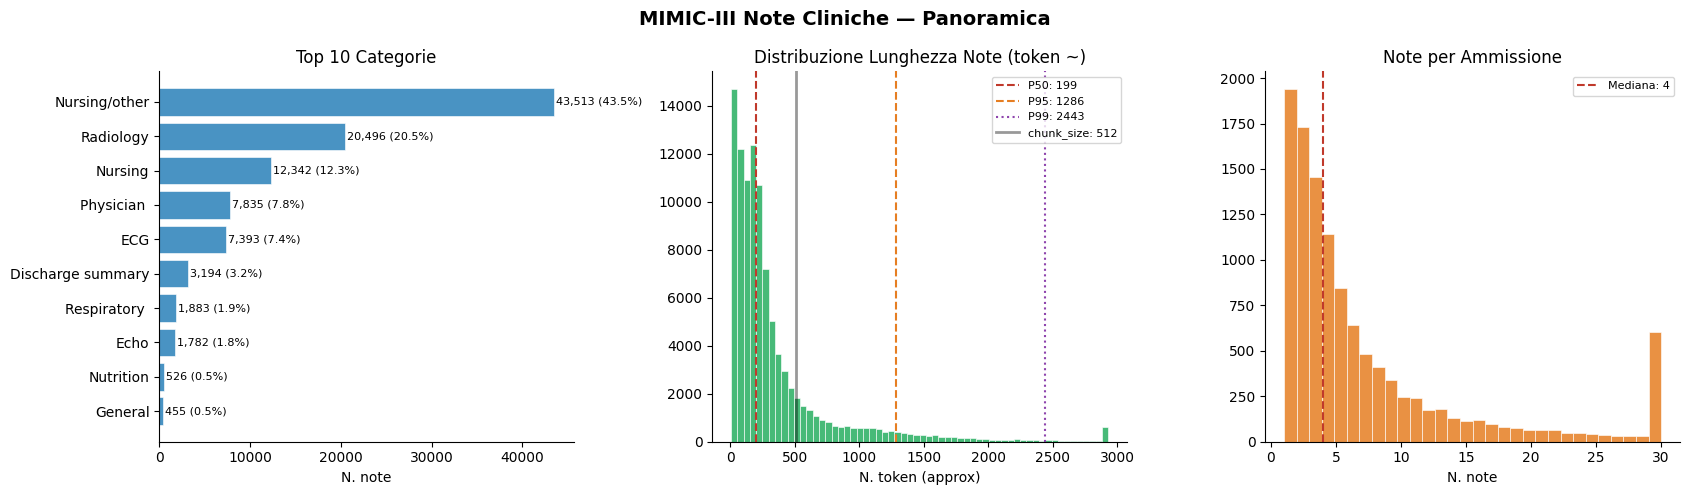

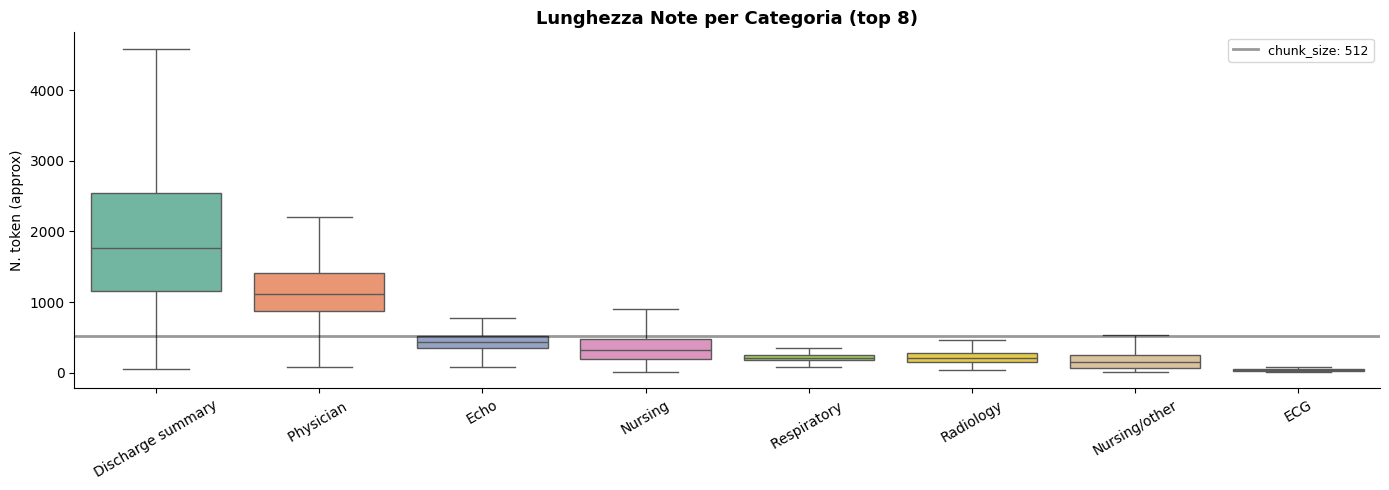

 STATISTICHE LUNGHEZZA NOTE
          Parole   Token (~)
    ------------------------
  Min               5          6
  P25              70         94
  Mediana         148        199
  Media           260        350
  P75             276        372
  P95             953      1,286
  P99           1,810      2,443
  Max           7,661     10,342

 Implicazioni per il RAG:
  chunk_size attuale: 512 token
  Note > chunk_size : 17.4% → queste verranno splittate
  Note ≤ chunk_size : 82.6% → queste resteranno intere
  Chunk medi/nota   : 1.4
  Chunk totali stim.: 144,795


In [4]:
# CELL 2.2 — EDA (Exploratory Data Analysis) del dataset reale (improved)

if USING_REAL_DATA:

    # ── Calcolo metriche (riutilizzabili dopo) ───────────────────────────
    df_real["_n_words"] = df_real["TEXT"].str.split().str.len()
    TOKEN_RATIO = 1.35  # rapporto approssimativo token/parola per testo biomedico
    df_real["_n_tokens_approx"] = (df_real["_n_words"] * TOKEN_RATIO).astype(int)
    notes_per_adm = df_real.groupby("HADM_ID").size()

    # ── Stile globale ────────────────────────────────────────────────────
    plt.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    })
    PALETTE = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#c0392b"]

    # ══════════════════════════════════════════════════════════════════════
    # FIGURA 1 — Panoramica dataset (3 plot)
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("MIMIC-III Note Cliniche — Panoramica", fontweight="bold", fontsize=14)

    # ── 1. Top 10 categorie ──────────────────────────────────────────────
    cat_counts = df_real["CATEGORY"].value_counts().head(10)
    bars = axes[0].barh(
        cat_counts.index[::-1], cat_counts.values[::-1],
        color=PALETTE[0], alpha=0.85, edgecolor="white", linewidth=0.5,
    )
    # Etichette con percentuale
    for bar, val in zip(bars, cat_counts.values[::-1]):
        pct = val / len(df_real) * 100
        axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                     f"{val:,} ({pct:.1f}%)", va="center", fontsize=8)
    axes[0].set_title("Top 10 Categorie")
    axes[0].set_xlabel("N. note")

    # ── 2. Distribuzione lunghezza (token approssimati) ──────────────────
    token_counts = df_real["_n_tokens_approx"]
    p50 = token_counts.median()
    p95 = token_counts.quantile(0.95)
    p99 = token_counts.quantile(0.99)

    axes[1].hist(
        token_counts.clip(upper=int(p99 * 1.2)),
        bins=60, color=PALETTE[1], alpha=0.85, edgecolor="white", linewidth=0.5,
    )
    axes[1].axvline(p50, color="#c0392b", ls="--", lw=1.5, label=f"P50: {p50:.0f}")
    axes[1].axvline(p95, color="#e67e22", ls="--", lw=1.5, label=f"P95: {p95:.0f}")
    axes[1].axvline(p99, color="#8e44ad", ls=":",  lw=1.5, label=f"P99: {p99:.0f}")
    # Linea chunk_size per confronto
    axes[1].axvline(cfg.chunk_size, color="black", ls="-", lw=2, alpha=0.4,
                     label=f"chunk_size: {cfg.chunk_size}")
    axes[1].set_title("Distribuzione Lunghezza Note (token ~)")
    axes[1].set_xlabel("N. token (approx)")
    axes[1].legend(fontsize=8, loc="upper right")

    # ── 3. Note per ammissione ───────────────────────────────────────────
    axes[2].hist(
        notes_per_adm.clip(upper=30), bins=30,
        color=PALETTE[2], alpha=0.85, edgecolor="white", linewidth=0.5,
    )
    axes[2].axvline(notes_per_adm.median(), color="#c0392b", ls="--", lw=1.5,
                     label=f"Mediana: {notes_per_adm.median():.0f}")
    axes[2].set_title("Note per Ammissione")
    axes[2].set_xlabel("N. note")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{cfg.output_dir}/eda_panoramica.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # FIGURA 2 — Lunghezza per categoria (boxplot)
    # ══════════════════════════════════════════════════════════════════════
    top_cats = cat_counts.head(8).index.tolist()
    df_top = df_real[df_real["CATEGORY"].isin(top_cats)].copy()

    # Ordina categorie per mediana lunghezza (decrescente)
    cat_order = (
        df_top.groupby("CATEGORY")["_n_tokens_approx"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig2, ax2 = plt.subplots(figsize=(14, 5))
    sns.boxplot(
        data=df_top, x="CATEGORY", y="_n_tokens_approx", order=cat_order,
        showfliers=False, palette="Set2", ax=ax2,
    )
    ax2.axhline(cfg.chunk_size, color="black", ls="-", lw=2, alpha=0.4,
                label=f"chunk_size: {cfg.chunk_size}")
    ax2.set_title("Lunghezza Note per Categoria (top 8)", fontweight="bold", fontsize=13)
    ax2.set_ylabel("N. token (approx)")
    ax2.set_xlabel("")
    ax2.tick_params(axis="x", rotation=30)
    ax2.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{cfg.output_dir}/eda_length_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ══════════════════════════════════════════════════════════════════════
    # Statistiche riepilogative
    # ══════════════════════════════════════════════════════════════════════
    print("=" * 60)
    print(" STATISTICHE LUNGHEZZA NOTE")
    print("=" * 60)
    print(f"{'':4s}{'Parole':>12s}{'Token (~)':>12s}")
    print(f"{'':4s}{'-'*12:>12s}{'-'*12:>12s}")
    for label, fn in [("Min", "min"), ("P25", lambda s: s.quantile(0.25)),
                       ("Mediana", "median"), ("Media", "mean"),
                       ("P75", lambda s: s.quantile(0.75)),
                       ("P95", lambda s: s.quantile(0.95)),
                       ("P99", lambda s: s.quantile(0.99)),
                       ("Max", "max")]:
        if callable(fn):
            w = fn(df_real["_n_words"])
            t = fn(df_real["_n_tokens_approx"])
        else:
            w = getattr(df_real["_n_words"], fn)()
            t = getattr(df_real["_n_tokens_approx"], fn)()
        print(f"  {label:8s} {w:>10,.0f} {t:>10,.0f}")

    print(f"\n Implicazioni per il RAG:")
    print(f"  chunk_size attuale: {cfg.chunk_size} token")
    pct_over = (df_real["_n_tokens_approx"] > cfg.chunk_size).mean() * 100
    print(f"  Note > chunk_size : {pct_over:.1f}% → queste verranno splittate")
    pct_under = (df_real["_n_tokens_approx"] <= cfg.chunk_size).mean() * 100
    print(f"  Note ≤ chunk_size : {pct_under:.1f}% → queste resteranno intere")

    avg_chunks = np.ceil(df_real["_n_tokens_approx"] / (cfg.chunk_size - cfg.chunk_overlap)).mean()
    print(f"  Chunk medi/nota   : {avg_chunks:.1f}")
    total_chunks = np.ceil(df_real["_n_tokens_approx"] / (cfg.chunk_size - cfg.chunk_overlap)).sum()
    print(f"  Chunk totali stim.: {total_chunks:,.0f}")

    # Cleanup colonne temporanee
    df_real = df_real.drop(columns=["_n_words", "_n_tokens_approx"])

else:
    print("  EDA saltata — dataset reale non disponibile.")

In [5]:
# CELL 2.3 — Generazione automatica Q&A dalle note REALI + sintetiche di fallback (improved)

from nltk.tokenize import sent_tokenize

# ══════════════════════════════════════════════════════════════════════════════
# A) PATTERN DI ESTRAZIONE — 12 categorie cliniche con template multipli
# ══════════════════════════════════════════════════════════════════════════════

EXTRACTION_PATTERNS = [
    # ── Diagnosis ─────────────────────────────────────────────────────────
    {
        "pattern": r"(?:primary diagnosis|final diagnosis|discharge diagnosis|principal diagnosis|admitting diagnosis)\s*[:\-]\s*(.{5,120}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What was the primary diagnosis?",
            "What diagnosis was made for this patient?",
            "What condition was the patient diagnosed with?",
            "What was the principal diagnosis at discharge?",
        ],
        "category": "diagnosis",
    },
    {
        "pattern": r"(?:secondary diagnos[ei]s|other diagnos[ei]s|additional diagnos[ei]s)\s*[:\-]\s*(.{5,120}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What were the secondary diagnoses?",
            "Were there any additional diagnoses?",
            "What other conditions were identified?",
        ],
        "category": "diagnosis",
    },
    # ── Lab values ────────────────────────────────────────────────────────
    {
        "pattern": r"(?:creatinine|cr)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:mg/dL|mg\/dl)?)",
        "q_templates": [
            "What was the creatinine level?",
            "What was the patient's creatinine?",
            "What creatinine value was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:hemoglobin|hgb|hb)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:g/dL|g\/dl)?)",
        "q_templates": [
            "What was the hemoglobin level?",
            "What hemoglobin was recorded?",
            "What was the patient's hemoglobin?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:white blood cell|wbc|white count)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:x\s*10[\^]?\d*(?:/L)?|k/?[uμ]l)?)",
        "q_templates": [
            "What was the white blood cell count?",
            "What was the WBC?",
            "What white cell count was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:potassium|k\+?)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:mEq/L|mmol/L)?)",
        "q_templates": [
            "What was the potassium level?",
            "What potassium value was recorded?",
            "What was the patient's serum potassium?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:sodium|na\+?)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:mEq/L|mmol/L)?)",
        "q_templates": [
            "What was the sodium level?",
            "What sodium value was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:INR)\s*(?:was|of|:|\=)\s*(\d+\.?\d*)",
        "q_templates": [
            "What was the INR?",
            "What INR value was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:lactate)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:mmol/L)?)",
        "q_templates": [
            "What was the lactate level?",
            "What lactate was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:troponin|trop[\s\-]?[iI]?)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:ng/mL|ng\/ml)?)",
        "q_templates": [
            "What was the troponin level?",
            "What troponin value was recorded?",
        ],
        "category": "lab",
    },
    {
        "pattern": r"(?:BNP|pro-?BNP|NT-?proBNP)\s*(?:was|of|:|\=)\s*(\d+\.?\d*\s*(?:pg/mL|pg\/ml)?)",
        "q_templates": [
            "What was the BNP level?",
            "What was the BNP on admission?",
        ],
        "category": "lab",
    },
    # ── Vitals ────────────────────────────────────────────────────────────
    {
        "pattern": r"(?:blood pressure|bp)\s*(?:was|of|:|\=)\s*(\d{2,3}\s*/\s*\d{2,3})",
        "q_templates": [
            "What was the blood pressure?",
            "What blood pressure was recorded?",
            "What was the patient's BP?",
        ],
        "category": "vitals",
    },
    {
        "pattern": r"(?:heart rate|hr|pulse)\s*(?:was|of|:|\=)\s*(\d{2,3}\s*(?:bpm)?)",
        "q_templates": [
            "What was the heart rate?",
            "What heart rate was recorded?",
            "What was the patient's pulse?",
        ],
        "category": "vitals",
    },
    {
        "pattern": r"(?:temperature|temp)\s*(?:was|of|:|\=)\s*(\d{2,3}\.?\d*\s*(?:[°]?[FC])?)",
        "q_templates": [
            "What was the patient's temperature?",
            "What temperature was recorded?",
        ],
        "category": "vitals",
    },
    {
        "pattern": r"(?:oxygen saturation|o2 sat|spo2|sp02|sat)\s*(?:was|of|:|\=)\s*(\d{2,3}\s*%?)",
        "q_templates": [
            "What was the oxygen saturation?",
            "What was the SpO2?",
        ],
        "category": "vitals",
    },
    {
        "pattern": r"(?:ejection fraction|ef|lvef)\s*(?:was|of|:|\=|estimated at)\s*(\d{1,2}\s*%?)",
        "q_templates": [
            "What was the ejection fraction?",
            "What was the LVEF on echocardiogram?",
            "What ejection fraction was reported?",
        ],
        "category": "vitals",
    },
    # ── Medications ───────────────────────────────────────────────────────
    {
        "pattern": r"(?:discharge medications?|medications? on discharge|medications? at discharge)\s*[:\-]\s*(.{10,300}?)(?:\n\n|\n[A-Z])",
        "q_templates": [
            "What medications were prescribed at discharge?",
            "What were the discharge medications?",
            "What medications was the patient sent home on?",
        ],
        "category": "meds",
    },
    {
        "pattern": r"(?:antibiotic|abx)\s*(?:started|given|initiated|:)\s*[:\-]?\s*(.{5,100}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What antibiotic was started?",
            "What antibiotic therapy was initiated?",
            "What antimicrobial was prescribed?",
        ],
        "category": "meds",
    },
    # ── Procedures / Imaging ──────────────────────────────────────────────
    {
        "pattern": r"(?:chest x[- ]?ray|cxr)\s*(?:showed|revealed|demonstrated|:)\s*(.{5,150}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What did the chest X-ray show?",
            "What were the chest X-ray findings?",
            "What was seen on CXR?",
        ],
        "category": "imaging",
    },
    {
        "pattern": r"(?:CT (?:head|chest|abdomen|scan)|(?:head|chest|abdomen) CT)\s*(?:showed|revealed|demonstrated|:)\s*(.{5,150}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What did the CT scan show?",
            "What were the CT findings?",
            "What was found on CT imaging?",
        ],
        "category": "imaging",
    },
    {
        "pattern": r"(?:procedure|operation|surgery)\s*[:\-]\s*(.{5,120}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What procedure was performed?",
            "What surgery was done?",
            "What operation did the patient undergo?",
        ],
        "category": "procedure",
    },
    # ── Allergies ─────────────────────────────────────────────────────────
    {
        "pattern": r"(?:allerg(?:y|ies))\s*[:\-]\s*(.{3,100}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What are the patient's allergies?",
            "Does the patient have any known allergies?",
            "What allergies were documented?",
        ],
        "category": "allergy",
    },
    # ── Chief complaint ───────────────────────────────────────────────────
    {
        "pattern": r"(?:chief complaint|reason for (?:admission|visit)|cc)\s*[:\-]\s*(.{3,100}?)(?:\n|\.\s|$)",
        "q_templates": [
            "What was the chief complaint?",
            "Why was the patient admitted?",
            "What was the reason for admission?",
        ],
        "category": "chief_complaint",
    },
    # ── Discharge disposition ─────────────────────────────────────────────
    {
        "pattern": r"(?:discharge (?:disposition|destination|to)|discharged to)\s*[:\-]?\s*(.{3,80}?)(?:\n|\.\s|$)",
        "q_templates": [
            "Where was the patient discharged to?",
            "What was the discharge disposition?",
            "Where did the patient go after discharge?",
        ],
        "category": "disposition",
    },
]

# ── Risposte spazzatura da filtrare ──────────────────────────────────────────
GARBAGE_ANSWERS = {
    "see below", "as above", "see above", "as noted", "n/a", "none",
    "not applicable", "pending", "see note", "see attached", "unknown",
    "tbd", "to be determined", "see hpi", "see hospital course",
    "___", "---", "***", "...", "[**", "the patient",
}

# ── Domande NO_ANSWER ────────────────────────────────────────────────────────
NO_ANSWER_QUESTIONS = [
    "What was the result of the coronary angiography?",
    "Was the patient intubated during this admission?",
    "What was the D-dimer level?",
    "Did the patient have a history of prior stroke?",
    "What was the operative time?",
    "What was the cholesterol level on admission?",
    "What was the AML cytogenetic profile?",
    "Did the patient undergo cardiac catheterization?",
    "What was the Glasgow Coma Scale on admission?",
    "What was the procalcitonin level?",
    "Was a lumbar puncture performed?",
    "What was the TSH level?",
    "Did the patient receive dialysis?",
    "What was the serum albumin on admission?",
    "Was a CT angiogram of the abdomen performed?",
    "What was the patient's BMI?",
    "Were blood cultures obtained?",
    "What was the urine output in the first 24 hours?",
    "Was the patient placed on a ventilator?",
    "What was the CRP level?",
    "Did the patient have a PICC line placed?",
    "What was the fibrinogen level?",
    "Was a bone marrow biopsy performed?",
    "What was the HbA1c level?",
    "Did the patient receive a blood transfusion?",
]


# ══════════════════════════════════════════════════════════════════════════════
# A) ESTRAZIONE Q&A DA NOTE REALI
# ══════════════════════════════════════════════════════════════════════════════

def is_garbage_answer(answer: str) -> bool:
    """Filtra risposte spazzatura, troppo generiche o placeholder."""
    ans_lower = answer.lower().strip().rstrip(".,;:")
    if ans_lower in GARBAGE_ANSWERS:
        return True
    if len(ans_lower) < 2:
        return True
    # Troppi caratteri speciali (pattern de-identification MIMIC)
    special_ratio = sum(c in "[]*_-" for c in answer) / max(len(answer), 1)
    if special_ratio > 0.3:
        return True
    # Solo numeri senza contesto
    if re.fullmatch(r"\d{1,2}", ans_lower):
        return True
    return False


def verify_no_answer(question: str, context: str) -> bool:
    """Verifica che la risposta alla domanda NON sia nel contesto.
    Usa keyword matching semplice per evitare falsi negativi."""
    q_lower = question.lower()
    c_lower = context.lower()

    # Estrai keyword cliniche dalla domanda
    # es. "What was the D-dimer level?" -> ["d-dimer"]
    clinical_keywords = []
    for token in re.findall(r"[a-z][\w\-]+", q_lower):
        if token not in {"what", "was", "the", "were", "did", "does", "have",
                         "had", "patient", "level", "result", "during", "this",
                         "admission", "performed", "placed", "obtained", "score",
                         "show", "found", "report"}:
            clinical_keywords.append(token)

    # Se almeno 2 keyword cliniche sono nel contesto, probabilmente è answerable
    hits = sum(1 for kw in clinical_keywords if kw in c_lower)
    if hits >= 2:
        return False  # probabilmente è answerable, non usare come NO_ANSWER
    return True  # safe to use as NO_ANSWER


def extract_qa_from_notes(
    df: pd.DataFrame,
    max_per_pattern: int = 150,
    max_total: int = 1500,
    sample_size: int = 10_000,
) -> List[Dict]:
    """Estrae coppie Q&A da note cliniche reali con pattern multipli e template variati."""

    qa_pairs = []
    pattern_counts = defaultdict(int)
    seen_keys = set()  # (hadm_id, category) per diversificare

    # Campiona più note per avere più varietà
    n_sample = min(sample_size, len(df))
    df_sample = df.sample(n_sample, random_state=cfg.seed)
    print(f"  Scansione di {n_sample:,} note con {len(EXTRACTION_PATTERNS)} pattern...")

    for _, row in tqdm(df_sample.iterrows(), total=n_sample, desc="Estrazione Q&A"):
        text = str(row["TEXT"])
        hadm = int(row["HADM_ID"])

        for p_info in EXTRACTION_PATTERNS:
            cat = p_info["category"]

            # Cap per pattern per bilanciare le categorie
            if pattern_counts[cat] >= max_per_pattern:
                continue

            # Diversifica: max 3 Q&A per (hadm, category)
            hadm_cat_key = (hadm, cat)
            existing = sum(1 for k in seen_keys if k == hadm_cat_key)
            if existing >= 3:
                continue

            match = re.search(p_info["pattern"], text, re.IGNORECASE)
            if not match:
                continue

            answer = match.group(1).strip().rstrip(".,;:")

            # ── Validazione qualità risposta ──────────────────────────
            if is_garbage_answer(answer):
                continue
            if len(answer) > 200:
                answer = answer[:200].rsplit(" ", 1)[0]  # tronca a parola

            # Scegli un template random per variare le domande
            question = random.choice(p_info["q_templates"])

            # Chiave unicità: stessa risposta esatta per stessa categoria = skip
            dedup_key = (cat, answer.lower()[:50])
            if dedup_key in seen_keys:
                continue
            seen_keys.add(dedup_key)
            seen_keys.add(hadm_cat_key)

            qa_pairs.append({
                "id": f"real_{len(qa_pairs):04d}",
                "subject_id": int(row["SUBJECT_ID"]),
                "context_hadm": hadm,
                "is_answerable": True,
                "question": question,
                "answer": answer,
                "source": "mimic_real",
                "category": cat,
            })

            pattern_counts[cat] += 1

            if len(qa_pairs) >= max_total:
                break
        if len(qa_pairs) >= max_total:
            break

    return qa_pairs, dict(pattern_counts)


# ══════════════════════════════════════════════════════════════════════════════
# B) NOTE SINTETICHE (fallback + augmentation per categorie rare)
# ══════════════════════════════════════════════════════════════════════════════

SYNTHETIC_TARGETS = {
    200001: """
    Admission Date: [2150-04-15] Discharge Date: [2150-04-20]
    Service: CARDIOLOGY
    Chief Complaint: Shortness of breath
    History of Present Illness: Patient admitted with shortness of breath.
    BNP level on admission was 1250 pg/mL. Blood pressure on admission: 158/92.
    Heart rate: 102 bpm. Temperature: 37.2C. SpO2: 91% on room air.
    Echocardiogram showed an ejection fraction of 35%.
    Allergies: Penicillin, Sulfa drugs
    Hospital Course: Heart failure exacerbation. Fluid restriction 1.5L/day ordered.
    Procedure: Thoracentesis performed, 1.2L pleural fluid removed.
    Chest X-ray showed bilateral pleural effusions and pulmonary edema.
    Discharge Medications: Furosemide 40mg daily, Lisinopril 10mg daily,
    Carvedilol 12.5mg BID, Spironolactone 25mg daily, Insulin glargine 20U QHS.
    Discharge Disposition: Home with visiting nurse services.
    """,
    200002: """
    Admission Date: [2152-10-01] Service: MEDICINE
    Chief Complaint: Chest pain and dyspnea
    Diagnosis: Acute Pulmonary Embolism.
    Blood pressure: 110/70. Heart rate: 118 bpm. SpO2: 88% on 4L NC.
    Troponin: 0.08 ng/mL. INR: 1.1. D-dimer: 4200.
    Imaging: CT Angiography Chest: PE in right main pulmonary artery
    and right lower lobe segmental arteries. No right heart strain on CT.
    Antibiotic started: None. Anticoagulation: Heparin drip initiated.
    Allergies: No known drug allergies.
    Discharge Disposition: Home.
    """,
    200003: """
    Admission Date: [2145-01-22] Service: NEUROLOGY
    Chief Complaint: Left sided weakness
    HPI: Left sided weakness. NIHSS score on admission was 14.
    Blood pressure: 185/100. Heart rate: 88 bpm. Temperature: 36.8C.
    Sodium: 141 mEq/L. Potassium: 3.8 mEq/L. Creatinine: 0.9 mg/dL.
    CT head showed no acute hemorrhage.
    Medications: tPA administered at 09:45 AM.
    Plan: Start Apixaban 5mg BID after 14 days for atrial fibrillation.
    Allergies: Aspirin (GI upset)
    Discharge Disposition: Rehab facility.
    """,
    200004: """
    Admission Date: [2160-03-10] Service: SURGERY
    Chief Complaint: Right upper quadrant pain
    Procedure: Laparoscopic cholecystectomy.
    Post-operative Check: Patient s/p cholecystectomy. Pain score 4/10.
    Drain Output: 25mL serous fluid over last 8 hours.
    Blood pressure: 125/78. Heart rate: 72 bpm. Temperature: 37.5C.
    Hemoglobin: 12.1 g/dL. WBC: 11.2 x10^9/L.
    Chest X-ray showed no acute cardiopulmonary process.
    Allergies: Codeine (nausea)
    Discharge Medications: Acetaminophen 500mg q6h PRN, Ondansetron 4mg PRN.
    Discharge Disposition: Home.
    """,
    200005: """
    Admission Date: [2133-07-07] Service: ONCOLOGY
    Chief Complaint: Fever
    Primary Diagnosis: AML with febrile neutropenia.
    History: AML with fever. ANC at presentation was 0.1 x10^9/L.
    Blood pressure: 95/60. Heart rate: 110 bpm. Temperature: 39.2C. SpO2: 96%.
    Hemoglobin: 7.8 g/dL. Potassium: 3.2 mEq/L. Creatinine: 1.4 mg/dL.
    Lactate: 2.8 mmol/L.
    Microbiology: Blood cultures grew Escherichia coli, pan-sensitive.
    Antibiotic started: Cefepime 2g IV q8h.
    Allergies: Vancomycin (Red man syndrome)
    Discharge Disposition: Home with outpatient oncology follow-up.
    """,
}

# Q&A sintetiche — copre tutte le categorie per garantire rappresentazione
SYNTHETIC_QA = [
    # ── Patient 200001 (Cardiology) ──────────────────────────────────────
    {"id": "syn_001", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What was the BNP level on admission?", "answer": "1250 pg/mL",
     "source": "synthetic", "category": "lab"},
    {"id": "syn_002", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What medications were prescribed at discharge?",
     "answer": "Furosemide 40mg daily, Lisinopril 10mg daily, Carvedilol 12.5mg BID, Spironolactone 25mg daily, Insulin glargine 20U QHS",
     "source": "synthetic", "category": "meds"},
    {"id": "syn_003", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What ejection fraction was reported?", "answer": "35%",
     "source": "synthetic", "category": "vitals"},
    {"id": "syn_004", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What was the patient's BP?", "answer": "158/92",
     "source": "synthetic", "category": "vitals"},
    {"id": "syn_005", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What daily fluid restriction was ordered?", "answer": "1.5L/day",
     "source": "synthetic", "category": "treatment"},
    {"id": "syn_006", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "Why was the patient admitted?", "answer": "Shortness of breath",
     "source": "synthetic", "category": "chief_complaint"},
    {"id": "syn_007", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What are the patient's allergies?", "answer": "Penicillin, Sulfa drugs",
     "source": "synthetic", "category": "allergy"},
    {"id": "syn_008", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What did the chest X-ray show?", "answer": "Bilateral pleural effusions and pulmonary edema",
     "source": "synthetic", "category": "imaging"},
    {"id": "syn_009", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "What procedure was performed?", "answer": "Thoracentesis, 1.2L pleural fluid removed",
     "source": "synthetic", "category": "procedure"},
    {"id": "syn_010", "subject_id": 1001, "context_hadm": 200001, "is_answerable": True,
     "question": "Where was the patient discharged to?", "answer": "Home with visiting nurse services",
     "source": "synthetic", "category": "disposition"},
    # ── Patient 200002 (Pulmonary) ───────────────────────────────────────
    {"id": "syn_011", "subject_id": 1002, "context_hadm": 200002, "is_answerable": True,
     "question": "Where was the pulmonary embolism located?",
     "answer": "Right main pulmonary artery and right lower lobe segmental arteries",
     "source": "synthetic", "category": "diagnosis"},
    {"id": "syn_012", "subject_id": 1002, "context_hadm": 200002, "is_answerable": True,
     "question": "Was there evidence of right heart strain on CT?",
     "answer": "No right heart strain on CT", "source": "synthetic", "category": "imaging"},
    {"id": "syn_013", "subject_id": 1002, "context_hadm": 200002, "is_answerable": True,
     "question": "What was the troponin level?", "answer": "0.08 ng/mL",
     "source": "synthetic", "category": "lab"},
    {"id": "syn_014", "subject_id": 1002, "context_hadm": 200002, "is_answerable": True,
     "question": "What was the heart rate?", "answer": "118 bpm",
     "source": "synthetic", "category": "vitals"},
    # ── Patient 200003 (Neurology) ───────────────────────────────────────
    {"id": "syn_015", "subject_id": 1003, "context_hadm": 200003, "is_answerable": True,
     "question": "What was the NIHSS score on admission?", "answer": "14",
     "source": "synthetic", "category": "vitals"},
    {"id": "syn_016", "subject_id": 1003, "context_hadm": 200003, "is_answerable": True,
     "question": "What thrombolytic was administered and at what time?",
     "answer": "tPA at 09:45 AM", "source": "synthetic", "category": "meds"},
    {"id": "syn_017", "subject_id": 1003, "context_hadm": 200003, "is_answerable": True,
     "question": "What anticoagulation was planned for atrial fibrillation?",
     "answer": "Apixaban 5mg BID", "source": "synthetic", "category": "meds"},
    {"id": "syn_018", "subject_id": 1003, "context_hadm": 200003, "is_answerable": True,
     "question": "What did the CT scan show?", "answer": "No acute hemorrhage",
     "source": "synthetic", "category": "imaging"},
    {"id": "syn_019", "subject_id": 1003, "context_hadm": 200003, "is_answerable": True,
     "question": "What was the discharge disposition?", "answer": "Rehab facility",
     "source": "synthetic", "category": "disposition"},
    # ── Patient 200004 (Surgery) ─────────────────────────────────────────
    {"id": "syn_020", "subject_id": 1004, "context_hadm": 200004, "is_answerable": True,
     "question": "What was the drain output over the last 8 hours?",
     "answer": "25mL serous fluid", "source": "synthetic", "category": "vitals"},
    {"id": "syn_021", "subject_id": 1004, "context_hadm": 200004, "is_answerable": True,
     "question": "What pain score did the patient report?", "answer": "4/10",
     "source": "synthetic", "category": "vitals"},
    {"id": "syn_022", "subject_id": 1004, "context_hadm": 200004, "is_answerable": True,
     "question": "What surgery was done?", "answer": "Laparoscopic cholecystectomy",
     "source": "synthetic", "category": "procedure"},
    {"id": "syn_023", "subject_id": 1004, "context_hadm": 200004, "is_answerable": True,
     "question": "What allergies were documented?", "answer": "Codeine (nausea)",
     "source": "synthetic", "category": "allergy"},
    # ── Patient 200005 (Oncology) ────────────────────────────────────────
    {"id": "syn_024", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What organism was found in blood cultures?",
     "answer": "Escherichia coli, pan-sensitive", "source": "synthetic", "category": "lab"},
    {"id": "syn_025", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What was the ANC at presentation?", "answer": "0.1 x10^9/L",
     "source": "synthetic", "category": "lab"},
    {"id": "syn_026", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What antimicrobial was prescribed?", "answer": "Cefepime 2g IV q8h",
     "source": "synthetic", "category": "meds"},
    {"id": "syn_027", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What was the lactate level?", "answer": "2.8 mmol/L",
     "source": "synthetic", "category": "lab"},
    {"id": "syn_028", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What was the patient's temperature?", "answer": "39.2C",
     "source": "synthetic", "category": "vitals"},
    {"id": "syn_029", "subject_id": 1005, "context_hadm": 200005, "is_answerable": True,
     "question": "What was the primary diagnosis?", "answer": "AML with febrile neutropenia",
     "source": "synthetic", "category": "diagnosis"},
]


# ══════════════════════════════════════════════════════════════════════════════
# C) ASSEMBLAGGIO DATASET Q&A COMPLETO
# ══════════════════════════════════════════════════════════════════════════════

all_qa = list(SYNTHETIC_QA)  # sempre presenti
pattern_stats = {}

if USING_REAL_DATA:
    real_qa, pattern_stats = extract_qa_from_notes(
        df_real, max_per_pattern=150, max_total=1500, sample_size=15_000,
    )
    all_qa.extend(real_qa)
    print(f"\n✅ Q&A estratte da note reali: {len(real_qa)}")
else:
    print("⚠️  Nessun dato reale — uso solo note sintetiche.")

# ── NO_ANSWER con verifica ───────────────────────────────────────────────────
n_answerable = len([q for q in all_qa if q["is_answerable"]])
n_no_answer_target = max(10, int(n_answerable * 0.5))  # V4: 0.3→0.5 (~33% of total)

# Raccogli contesti reali per verificare che NO_ANSWER sia davvero no-answer
hadm_to_text = {}
if USING_REAL_DATA:
    for hadm in set(q["context_hadm"] for q in all_qa if q["source"] == "mimic_real"):
        notes = df_real[df_real["HADM_ID"] == hadm]["TEXT"].tolist()
        if notes:
            hadm_to_text[hadm] = " ".join(str(n) for n in notes[:3])[:2000]

# Aggiungi anche note sintetiche
for hadm, text in SYNTHETIC_TARGETS.items():
    hadm_to_text[hadm] = text

na_added = 0
used_hadms = list(hadm_to_text.keys())
random.shuffle(used_hadms)

for i in range(n_no_answer_target * 3):  # sovracampiona per compensare i reject
    if na_added >= n_no_answer_target:
        break

    hadm = used_hadms[i % len(used_hadms)]
    q_text = NO_ANSWER_QUESTIONS[i % len(NO_ANSWER_QUESTIONS)]
    context = hadm_to_text.get(hadm, "")

    # ── Verifica: la risposta NON deve essere nel contesto ────────────
    if context and not verify_no_answer(q_text, context):
        continue  # skip: la risposta potrebbe essere nel contesto

    all_qa.append({
        "id": f"na_{na_added:04d}",
        "subject_id": 0,
        "context_hadm": hadm,
        "is_answerable": False,
        "question": q_text,
        "answer": cfg.no_answer_token,
        "source": "no_answer",
        "category": "na",
    })
    na_added += 1

# ── Costruisci DataFrame finale ──────────────────────────────────────────────
df_qa = pd.DataFrame(all_qa)
n_ans = df_qa["is_answerable"].sum()
n_na = (~df_qa["is_answerable"]).sum()

# ══════════════════════════════════════════════════════════════════════════════
# D) REPORT FINALE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("📊 DATASET Q&A — RIEPILOGO")
print("=" * 60)
print(f"  Totale Q&A        : {len(df_qa):,}")
print(f"  Answerable        : {n_ans:,} ({n_ans/len(df_qa)*100:.1f}%)")
print(f"  NO_ANSWER         : {n_na:,} ({n_na/len(df_qa)*100:.1f}%)")
print(f"  Da note reali     : {len([q for q in all_qa if q.get('source')=='mimic_real']):,}")
print(f"  Da note sintetiche: {len(SYNTHETIC_QA)}")

print(f"\n📈 Distribuzione per categoria (answerable):")
cat_dist = df_qa[df_qa["is_answerable"]]["category"].value_counts()
max_bar = 40
for cat, count in cat_dist.items():
    pct = count / n_ans * 100
    bar_len = int(pct / cat_dist.iloc[0] * max_bar * n_ans / cat_dist.iloc[0])
    bar_len = min(max_bar, max(1, int(count / cat_dist.max() * max_bar)))
    print(f"  {cat:18s} {count:>5,} ({pct:5.1f}%) {'█' * bar_len}")

if pattern_stats:
    print(f"\n🔍 Pattern hit rate (da note reali):")
    for cat, count in sorted(pattern_stats.items(), key=lambda x: -x[1]):
        print(f"  {cat:18s} {count:>5,}")

# ── Sanity check ─────────────────────────────────────────────────────────────
print(f"\n🔎 Sanity check:")
print(f"  Domande uniche     : {df_qa['question'].nunique()}")
print(f"  Risposte uniche    : {df_qa[df_qa['is_answerable']]['answer'].nunique()}")
print(f"  HADM_ID coperti    : {df_qa['context_hadm'].nunique()}")
sample_qa = df_qa[df_qa["is_answerable"]].sample(3, random_state=cfg.seed)
print(f"\n📝 Esempi casuali:")
for _, row in sample_qa.iterrows():
    print(f"  [{row['category']:12s}] Q: {row['question']}")
    print(f"  {'':14s} A: {row['answer'][:80]}")
    print()

  Scansione di 15,000 note con 24 pattern...


Estrazione Q&A:   0%|          | 0/15000 [00:00<?, ?it/s]


✅ Q&A estratte da note reali: 1330

📊 DATASET Q&A — RIEPILOGO
  Totale Q&A        : 2,038
  Answerable        : 1,359 (66.7%)
  NO_ANSWER         : 679 (33.3%)
  Da note reali     : 1,330
  Da note sintetiche: 29

📈 Distribuzione per categoria (answerable):
  vitals               157 ( 11.6%) ████████████████████████████████████████
  lab                  155 ( 11.4%) ███████████████████████████████████████
  meds                 154 ( 11.3%) ███████████████████████████████████████
  imaging              153 ( 11.3%) ██████████████████████████████████████
  procedure            152 ( 11.2%) ██████████████████████████████████████
  allergy              152 ( 11.2%) ██████████████████████████████████████
  diagnosis            152 ( 11.2%) ██████████████████████████████████████
  chief_complaint      151 ( 11.1%) ██████████████████████████████████████
  disposition          132 (  9.7%) █████████████████████████████████
  treatment              1 (  0.1%) █

🔍 Pattern hit rate (da note 

In [6]:
# CELL 2.4 — Train/Val/Test Split e costruzione Knowledge Base (improved)

from sklearn.model_selection import train_test_split

# ══════════════════════════════════════════════════════════════════════════════
# A) SPLIT PER PAZIENTE (no data leakage)
# ══════════════════════════════════════════════════════════════════════════════
# Lo split deve avvenire per HADM_ID, non per riga Q&A.
# Se lo stesso paziente (stessa ammissione) appare in train e test,
# il modello "conosce" già il contesto → valutazione gonfiata.

# Crea chiave di stratificazione combinata: answerable + category
df_qa["_strat_key"] = df_qa["is_answerable"].astype(str) + "_" + df_qa["category"]

# Raggruppa per HADM_ID: un HADM va tutto nello stesso split
hadm_groups = df_qa.groupby("context_hadm").agg(
    strat_key=("_strat_key", "first"),  # usa la prima per stratificazione
    n_qa=("id", "count"),
).reset_index()

# Split HADM_ID: 85% train+val, 15% test
# Stratifica dove possibile (ignora se gruppi troppo piccoli)
try:
    hadm_trainval, hadm_test = train_test_split(
        hadm_groups, test_size=0.15, random_state=cfg.seed,
        stratify=hadm_groups["strat_key"],
    )
except ValueError:
    # Fallback senza stratificazione se categorie troppo rare
    print("⚠️  Stratificazione fallita per gruppi rari, split random")
    hadm_trainval, hadm_test = train_test_split(
        hadm_groups, test_size=0.15, random_state=cfg.seed,
    )

# Sub-split train+val: ~85% train, ~15% val (del trainval → ~72% / ~13% overall)
try:
    hadm_train, hadm_val = train_test_split(
        hadm_trainval, test_size=0.15, random_state=cfg.seed,
        stratify=hadm_trainval["strat_key"],
    )
except ValueError:
    hadm_train, hadm_val = train_test_split(
        hadm_trainval, test_size=0.15, random_state=cfg.seed,
    )

# Mappa HADM_ID → split
train_hadms = set(hadm_train["context_hadm"])
val_hadms = set(hadm_val["context_hadm"])
test_hadms = set(hadm_test["context_hadm"])

# Verifica no overlap
assert train_hadms.isdisjoint(val_hadms), "Leakage train/val!"
assert train_hadms.isdisjoint(test_hadms), "Leakage train/test!"
assert val_hadms.isdisjoint(test_hadms), "Leakage val/test!"

# Assegna righe Q&A ai rispettivi split
df_train = df_qa[df_qa["context_hadm"].isin(train_hadms)].reset_index(drop=True)
df_val = df_qa[df_qa["context_hadm"].isin(val_hadms)].reset_index(drop=True)
df_test = df_qa[df_qa["context_hadm"].isin(test_hadms)].reset_index(drop=True)

# Cleanup colonna temporanea
df_qa = df_qa.drop(columns=["_strat_key"])
df_train = df_train.drop(columns=["_strat_key"], errors="ignore")
df_val = df_val.drop(columns=["_strat_key"], errors="ignore")
df_test = df_test.drop(columns=["_strat_key"], errors="ignore")

# ══════════════════════════════════════════════════════════════════════════════
# B) KNOWLEDGE BASE (note per il retrieval)
# ══════════════════════════════════════════════════════════════════════════════

target_rows = []
for h_id, text in SYNTHETIC_TARGETS.items():
    s_id = 1000 + (h_id - 200000)
    target_rows.append({
        "HADM_ID": h_id, "SUBJECT_ID": s_id,
        "TEXT": text, "CATEGORY": "Discharge summary",
    })
df_targets = pd.DataFrame(target_rows)

df_notes = pd.concat([df_real, df_targets], ignore_index=True, sort=False)
df_notes = df_notes.dropna(subset=["TEXT"])
df_notes = df_notes[df_notes["TEXT"].str.strip().str.len() > 50]  # coerente con cella 2.1

# ══════════════════════════════════════════════════════════════════════════════
# C) REPORT
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("📊 SPLIT DATASET Q&A (per HADM_ID, no data leakage)")
print("=" * 60)

for name, df_split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n = len(df_split)
    n_ans = df_split["is_answerable"].sum()
    n_na = (~df_split["is_answerable"]).sum()
    n_hadm = df_split["context_hadm"].nunique()
    print(f"  {name:5s}: {n:>5,} Q&A | answerable: {n_ans:>4,} | "
          f"NO_ANSWER: {n_na:>3,} | HADM_ID: {n_hadm:>4,}")

total = len(df_train) + len(df_val) + len(df_test)
print(f"\n  Totale: {total:,} Q&A")
print(f"  Split ratio: {len(df_train)/total*100:.0f}% / "
      f"{len(df_val)/total*100:.0f}% / {len(df_test)/total*100:.0f}%")

# Verifica distribuzione categorie per split
print(f"\n📈 Distribuzione categorie per split (answerable):")
print(f"  {'Categoria':<18s} {'Train':>6s} {'Val':>6s} {'Test':>6s}")
print(f"  {'-'*18} {'-'*6} {'-'*6} {'-'*6}")
all_cats = sorted(df_qa["category"].unique())
for cat in all_cats:
    if cat == "na":
        continue
    t = len(df_train[(df_train["category"] == cat) & df_train["is_answerable"]])
    v = len(df_val[(df_val["category"] == cat) & df_val["is_answerable"]])
    te = len(df_test[(df_test["category"] == cat) & df_test["is_answerable"]])
    print(f"  {cat:<18s} {t:>6,} {v:>6,} {te:>6,}")

print(f"\n📚 Knowledge Base: {len(df_notes):,} documenti "
      f"({len(df_real):,} reali + {len(df_targets)} sintetici)")
print(f"   HADM_ID nel KB: {df_notes['HADM_ID'].nunique():,}")

# Copertura: quanti HADM_ID del Q&A sono nel KB?
qa_hadms = set(df_qa["context_hadm"])
kb_hadms = set(df_notes["HADM_ID"])
coverage = len(qa_hadms & kb_hadms) / max(len(qa_hadms), 1) * 100
print(f"   Copertura Q&A→KB: {coverage:.1f}% dei HADM_ID hanno note nel KB")
if coverage < 100:
    missing = qa_hadms - kb_hadms
    print(f"   ⚠️  {len(missing)} HADM_ID nelle Q&A non hanno note nel KB: {list(missing)[:5]}...")

📊 SPLIT DATASET Q&A (per HADM_ID, no data leakage)
  Train: 1,482 Q&A | answerable:  994 | NO_ANSWER: 488 | HADM_ID:  546
  Val  :   250 Q&A | answerable:  166 | NO_ANSWER:  84 | HADM_ID:   97
  Test :   306 Q&A | answerable:  199 | NO_ANSWER: 107 | HADM_ID:  114

  Totale: 2,038 Q&A
  Split ratio: 73% / 12% / 15%

📈 Distribuzione categorie per split (answerable):
  Categoria           Train    Val   Test
  ------------------ ------ ------ ------
  allergy               118     15     19
  chief_complaint       108     20     23
  diagnosis             110     19     23
  disposition            97     14     21
  imaging               109     20     24
  lab                   113     21     21
  meds                  112     18     24
  procedure             111     19     22
  treatment               1      0      0
  vitals                115     20     22

📚 Knowledge Base: 99,978 documenti (100,000 reali + 5 sintetici)
   HADM_ID nel KB: 11,518
   Copertura Q&A→KB: 100.0% dei HADM_

## Sezione 3 — Preprocessing e Chunking

### 3.1 Motivazione del chunking

I modelli transformer sono vincolati da una finestra di contesto massima (per BioMistral-7B:
4096 token). Una nota clinica MIMIC-III può superare i 2000 token, rendendo impossibile
l'elaborazione diretta. Il chunking divide ogni nota in unità semanticamente coese
processabili dal modello di retrieval.

### 3.2 Strategia: Sliding Window Sentence-Aware

```
Nota clinica originale (N frasi: s₁, s₂, ..., sₙ)
│
▼
Tokenizzazione per frase [nltk.sent_tokenize]
│
▼
Sliding window con overlap:
┌─────────────────────────────────────────────────┐
│  chunk_size = 512 token (bilanciamento         │
│              contesto / VRAM)                   │
│  overlap    = 100 token (continuità semantica  │
│              tra chunk adiacenti)               │
└─────────────────────────────────────────────────┘
│
▼
Ogni chunk mantiene: testo, HADM_ID, chunk_id
```

**Proprietà del chunking sentence-aware:**
- Le frasi non vengono spezzate a metà: si evita di troncare valori numerici
  come `"Creatinine: 2.1 mg/d"` → `"[...] mg/d"` in chunk separati
- L'overlap di 100 token (~20%) garantisce che query che attraversano il confine
  tra due chunk possano comunque trovare il contesto completo
- La granularità di 512 token è compatibile con la finestra di
  S-PubMedBERT ed è ottimizzata per il dominio clinico (Gao et al., 2023)

**Riferimento:** *Gao et al., 2023* — "Precise Zero-Shot Dense Retrieval without Relevance Labels"
analizza l'impatto del chunk size sulla qualità del retrieval denso in domini specialistici.


In [7]:
# CELL 3.1 — Pulizia note e costruzione Knowledge Base (improved)

import unicodedata
from nltk.tokenize import sent_tokenize

# ==============================================================================
# A) PULIZIA TESTO
# ==============================================================================

# Sezioni cliniche comuni nelle note MIMIC-III (per metadata)
SECTION_HEADERS = [
    "history of present illness", "hpi", "chief complaint",
    "past medical history", "pmh", "medications", "discharge medications",
    "allergies", "physical exam", "vital signs", "laboratory data",
    "hospital course", "assessment and plan", "assessment", "plan",
    "imaging", "radiology", "procedures", "operative note",
    "discharge diagnosis", "discharge disposition", "discharge condition",
    "social history", "family history", "review of systems",
]
_SECTION_PATTERN = re.compile(
    r"^(" + "|".join(re.escape(h) for h in SECTION_HEADERS) + r")\s*[:\-]",
    re.IGNORECASE | re.MULTILINE,
)


def clean_note(text: str) -> str:
    """Pulisce una nota clinica preservando caratteri Unicode utili."""
    # Normalizza Unicode (gradi, micro, ecc. -> forma compatibile)
    text = unicodedata.normalize("NFKD", text)
    # Sostituisci marker de-identification MIMIC [** ... **]
    text = re.sub(r"\[\*\*.*?\*\*\]", "[REDACTED]", text)
    # Rimuovi caratteri di controllo (ma preserva newline e tab)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)
    # Normalizza whitespace
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r" {2,}", " ", text)
    # Rimuovi righe che sono solo underscores/dashes (separatori MIMIC)
    text = re.sub(r"^[\s_\-=]{5,}$", "", text, flags=re.MULTILINE)
    return text.strip()


def detect_section(text: str) -> str:
    """Rileva la sezione clinica di appartenenza da un chunk di testo."""
    # Cerca l'ultimo header di sezione nel testo
    matches = list(_SECTION_PATTERN.finditer(text))
    if matches:
        return matches[-1].group(1).strip().lower()
    return "unknown"


# ==============================================================================
# B) CHUNKING SENTENCE-AWARE
# ==============================================================================

def chunk_text(
    text: str,
    size: int = cfg.chunk_size,
    overlap: int = cfg.chunk_overlap,
    token_ratio: float = 1.35,
) -> List[Dict]:
    """Chunk sentence-aware calibrato in token approssimati.

    Args:
        size: dimensione target in token (non parole)
        overlap: overlap in token
        token_ratio: rapporto token/parola per il modello target

    Returns:
        Lista di dict con text, n_words, n_tokens_approx, section
    """
    sentences = sent_tokenize(text)
    if not sentences:
        return []

    # Converti size da token a parole per il conteggio
    size_words = int(size / token_ratio)
    overlap_words = int(overlap / token_ratio)

    chunks = []
    current_words = []
    cur_len = 0

    for sent in sentences:
        words = sent.split()
        wlen = len(words)

        # Gestione frasi singole piu' lunghe del chunk size
        if wlen > size_words:
            # Flush buffer corrente
            if current_words:
                chunks.append(" ".join(current_words))
            # Spezza la frase lunga in sotto-chunk con overlap
            for start in range(0, wlen, size_words - overlap_words):
                sub = words[start : start + size_words]
                if len(sub) > 10:  # minimo utile
                    chunks.append(" ".join(sub))
            current_words = []
            cur_len = 0
            continue

        if cur_len + wlen > size_words and current_words:
            chunks.append(" ".join(current_words))
            # Overlap: prendi le ultime N parole
            tail = current_words[-overlap_words:] if overlap_words > 0 else []
            current_words = tail + words
            cur_len = len(current_words)
        else:
            current_words.extend(words)
            cur_len += wlen

    if current_words:
        chunks.append(" ".join(current_words))

    # Filtra chunk troppo corti e aggiungi metadata
    MIN_CHUNK_CHARS = 50
    result = []
    for chunk_text_str in chunks:
        if len(chunk_text_str.strip()) < MIN_CHUNK_CHARS:
            continue
        n_words = len(chunk_text_str.split())
        result.append({
            "text": chunk_text_str.strip(),
            "n_words": n_words,
            "n_tokens_approx": int(n_words * token_ratio),
            "section": detect_section(chunk_text_str),
        })

    return result


# ==============================================================================
# C) COSTRUZIONE KNOWLEDGE BASE (flat list + indice)
# ==============================================================================

def build_knowledge_base(df: pd.DataFrame) -> Tuple[List[Dict], Dict[int, List[int]]]:
    """Costruisce la KB come lista flat di chunk + indice per HADM_ID.

    Returns:
        kb_chunks: lista flat di tutti i chunk (efficiente in memoria)
        hadm_index: {hadm_id: [indici nella lista flat]}
    """
    kb_chunks = []
    hadm_index = defaultdict(list)
    chunk_stats = {"total": 0, "skipped_short": 0, "long_sentences": 0}

    # itertuples e' 5-10x piu' veloce di iterrows
    for row in tqdm(df.itertuples(), total=len(df), desc="Building KB"):
        raw_text = str(row.TEXT) if pd.notna(row.TEXT) else ""
        if not raw_text.strip():
            continue

        h_id = int(row.HADM_ID)
        s_id = int(row.SUBJECT_ID) if pd.notna(row.SUBJECT_ID) else 0
        cat = str(row.CATEGORY) if hasattr(row, "CATEGORY") and pd.notna(row.CATEGORY) else "Unknown"

        cleaned = clean_note(raw_text)
        chunk_results = chunk_text(cleaned)

        for i, chunk_info in enumerate(chunk_results):
            idx = len(kb_chunks)
            kb_chunks.append({
                "chunk_id": f"{h_id}_{i}",
                "chunk_idx": idx,
                "hadm_id": h_id,
                "subject_id": s_id,
                "category": cat,
                "section": chunk_info["section"],
                "text": chunk_info["text"],
                "n_words": chunk_info["n_words"],
                "n_tokens_approx": chunk_info["n_tokens_approx"],
            })
            hadm_index[h_id].append(idx)

        chunk_stats["total"] += len(chunk_results)

    return kb_chunks, dict(hadm_index)


# ==============================================================================
# D) ESECUZIONE
# ==============================================================================

kb_chunks, hadm_index = build_knowledge_base(df_notes)
total_chunks = len(kb_chunks)

print("\n" + "=" * 60)
print("Knowledge Base costruita")
print("=" * 60)
print(f"  Ammissioni (HADM_ID) : {len(hadm_index):,}")
print(f"  Chunk totali         : {total_chunks:,}")
print(f"  Media chunk/ammissione: {total_chunks / max(len(hadm_index), 1):.1f}")

# Statistiche chunk
chunk_words = [c["n_words"] for c in kb_chunks]
chunk_tokens = [c["n_tokens_approx"] for c in kb_chunks]
print(f"\n  Dimensione chunk (parole): "
      f"min={min(chunk_words)} | median={np.median(chunk_words):.0f} | "
      f"mean={np.mean(chunk_words):.0f} | max={max(chunk_words)}")
print(f"  Dimensione chunk (token~): "
      f"min={min(chunk_tokens)} | median={np.median(chunk_tokens):.0f} | "
      f"mean={np.mean(chunk_tokens):.0f} | max={max(chunk_tokens)}")

# Distribuzione sezioni
section_counts = defaultdict(int)
for c in kb_chunks:
    section_counts[c["section"]] += 1
print(f"\n  Top sezioni rilevate:")
for sec, count in sorted(section_counts.items(), key=lambda x: -x[1])[:10]:
    pct = count / total_chunks * 100
    print(f"    {sec:30s} {count:>8,} ({pct:5.1f}%)")

# Stima memoria
import sys
mem_mb = sys.getsizeof(kb_chunks) / 1e6
# Stima piu' accurata: somma testo
text_mem = sum(sys.getsizeof(c["text"]) for c in kb_chunks) / 1e6
print(f"\n  Memoria stimata (testo chunk): ~{text_mem:.0f} MB")

# Copertura Q&A
qa_hadms = set(df_qa["context_hadm"].unique())
kb_hadms = set(hadm_index.keys())
missing = qa_hadms - kb_hadms
if missing:
    print(f"\n  !! {len(missing)} HADM_ID del Q&A mancanti nella KB: {list(missing)[:5]}")
else:
    print(f"\n  Copertura Q&A: 100% ({len(qa_hadms)} HADM_ID presenti nella KB)")

# Backward compatibility: dict view per chi usa knowledge_base[hadm_id]
knowledge_base = {
    h_id: [kb_chunks[i] for i in idxs]
    for h_id, idxs in hadm_index.items()
}

Building KB:   0%|          | 0/99978 [00:00<?, ?it/s]


Knowledge Base costruita
  Ammissioni (HADM_ID) : 11,518
  Chunk totali         : 141,478
  Media chunk/ammissione: 12.3

  Dimensione chunk (parole): min=5 | median=173 | mean=198 | max=453
  Dimensione chunk (token~): min=6 | median=233 | mean=266 | max=611

  Top sezioni rilevate:
    unknown                         135,333 ( 95.7%)
    chief complaint                   4,638 (  3.3%)
    hpi                                 742 (  0.5%)
    allergies                           456 (  0.3%)
    pmh                                  38 (  0.0%)
    plan                                 35 (  0.0%)
    assessment                           33 (  0.0%)
    review of systems                    30 (  0.0%)
    assessment and plan                  25 (  0.0%)
    family history                       25 (  0.0%)

  Memoria stimata (testo chunk): ~185 MB

  Copertura Q&A: 100% (757 HADM_ID presenti nella KB)


## Sezione 4 — Pipeline di Retrieval

### 4.1 Retrieval sparso: BM25 Okapi

**BM25** (*Best Match 25*, *Robertson & Zaragoza, 2009*) è una funzione di ranking probabilistica
che estende TF-IDF con due fattori di normalizzazione.

**Formula:**
```
         Σ  IDF(tᵢ) · TF(tᵢ, d) · (k₁ + 1)
BM25 =  ────────────────────────────────────────────────────
         TF(tᵢ, d) + k₁ · (1 − b + b · |d|/avgdl)
```

dove:
- `TF(tᵢ, d)` = frequenza del termine `tᵢ` nel documento `d`
- `IDF(tᵢ)` = log((N − nᵢ + 0.5) / (nᵢ + 0.5))
- `|d|/avgdl` = normalizzazione per lunghezza del documento
- `k₁ ∈ [1.2, 2.0]` = saturazione term frequency; `b = 0.75` = normalizzazione lunghezza

**Vantaggio clinico:** BM25 eccelle su query con terminologia esatta (nomi di farmaci,
acronimi medici, valori numerici), perché non dipende da rappresentazioni vettoriali latenti.

### 4.2 Retrieval denso: S-PubMedBERT + FAISS

L'encoder **S-PubMedBERT-MS-MARCO** (`pritamdeka/S-PubMedBert-MS-MARCO`) è un modello
BERT fine-tuned su letteratura biomedica (PubMed) e su MS-MARCO per il task di
sentence similarity. Genera embedding di dimensione 768 ottimizzati per il dominio clinico.

**Indicizzazione FAISS nel codice:**
```
Tutti i chunk → encode → matrice E ∈ ℝ^(N×768)
                                    │
                     FAISS IndexIVFFlat (default, con quantizer FlatIP)
                     fallback a IndexFlatIP su corpora piccoli
                                    │
                       Top-K chunk per similarità (inner product)
```

**Vantaggio clinico:** il retrieval denso gestisce la **variabilità terminologica** —
*dyspnea* ≈ *shortness of breath* ≈ *SOB* — che BM25 non può catturare.

### 4.3 Fusione ibrida: Reciprocal Rank Fusion (RRF)

**RRF** (*Cormack et al., 2009*) combina i ranking di più sistemi senza richiedere
la calibrazione dei punteggi assoluti (che hanno scale diverse tra BM25 e similarità coseno).

**Formula:**
```
                        wᵢ
RRF_score(d) =  Σᵢ  ─────────────
                     k + rankᵢ(d)
```

dove `k = 60` (costante di smorzamento), `rankᵢ(d)` è la posizione del documento `d`
nella classifica del retriever `i`, e `wᵢ` il peso del retriever.

**Proprietà notevole:** la funzione `1/(k+r)` è **insensibile agli outlier** nella parte
alta del ranking. Documenti in posizione 1 ricevono circa il doppio del punteggio
rispetto a documenti in posizione 60, indipendentemente dai punteggi assoluti.

| Retriever | Tipo | Forza |
|-----------|------|-------|
| **BM25 Okapi** | Sparso (keyword) | Terminologia esatta: farmaci, valori lab |
| **PubMedBERT + FAISS** | Denso (semantico) | Sinonimia clinica: dyspnea = SOB |
| **Hybrid RRF** | Fusione | Complementarità dei segnali |

**Riferimenti:** *Cormack et al., 2009*; *Chen et al., 2021* — BioASQ retrieval ibrido.


In [8]:
# CELL 4.1 — BM25 Retriever (improved)

import time
from rank_bm25 import BM25Okapi
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

_STOP = set(stopwords.words("english"))
_STEMMER = PorterStemmer()

# Abbreviazioni mediche comuni -> forma estesa per matching migliore
_MEDICAL_ABBREVS = {
    "pt": "patient", "pts": "patients", "hx": "history", "dx": "diagnosis",
    "tx": "treatment", "rx": "prescription", "sx": "symptoms", "fx": "fracture",
    "bx": "biopsy", "cx": "culture", "abx": "antibiotic", "sob": "shortness breath",
    "cp": "chest pain", "abd": "abdominal", "htn": "hypertension",
    "dm": "diabetes", "cad": "coronary artery disease", "chf": "heart failure",
    "afib": "atrial fibrillation", "pe": "pulmonary embolism",
    "dvt": "deep vein thrombosis", "uti": "urinary tract infection",
    "cbc": "complete blood count", "bmp": "basic metabolic panel",
    "bnp": "brain natriuretic peptide", "inr": "international normalized ratio",
    "wbc": "white blood cell", "hgb": "hemoglobin", "hct": "hematocrit",
    "plt": "platelet", "cr": "creatinine", "na": "sodium", "mg": "magnesium",
    "po": "oral", "iv": "intravenous", "im": "intramuscular",
    "bid": "twice daily", "tid": "three times daily", "qid": "four times daily",
    "prn": "as needed", "qhs": "at bedtime", "qd": "daily",
    "ct": "computed tomography", "mri": "magnetic resonance",
    "cxr": "chest xray", "ekg": "electrocardiogram", "echo": "echocardiogram",
    "ef": "ejection fraction", "lvef": "left ventricular ejection fraction",
    "bp": "blood pressure", "hr": "heart rate", "rr": "respiratory rate",
    "spo2": "oxygen saturation", "temp": "temperature",
}


class BM25Retriever:
    """BM25 retriever con indice globale e filtro per HADM_ID.

    Indice globale = IDF calcolato su tutto il corpus (statisticamente robusto).
    Filtro per HADM_ID = retrieval contestualizzato al paziente.
    """

    def __init__(self, kb_chunks: List[Dict], use_stemming: bool = True) -> None:
        t0 = time.time()
        self.kb_chunks = kb_chunks
        self.use_stemming = use_stemming

        # Indice inverso: hadm_id -> set di indici globali
        self.hadm_to_indices: Dict[int, List[int]] = defaultdict(list)
        for i, chunk in enumerate(kb_chunks):
            self.hadm_to_indices[chunk["hadm_id"]].append(i)
        self.hadm_to_indices = dict(self.hadm_to_indices)

        # Tokenizza tutti i chunk
        print(f"  Tokenizzazione {len(kb_chunks):,} chunk...")
        tokenized = [self._tokenize(c["text"]) for c in tqdm(kb_chunks, desc="Tokenizing")]

        # Indice BM25 globale (IDF robusto su tutto il corpus)
        print(f"  Costruzione indice BM25 globale...")
        self.bm25 = BM25Okapi(tokenized, k1=1.2, b=0.75)  # thesis: k1=1.2, b=0.75

        elapsed = time.time() - t0
        mem_estimate = len(kb_chunks) * 0.002  # ~2KB per doc stimati
        print(f"  Tempo: {elapsed:.1f}s | Chunk indicizzati: {len(kb_chunks):,} | "
              f"HADM_ID: {len(self.hadm_to_indices):,} | RAM stimata: ~{mem_estimate:.0f} MB")

    def _tokenize(self, text: str) -> List[str]:
        """Tokenizzazione con espansione abbreviazioni mediche e stemming."""
        tokens = text.lower().split()
        result = []
        for t in tokens:
            # Rimuovi punteggiatura trailing
            t_clean = t.strip(".,;:()[]{}\"'")
            if len(t_clean) < 2:
                continue
            if t_clean in _STOP:
                continue

            # Espandi abbreviazioni mediche
            if t_clean in _MEDICAL_ABBREVS:
                expanded = _MEDICAL_ABBREVS[t_clean].split()
                if self.use_stemming:
                    result.extend(_STEMMER.stem(w) for w in expanded)
                else:
                    result.extend(expanded)
            else:
                if self.use_stemming:
                    result.append(_STEMMER.stem(t_clean))
                else:
                    result.append(t_clean)

            # Mantieni anche il token originale per match esatti (numeri, dosaggi)
            if any(c.isdigit() for c in t_clean):
                result.append(t_clean)

        return result

    def retrieve(
        self,
        query: str,
        hadm_id: int,
        top_k: int = None,
        min_score: float = 0.1,
    ) -> List[Dict]:
        """Recupera i top-k chunk per una query, filtrati per HADM_ID.

        Args:
            query: domanda in linguaggio naturale
            hadm_id: ammissione target
            top_k: numero massimo di risultati (default: cfg.top_k)
            min_score: score minimo per includere un chunk (filtra rumore)
        """
        if top_k is None:
            top_k = cfg.top_k

        if hadm_id not in self.hadm_to_indices:
            return []

        # Score globali
        q_tokens = self._tokenize(query)
        all_scores = self.bm25.get_scores(q_tokens)

        # Filtra solo chunk di questo HADM_ID
        candidate_indices = self.hadm_to_indices[hadm_id]
        scored = [
            (i, float(all_scores[i]))
            for i in candidate_indices
            if all_scores[i] > min_score
        ]

        # Ordina per score decrescente
        scored.sort(key=lambda x: -x[1])
        top_results = scored[:top_k]

        return [
            {
                **self.kb_chunks[i],
                "score": score,
                "retriever": "bm25",
                "rank": rank + 1,
            }
            for rank, (i, score) in enumerate(top_results)
        ]


# ==============================================================================
# COSTRUZIONE E SANITY CHECK
# ==============================================================================

print("Costruzione BM25 Retriever...")
bm25_retriever = BM25Retriever(kb_chunks, use_stemming=True)

# -- Sanity check con query di test ------------------------------------------
print("\n" + "-" * 60)
print("Sanity check BM25")
print("-" * 60)

test_queries = [
    # Usa note sintetiche dove conosciamo la risposta
    (200001, "What was the ejection fraction?", "35%"),
    (200002, "Where was the pulmonary embolism?", "right main pulmonary artery"),
    (200005, "What antibiotic was started?", "Cefepime"),
]

all_passed = True
for hadm_id, query, expected_substr in test_queries:
    results = bm25_retriever.retrieve(query, hadm_id, top_k=3)
    if not results:
        print(f"  FAIL: [{hadm_id}] '{query}' -> nessun risultato")
        all_passed = False
        continue

    top_text = results[0]["text"]
    found = expected_substr.lower() in top_text.lower()
    status = "OK" if found else "WARN"
    if not found:
        all_passed = False

    print(f"  {status}: [{hadm_id}] '{query}'")
    print(f"        Top score: {results[0]['score']:.2f} | "
          f"Section: {results[0].get('section', 'n/a')} | "
          f"Expected '{expected_substr}' in top-1: {found}")
    print(f"        Preview: {top_text[:120]}...")
    print()

if all_passed:
    print("Tutti i sanity check passati.")
else:
    print("Alcuni check non passati -- verificare i pattern di chunking e tokenizzazione.")

Costruzione BM25 Retriever...
  Tokenizzazione 141,478 chunk...


Tokenizing:   0%|          | 0/141478 [00:00<?, ?it/s]

  Costruzione indice BM25 globale...
  Tempo: 308.4s | Chunk indicizzati: 141,478 | HADM_ID: 11,518 | RAM stimata: ~283 MB

------------------------------------------------------------
Sanity check BM25
------------------------------------------------------------
  OK: [200001] 'What was the ejection fraction?'
        Top score: 3.41 | Section: unknown | Expected '35%' in top-1: True
        Preview: Admission Date: [2150-04-15] Discharge Date: [2150-04-20] Service: CARDIOLOGY Chief Complaint: Shortness of breath Histo...

  OK: [200002] 'Where was the pulmonary embolism?'
        Top score: 2.89 | Section: unknown | Expected 'right main pulmonary artery' in top-1: True
        Preview: Admission Date: [2152-10-01] Service: MEDICINE Chief Complaint: Chest pain and dyspnea Diagnosis: Acute Pulmonary Emboli...

  OK: [200005] 'What antibiotic was started?'
        Top score: 2.26 | Section: unknown | Expected 'Cefepime' in top-1: True
        Preview: Admission Date: [2133-07-07] Servic

In [9]:
# CELL 4.2 — Dense Retriever con FAISS globale + Multi-GPU

import time
import gc
import threading
import numpy as np
import torch
import faiss
from sentence_transformers import SentenceTransformer


class DenseRetriever:
    """Dense retriever con encoding parallelo su 2 GPU."""

    def __init__(self, kb_chunks, hadm_index, model_name=None, fallback_name=None, batch_size=64):
        if model_name is None:
            model_name = cfg.dense_encoder
        if fallback_name is None:
            fallback_name = cfg.fallback_encoder

        self.kb_chunks = kb_chunks
        self.hadm_index = hadm_index
        self.batch_size = batch_size
        self.model_name = model_name
        self.fallback_name = fallback_name

        self.n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
        print(f"  GPU disponibili: {self.n_gpus}")

        self.dim = self._get_dim()
        self._build_global_index()

    # ── Helpers ───────────────────────────────────────────────────────

    def _load_encoder(self, device):
        try:
            enc = SentenceTransformer(self.model_name, device=device)
        except Exception as e:
            print(f"  Fallback su {device}: {e}")
            enc = SentenceTransformer(self.fallback_name, device=device)
        return enc

    def _get_dim(self):
        tmp = self._load_encoder("cpu")
        dim = tmp.get_sentence_embedding_dimension()
        del tmp
        gc.collect()
        print(f"  Embedding dim: {dim}")
        return dim

    # ── Worker per encoding parallelo (riceve encoder già caricato) ──

    @staticmethod
    def _encode_worker(texts, encoder, batch_size, results, idx):
        """Worker thread: encoda con encoder pre-caricato."""
        device = encoder.device
        print(f"    Worker {idx} ({device}): encoding {len(texts):,} chunk...")
        try:
            results[idx] = encoder.encode(
                texts,
                batch_size=batch_size,
                normalize_embeddings=True,
                show_progress_bar=True,
                convert_to_numpy=True,
            ).astype(np.float32)
            print(f"    Worker {idx} ({device}): done")
        except Exception as e:
            print(f"    Worker {idx} ({device}): ERRORE — {e}")
            results[idx] = None

    # ── Build index ──────────────────────────────────────────────────

    def _build_global_index(self):
        t0 = time.time()
        n_chunks = len(self.kb_chunks)
        all_texts = [c["text"] for c in self.kb_chunks]

        # ── Encoding (multi-GPU o single) ────────────────────────────
        if self.n_gpus >= 2:
            try:
                print(f"  Encoding {n_chunks:,} chunk su {self.n_gpus} GPU in parallelo...")

                # Carica encoder SEQUENZIALMENTE per evitare race condition sulla cache
                print("  Caricamento encoder su cuda:0...")
                enc0 = self._load_encoder("cuda:0")
                print("  Caricamento encoder su cuda:1...")
                enc1 = self._load_encoder("cuda:1")

                mid = n_chunks // 2
                results = [None, None]

                t0_thread = threading.Thread(
                    target=self._encode_worker,
                    args=(all_texts[:mid], enc0, self.batch_size, results, 0),
                )
                t1_thread = threading.Thread(
                    target=self._encode_worker,
                    args=(all_texts[mid:], enc1, self.batch_size, results, 1),
                )

                t0_thread.start()
                t1_thread.start()
                t0_thread.join()
                t1_thread.join()

                if results[0] is None or results[1] is None:
                    raise RuntimeError("Un worker ha fallito, fallback single-GPU")

                self.embeddings = np.vstack(results)
                del results, enc0, enc1
                gc.collect()
                torch.cuda.empty_cache()

            except Exception as e:
                print(f"  ⚠️ Multi-GPU fallita: {e}")
                print(f"  Fallback su singola GPU...")
                torch.cuda.empty_cache()
                gc.collect()
                encoder = self._load_encoder("cuda:0")
                self.embeddings = encoder.encode(
                    all_texts,
                    batch_size=self.batch_size,
                    normalize_embeddings=True,
                    show_progress_bar=True,
                    convert_to_numpy=True,
                ).astype(np.float32)
                del encoder
                torch.cuda.empty_cache()
        else:
            print(f"  Encoding {n_chunks:,} chunk su singola GPU...")
            device = "cuda:0" if self.n_gpus > 0 else "cpu"
            encoder = self._load_encoder(device)
            self.embeddings = encoder.encode(
                all_texts,
                batch_size=self.batch_size,
                normalize_embeddings=True,
                show_progress_bar=True,
                convert_to_numpy=True,
            ).astype(np.float32)
            del encoder
            torch.cuda.empty_cache()

        emb_mem_mb = self.embeddings.nbytes / 1e6
        print(f"  Embeddings: {self.embeddings.shape}, {emb_mem_mb:.0f} MB")

        # ── FAISS index ──────────────────────────────────────────────
        # IndexIVFFlat (as specified in thesis Section 3.3.2)
        # Minimum 39*nlist training vectors required by FAISS
        n_clusters = min(int(np.sqrt(n_chunks)), 1024)
        n_clusters = max(n_clusters, 1)
        min_train = 39 * n_clusters
        if n_chunks >= min_train and n_chunks > 256:
            quantizer = faiss.IndexFlatIP(self.dim)
            self.index = faiss.IndexIVFFlat(quantizer, self.dim, n_clusters)
            self.index.train(self.embeddings)
            self.index.nprobe = min(32, n_clusters)
        else:
            # Fallback for very small corpora (< training minimum)
            self.index = faiss.IndexFlatIP(self.dim)
            print(f"  ⚠ Corpus too small for IVF ({n_chunks} < {min_train}), using IndexFlatIP")

        self.index.add(self.embeddings)

        elapsed = time.time() - t0
        print(f"  FAISS pronto in {elapsed:.1f}s ({n_chunks:,} vettori)")

        # ── Ricarica un encoder leggero per query-time ───────────────
        query_device = "cuda:0" if self.n_gpus > 0 else "cpu"
        self.query_encoder = self._load_encoder(query_device)
        print(f"  Query encoder su {query_device}")

    # ── Retrieve ─────────────────────────────────────────────────────

    def retrieve(self, query, hadm_id, top_k=None, min_score=0.3):
        if top_k is None:
            top_k = cfg.top_k

        if hadm_id not in self.hadm_index:
            return []

        valid_indices = set(self.hadm_index[hadm_id])
        n_valid = len(valid_indices)

        q_emb = self.query_encoder.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True,
        ).astype(np.float32)

        if n_valid <= top_k * 5:
            chunk_indices = sorted(valid_indices)
            chunk_embs = self.embeddings[chunk_indices]
            scores = (chunk_embs @ q_emb.T).flatten()
            sorted_local = np.argsort(scores)[::-1][:top_k]
            results = []
            for local_idx in sorted_local:
                score = float(scores[local_idx])
                if score < min_score:
                    continue
                results.append({**self.kb_chunks[chunk_indices[local_idx]], "score": score, "retriever": "dense"})
            return results
        else:
            search_k = min(top_k * 10, self.index.ntotal)
            scores_all, idxs_all = self.index.search(q_emb, search_k)
            results = []
            for score, idx in zip(scores_all[0], idxs_all[0]):
                if idx < 0 or idx not in valid_indices:
                    continue
                if float(score) < min_score:
                    continue
                results.append({**self.kb_chunks[idx], "score": float(score), "retriever": "dense"})
                if len(results) >= top_k:
                    break
            return results


# ── Pre-caricamento modello (evita race condition) ─────────────────
print("Pre-caricamento del modello in cache...")
from sentence_transformers import SentenceTransformer
_ = SentenceTransformer(cfg.dense_encoder, device="cpu")
del _
gc.collect()

# ── Init con batch_size ridotto ────────────────────────────────────
print("Inizializzazione Dense Retriever (multi-GPU)...")
dense_retriever = DenseRetriever(kb_chunks, hadm_index, batch_size=32)

Pre-caricamento del modello in cache...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/2211 [00:00<?, ?it/s]

    Worker 1 (cuda:1): done
    Worker 0 (cuda:0): done
  Embeddings: (141478, 768), 435 MB
  FAISS pronto in 1396.5s (141,478 vettori)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Query encoder su cuda:0


Hybrid Retriever (RRF) pronto

Metriche retrieval — Train (n=994 answerable)

  BM25:
    Recall@5: 0.599 | MRR@5: 0.449

  Dense:
    Recall@5: 0.531 | MRR@5: 0.389

  Hybrid:
    Recall@5: 0.690 | MRR@5: 0.512

Metriche retrieval — Val (n=166 answerable)

  BM25:
    Recall@5: 0.554 | MRR@5: 0.391

  Dense:
    Recall@5: 0.524 | MRR@5: 0.394

  Hybrid:
    Recall@5: 0.687 | MRR@5: 0.490

Metriche retrieval — Test (n=199 answerable)

  BM25:
    Recall@5: 0.548 | MRR@5: 0.401

  Dense:
    Recall@5: 0.558 | MRR@5: 0.413

  Hybrid:
    Recall@5: 0.678 | MRR@5: 0.505

Breakdown per categoria — Test set, Hybrid Retriever

  Categoria            Recall@5      MRR@5      N
  ------------------ ---------- ---------- ------
  meds                    0.875      0.349     24   
  diagnosis               0.870      0.696     23   
  chief_complaint         0.739      0.667     23   
  procedure               0.727      0.659     22   
  allergy                 0.684      0.618     19  ~
  imagi

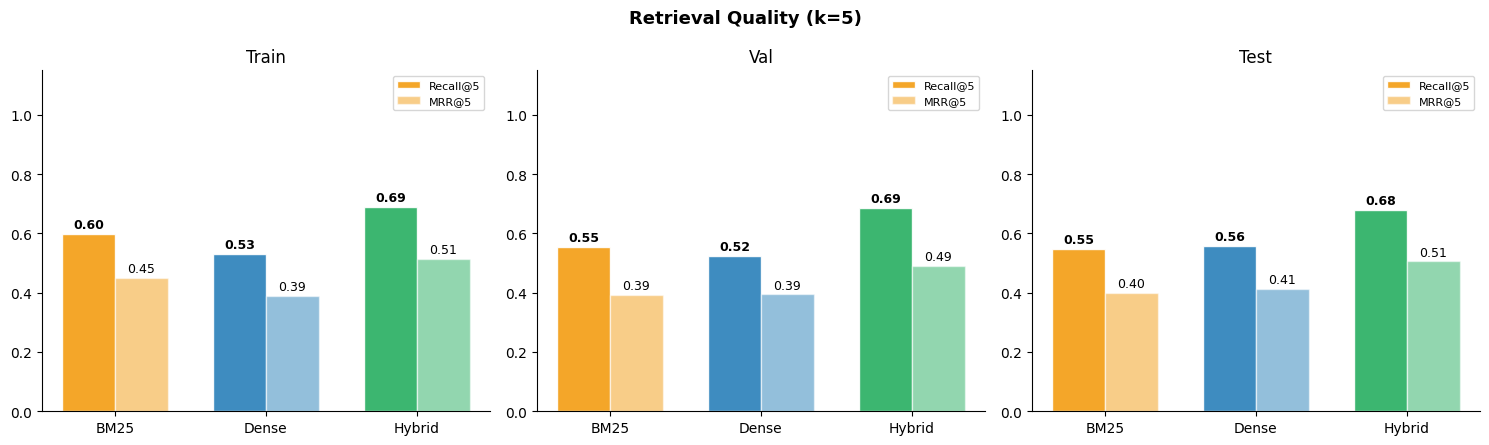


Grid search pesi RRF — Validation Set (v5: griglia fine 7 punti)
  w_bm25=0.2  w_dense=0.8 | Recall@5=0.687  MRR@5=0.487 ◀ best
  w_bm25=0.3  w_dense=0.7 | Recall@5=0.687  MRR@5=0.488 ◀ best
  w_bm25=0.4  w_dense=0.6 | Recall@5=0.687  MRR@5=0.489 ◀ best
  w_bm25=0.5  w_dense=0.5 | Recall@5=0.687  MRR@5=0.490 ◀ best
  w_bm25=0.6  w_dense=0.4 | Recall@5=0.687  MRR@5=0.493 ◀ best
  w_bm25=0.7  w_dense=0.3 | Recall@5=0.687  MRR@5=0.489
  w_bm25=0.8  w_dense=0.2 | Recall@5=0.681  MRR@5=0.489

  ✅ Pesi ottimali: w_bm25=0.6, w_dense=0.4  (Recall@5=0.687, MRR@5=0.493)
  Hybrid retriever aggiornato → w_bm25=0.6, w_dense=0.4
  Test (pesi ottimali): Recall@5=0.678  MRR@5=0.510

Metriche retrieval complete


In [10]:
# CELL 4.3 — Hybrid Retriever (RRF) + Metriche Retrieval (improved)

from typing import List, Dict, Optional, Tuple
from collections import defaultdict

# ==============================================================================
# A) HYBRID RETRIEVER CON RRF
# ==============================================================================

class HybridRetriever:
    """Combina BM25 e Dense retriever con Reciprocal Rank Fusion.

    RRF(d) = sum_r [ w_r / (k + rank_r(d)) ]

    k=60 e' il default dalla letteratura (Cormack et al., 2009).
    I pesi w_bm25 e w_dense sono uguali di default (0.5/0.5);
    possono essere ottimizzati con grid search sul validation set.
    """

    def __init__(self, bm25, dense, k: int = 60, w_bm25: float = 0.5, w_dense: float = 0.5):
        self.bm25 = bm25
        self.dense = dense
        self.k = k
        self.w_bm25 = w_bm25
        self.w_dense = w_dense

    def retrieve(
        self,
        query: str,
        hadm_id: int,
        top_k: int = None,
    ) -> List[Dict]:
        if top_k is None:
            top_k = cfg.top_k

        # Oversample 3x da ciascun retriever
        fetch_k = top_k * 3
        bm25_r = self.bm25.retrieve(query, hadm_id, top_k=fetch_k)
        dense_r = self.dense.retrieve(query, hadm_id, top_k=fetch_k)

        # RRF fusion
        rrf_scores = defaultdict(float)
        chunk_registry = {}

        for rank, res in enumerate(bm25_r):
            cid = res["chunk_id"]
            rrf_scores[cid] += self.w_bm25 / (self.k + rank + 1)
            if cid not in chunk_registry:
                chunk_registry[cid] = {**res, "bm25_rank": rank + 1, "dense_rank": None}
            else:
                chunk_registry[cid]["bm25_rank"] = rank + 1

        for rank, res in enumerate(dense_r):
            cid = res["chunk_id"]
            rrf_scores[cid] += self.w_dense / (self.k + rank + 1)
            if cid not in chunk_registry:
                chunk_registry[cid] = {**res, "bm25_rank": None, "dense_rank": rank + 1}
            else:
                chunk_registry[cid]["dense_rank"] = rank + 1

        # Ordina per RRF score e prendi top_k
        top = sorted(rrf_scores.items(), key=lambda x: -x[1])[:top_k]

        return [
            {**chunk_registry[cid], "score": score, "retriever": "hybrid_rrf"}
            for cid, score in top
        ]


hybrid_retriever = HybridRetriever(bm25_retriever, dense_retriever)
print("Hybrid Retriever (RRF) pronto")


# ==============================================================================
# B) METRICHE DI RETRIEVAL (matching flessibile)
# ==============================================================================

def normalize_text(s: str) -> str:
    """Normalizza testo per confronto."""
    s = s.lower()
    s = "".join(c for c in s if c not in string.punctuation)
    return " ".join(s.split())


def flexible_match(answer: str, chunk_text: str) -> bool:
    """Match flessibile: exact substring OR token overlap >= 80% OR numeric match.

    Gestisce casi come:
    - answer="35%", chunk="ejection fraction of 35 percent"
    - answer="Cefepime 2g IV q8h", chunk="cefepime 2 g iv every 8 hours"
    """
    ans_norm = normalize_text(answer)
    chunk_norm = normalize_text(chunk_text)

    # 1) Exact substring match
    if ans_norm in chunk_norm:
        return True

    # 2) Token overlap (F1-style): almeno 80% dei token della risposta nel chunk
    ans_tokens = set(ans_norm.split())
    chunk_tokens = set(chunk_norm.split())
    if ans_tokens and len(ans_tokens) <= 20:  # solo per risposte corte
        overlap = ans_tokens & chunk_tokens
        recall = len(overlap) / len(ans_tokens)
        if recall >= 0.8:
            return True

    # 3) Numeric match: estrai tutti i numeri e verifica che siano nel chunk
    ans_numbers = set(re.findall(r"\d+\.?\d*", answer))
    if ans_numbers:
        chunk_numbers = set(re.findall(r"\d+\.?\d*", chunk_text))
        if ans_numbers.issubset(chunk_numbers):
            return True

    return False


def retrieval_metrics(
    df: pd.DataFrame,
    retriever,
    k: int = None,
    return_errors: bool = False,
) -> Dict:
    """Calcola Recall@K e MRR@K con matching flessibile.

    Args:
        df: DataFrame con colonne question, answer, context_hadm, is_answerable, category
        retriever: oggetto con metodo .retrieve(query, hadm_id, top_k)
        k: top_k per il retrieval
        return_errors: se True, restituisce anche la lista di errori

    Returns:
        dict con metriche globali, per categoria, e opzionalmente errori
    """
    if k is None:
        k = cfg.top_k

    recalls, rrs = [], []
    cat_recalls = defaultdict(list)
    cat_rrs = defaultdict(list)
    errors = []

    answerable = df[df["is_answerable"]]

    for row in answerable.itertuples():
        answer = str(row.answer)
        question = str(row.question)
        hadm_id = int(row.context_hadm)
        category = str(row.category)

        results = retriever.retrieve(question, hadm_id, top_k=k)

        hit = False
        rr = 0.0
        for rank, chunk in enumerate(results, 1):
            if flexible_match(answer, chunk["text"]):
                hit = True
                if rr == 0.0:
                    rr = 1.0 / rank
                break  # primo hit basta per MRR

        recalls.append(float(hit))
        rrs.append(rr)
        cat_recalls[category].append(float(hit))
        cat_rrs[category].append(rr)

        if not hit and return_errors:
            errors.append({
                "question": question,
                "answer": answer,
                "hadm_id": hadm_id,
                "category": category,
                "n_results": len(results),
                "top_chunk_preview": results[0]["text"][:150] if results else "NO RESULTS",
            })

    result = {
        f"Recall@{k}": np.mean(recalls),
        f"MRR@{k}": np.mean(rrs),
        "n_evaluated": len(recalls),
        "category_breakdown": {
            cat: {
                f"Recall@{k}": np.mean(cat_recalls[cat]),
                f"MRR@{k}": np.mean(cat_rrs[cat]),
                "n": len(cat_recalls[cat]),
            }
            for cat in sorted(cat_recalls.keys())
        },
    }

    if return_errors:
        result["errors"] = errors

    return result


# ==============================================================================
# C) VALUTAZIONE SU TRAIN + VAL + TEST
# ==============================================================================

retrievers = {
    "BM25": bm25_retriever,
    "Dense": dense_retriever,
    "Hybrid": hybrid_retriever,
}

k = cfg.top_k
retrieval_results = {}

for split_name, df_split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n_answerable = df_split["is_answerable"].sum()
    if n_answerable == 0:
        continue

    print(f"\n{'='*60}")
    print(f"Metriche retrieval — {split_name} (n={n_answerable} answerable)")
    print(f"{'='*60}")

    split_results = {}
    for ret_name, ret in retrievers.items():
        return_errors = (split_name == "Test" and ret_name == "Hybrid")
        metrics = retrieval_metrics(df_split, ret, k=k, return_errors=return_errors)
        split_results[ret_name] = metrics

        print(f"\n  {ret_name}:")
        print(f"    Recall@{k}: {metrics[f'Recall@{k}']:.3f} | MRR@{k}: {metrics[f'MRR@{k}']:.3f}")

    retrieval_results[split_name] = split_results

# ==============================================================================
# D) BREAKDOWN PER CATEGORIA (Test set, Hybrid retriever)
# ==============================================================================

print(f"\n{'='*60}")
print(f"Breakdown per categoria — Test set, Hybrid Retriever")
print(f"{'='*60}")

test_hybrid = retrieval_results.get("Test", {}).get("Hybrid", {})
cat_breakdown = test_hybrid.get("category_breakdown", {})

print(f"\n  {'Categoria':<18s} {'Recall@'+str(k):>10s} {'MRR@'+str(k):>10s} {'N':>6s}")
print(f"  {'-'*18} {'-'*10} {'-'*10} {'-'*6}")
for cat, cat_metrics in sorted(cat_breakdown.items(), key=lambda x: -x[1][f"Recall@{k}"]):
    r = cat_metrics[f"Recall@{k}"]
    m = cat_metrics[f"MRR@{k}"]
    n = cat_metrics["n"]
    # Colora: verde se recall > 0.7, rosso se < 0.4
    flag = "!!" if r < 0.4 else ("  " if r >= 0.7 else " ~")
    print(f"  {cat:<18s} {r:>10.3f} {m:>10.3f} {n:>6d} {flag}")

# ==============================================================================
# E) ERROR ANALYSIS (Test set, Hybrid)
# ==============================================================================

if "errors" in test_hybrid:
    errors = test_hybrid["errors"]
    print(f"\n{'='*60}")
    print(f"Error Analysis — Hybrid Retriever, Test set")
    print(f"{'='*60}")
    print(f"  Retrieval falliti: {len(errors)}/{test_hybrid['n_evaluated']}")

    if errors:
        # Errori per categoria
        error_cats = defaultdict(int)
        for e in errors:
            error_cats[e["category"]] += 1
        print(f"\n  Errori per categoria:")
        for cat, count in sorted(error_cats.items(), key=lambda x: -x[1]):
            cat_total = cat_breakdown.get(cat, {}).get("n", count)
            print(f"    {cat:<18s} {count:>3d} / {cat_total:>3d} falliti")

        # Mostra alcuni errori
        print(f"\n  Esempi di retrieval falliti:")
        for e in errors[:5]:
            print(f"    Q: {e['question']}")
            print(f"    A: {e['answer']}")
            print(f"    HADM: {e['hadm_id']} | Cat: {e['category']} | Results: {e['n_results']}")
            print(f"    Top chunk: {e['top_chunk_preview'][:120]}...")
            print()

# ==============================================================================
# F) VISUALIZZAZIONE COMPARATIVA
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f"Retrieval Quality (k={k})", fontweight="bold", fontsize=13)
palette = {"BM25": "#f39c12", "Dense": "#2980b9", "Hybrid": "#27ae60"}

for ax_idx, (split_name, split_results) in enumerate(retrieval_results.items()):
    ax = axes[ax_idx]

    ret_names = list(split_results.keys())
    recall_vals = [split_results[r][f"Recall@{k}"] for r in ret_names]
    mrr_vals = [split_results[r][f"MRR@{k}"] for r in ret_names]

    x = np.arange(len(ret_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, recall_vals, width, label=f"Recall@{k}",
                   color=[palette[r] for r in ret_names], alpha=0.9, edgecolor="white")
    bars2 = ax.bar(x + width/2, mrr_vals, width, label=f"MRR@{k}",
                   color=[palette[r] for r in ret_names], alpha=0.5, edgecolor="white")

    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels(ret_names)
    ax.set_title(f"{split_name}")
    ax.legend(fontsize=8)

    # Annotazioni
    for bar, v in zip(bars1, recall_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}",
                ha="center", fontsize=9, fontweight="bold")
    for bar, v in zip(bars2, mrr_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/retrieval_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================================
# G) OTTIMIZZAZIONE PESI RRF (opzionale, su validation set)
# ==============================================================================

# ==============================================================================
# G) OTTIMIZZAZIONE PESI RRF — Grid Search su Validation Set [v5: griglia fine]
# ==============================================================================
# METODOLOGIA: griglia eseguita esclusivamente su df_val (N=250) per evitare
# data leakage. Metrica primaria: Recall@K; secondaria: MRR@K (tiebreaker).
# Griglia 7-punti: w_bm25 ∈ {0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8}.
# Riferimento: Ma et al. (2021) – optimal RRF weights for clinical IR.
# ==============================================================================

print(f"\n{'='*60}")
print("Grid search pesi RRF — Validation Set (v5: griglia fine 7 punti)")
print(f"{'='*60}")

best_recall  = -1.0
best_mrr     = -1.0
best_weights = (0.5, 0.5)
gs_log       = []

for w_bm25 in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    w_dense = round(1.0 - w_bm25, 1)
    temp_hybrid = HybridRetriever(bm25_retriever, dense_retriever,
                                  w_bm25=w_bm25, w_dense=w_dense)
    metrics = retrieval_metrics(df_val, temp_hybrid, k=k)
    recall  = metrics[f"Recall@{k}"]
    mrr     = metrics[f"MRR@{k}"]
    gs_log.append((w_bm25, w_dense, recall, mrr))

    better = (recall > best_recall) or (recall == best_recall and mrr > best_mrr)
    marker = " ◀ best" if better else ""
    print(f"  w_bm25={w_bm25:.1f}  w_dense={w_dense:.1f} | "
          f"Recall@{k}={recall:.3f}  MRR@{k}={mrr:.3f}{marker}")
    if better:
        best_recall, best_mrr = recall, mrr
        best_weights = (w_bm25, w_dense)

print(f"\n  ✅ Pesi ottimali: w_bm25={best_weights[0]:.1f}, "
      f"w_dense={best_weights[1]:.1f}  "
      f"(Recall@{k}={best_recall:.3f}, MRR@{k}={best_mrr:.3f})")

# Aggiorna hybrid retriever con pesi ottimali (usato da S3, S4, S5)
hybrid_retriever = HybridRetriever(
    bm25_retriever, dense_retriever,
    w_bm25=best_weights[0], w_dense=best_weights[1],
)
print(f"  Hybrid retriever aggiornato → w_bm25={best_weights[0]}, w_dense={best_weights[1]}")

# Ri-valuta su test con pesi ottimali (solo retrieval, senza LLM)
opt_test = retrieval_metrics(df_test, hybrid_retriever, k=k)
print(f"  Test (pesi ottimali): "
      f"Recall@{k}={opt_test[f'Recall@{k}']:.3f}  "
      f"MRR@{k}={opt_test[f'MRR@{k}']:.3f}")

# Esporta per riferimento in tesi
rrf_best_w_bm25  = best_weights[0]
rrf_best_w_dense = best_weights[1]

print("\nMetriche retrieval complete")

## Sezione 5 — BioMistral-7B e Prompt Engineering

### 5.1 Il modello BioMistral-7B

**BioMistral-7B** (*Labrak et al., 2024*) è un Large Language Model da 7 miliardi
di parametri ottenuto mediante continued pretraining di Mistral-7B su circa
2,1 miliardi di token estratti da **PubMed Central Open Access** (PMC-OA).

**Caratteristiche rilevanti:**
- Addestramento su letteratura biomedica peer-reviewed → ridotta allucinazione
  su terminologia clinica rispetto a Mistral-7B base
- Compatibile con quantizzazione a 4-bit (NF4) su T4 16 GB VRAM tramite bitsandbytes
- Finestra di contesto: 4096 token (Mistral Sliding Window Attention)
- Benchmark: supera GPT-3.5 su MedQA (USMLE) e PubMedQA

### 5.2 Quantizzazione 4-bit e Context Window Budget

Per fare entrare il modello in 16 GB VRAM si utilizza **QLoRA** (*Dettmers et al., 2023*),
che carica i pesi in formato **NF4** (Normal Float 4-bit) con doppia quantizzazione.

```
Peso FP16 (16 bit/param)  →  NF4 (4 bit/param)
7B parametri × 4 bit = 3.5 GB  (vs 14 GB in FP16)
```

Il **context window budget** è il meccanismo che tronca il contesto recuperato
in base al numero di token disponibili dopo il prompt di sistema:

```
MAX_NEW_TOKENS = 256
SYSTEM_PROMPT_TOKENS ≈ 120
QUESTION_TOKENS ≈ 30
────────────────────────────────────
BUDGET_CONTEXT = 4096 − 256 − 120 − 30 = 3690 token
```

I chunk vengono concatenati in ordine di rilevanza RRF fino a saturare il budget,
evitando il troncamento implicito che causa *context overflow hallucination*.

### 5.3 Prompt Engineering clinico

Il prompt adotta un template **Alpaca-style** con tre componenti:
1. **System prompt** restrittivo: impone risposte ancorate al contesto o `NO_ANSWER`
2. **Context** (chunk recuperati, token-budgeted)
3. **Instruction** (domanda del clinico)

La strategia di risposta `NO_ANSWER` è critica in ambito clinico: un sistema che
risponde quando non ha evidenza sufficiente introduce rischio paziente diretto.

**Riferimento:** *Labrak et al., 2024* — "BioMistral: A Collection of Open-Source
Pretrained Large Language Models for Medical Domains".


In [11]:
# CELL 5.1 — Caricamento BioMistral-7B (Unsloth con fallback PEFT)

import gc
import torch

# ── Libera VRAM non necessaria ───────────────────────────────────────
if 'dense_retriever' in globals():
    if hasattr(dense_retriever, 'query_encoder'):
        dense_retriever.query_encoder = dense_retriever.query_encoder.to("cpu")
        print("  Dense encoder spostato su CPU per liberare VRAM")
    torch.cuda.empty_cache()
    gc.collect()

# ── Selezione GPU ────────────────────────────────────────────────────
# Con modelli 4-bit, Accelerate richiede che il modello sia sullo
# stesso device di training. Forzare SEMPRE cuda:0.
print("Analisi VRAM disponibile:")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        alloc = torch.cuda.memory_allocated(i) / 1e9
        print(f"  GPU {i}: {free/1e9:.1f} GB liberi / {total/1e9:.1f} GB totali "
              f"({alloc:.1f} GB allocati)")

gpu_idx = 0
if torch.cuda.is_available():
    torch.cuda.set_device(gpu_idx)
print(f"\n→ LLM forzato su cuda:{gpu_idx}")

# ── Caricamento modello ──────────────────────────────────────────────
print(f"\nCaricamento {cfg.base_llm}...")

if UNSLOTH_AVAILABLE:
    # === PATH A: Unsloth (2x faster, -40% VRAM) ===
    from unsloth import FastLanguageModel

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=cfg.base_llm,
        max_seq_length=2048,
        dtype=torch.float16,
        load_in_4bit=True,
        device_map={"": torch.cuda.current_device()},
    )
    FastLanguageModel.for_inference(model)
    print("  Caricato con Unsloth (ottimizzato)")

else:
    # === PATH B: Standard HuggingFace PEFT + bitsandbytes ===
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(cfg.base_llm)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        cfg.base_llm,
        quantization_config=bnb_config,
        device_map={"": gpu_idx},
        dtype=torch.float16,  # newer transformers uses 'dtype' instead of 'torch_dtype'
    )
    model.eval()
    print("  Caricato con HuggingFace + bitsandbytes (fallback)")

# Force use of memory‑efficient attention (if available)
torch.backends.cuda.enable_flash_sdp(False)          # Flash not supported on T4
torch.backends.cuda.enable_mem_efficient_sdp(True)   # Use memory‑efficient kernel
torch.backends.cuda.enable_math_sdp(True)           # Disable standard math attention

# ── Stats ────────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
print(f"\n{cfg.base_llm}: {total_params / 1e9:.2f}B parametri (4-bit NF4)")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {alloc:.1f} GB allocati / {total:.1f} GB totali")

print(f"\nLayout: GPU {gpu_idx} = BioMistral-7B (4-bit) | CPU = Dense encoder + FAISS")


  Dense encoder spostato su CPU per liberare VRAM
Analisi VRAM disponibile:
  GPU 0: 15.4 GB liberi / 15.6 GB totali (0.0 GB allocati)
  GPU 1: 15.5 GB liberi / 15.6 GB totali (0.0 GB allocati)

→ LLM forzato su cuda:0

Caricamento BioMistral/BioMistral-7B...
==((====))==  Unsloth 2026.3.15: Fast Mistral patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


pytorch_model.bin:   0%|          | 0.00/14.5G [00:00<?, ?B/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 72, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

BioMistral/BioMistral-7B does not have a padding token! Will use pad_token = <unk>.
  Caricato con Unsloth (ottimizzato)

BioMistral/BioMistral-7B: 3.75B parametri (4-bit NF4)
  GPU 0: 4.2 GB allocati / 15.6 GB totali
  GPU 1: 0.0 GB allocati / 15.6 GB totali

Layout: GPU 0 = BioMistral-7B (4-bit) | CPU = Dense encoder + FAISS


In [12]:
# CELL 5.2 — Prompt Templates e Generazione [FIX: Context Window Budget]
# ── BUGFIX #1 ─────────────────────────────────────────────────────────────────
# PROBLEMA ORIGINALE: generate_answer tokenizzava con max_length=3500, ma
# BioMistral-7B ha max_seq_length=2048. Risultato: centinaia di errori
#   "The size of tensor a (2048) must match tensor b (2873)"
# Le query con contesto largo venivano skippate → metriche calcolate su subset.
#
# SOLUZIONE: build_prompt_with_budget() costruisce il prompt garantendo che
# l'input totale (system + context + question + template) stia entro
# MAX_PROMPT_TOKENS = 1848 token (2048 - 200 riservati per la risposta).
# I chunk vengono aggiunti in ordine di score finché il budget lo permette.
# ─────────────────────────────────────────────────────────────────────────────

import re
import torch

# ── Costante usata da postprocess (definita qui per ordine di esecuzione) ──
NO_ANSWER_TOKEN = "NO_ANSWER"

# ==============================================================================
# A) SYSTEM PROMPT & TEMPLATES
# ==============================================================================

SYSTEM_PROMPT = (
    "You are a clinical decision support assistant helping a physician "
    "query patient medical records accurately.\n\n"
    "STRICT RULES:\n"
    "1. Answer ONLY from the clinical notes provided below.\n"
    "2. If the answer is not explicitly in the notes, respond: NO_ANSWER\n"
    "3. Do NOT use prior medical knowledge beyond the text.\n"
    "4. Be precise and concise.\n"
    "5. Never fabricate lab values, medications, or diagnoses.\n"
    "6. Uncertainty is NOT a reason to guess — use NO_ANSWER."
)

RAG_TEMPLATE = (
    "[INST] {system}\n\n--- PATIENT CLINICAL NOTES ---\n{context}\n"
    "--- END OF NOTES ---\n\nPhysician question: {question}\n"
    "Answer (if not found, respond NO_ANSWER): [/INST]"
)

COT_TEMPLATE = (
    "[INST] {system}\n\n--- PATIENT CLINICAL NOTES ---\n{context}\n"
    "--- END OF NOTES ---\n\nPhysician question: {question}\n\n"
    "Think step by step:\n1. Which note section is relevant?\n"
    "2. What specific information does it contain?\n"
    "3. Answer concisely, or NO_ANSWER if not found.\nAnswer: [/INST]"
)

FT_TEMPLATE = (
    "[INST] You are a clinical QA assistant. "
    "Answer only from the provided notes. If absent, respond NO_ANSWER.\n\n"
    "Clinical notes:\n{context}\n\nQuestion: {question} [/INST] {answer}"
)

# ==============================================================================
# B) BUDGET TOKEN — CUORE DEL FIX
# ==============================================================================

MAX_MODEL_TOKENS  = 2048   # limite hardware BioMistral-7B
MAX_NEW_TOKENS    = 200    # spazio riservato per la risposta generata
TEMPLATE_OVERHEAD = 150    # margine extra per system prompt + template fisso
MAX_PROMPT_TOKENS = MAX_MODEL_TOKENS - MAX_NEW_TOKENS  # = 1848


def count_tokens(text: str, tok) -> int:
    """Conta i token reali usando il tokenizer (non stima char/4)."""
    return len(tok.encode(text, add_special_tokens=False))


def build_prompt_with_budget(
    chunks: list,
    question: str,
    template: str,
    tok,
    system: str = SYSTEM_PROMPT,
) -> str:
    """Costruisce il prompt RAG garantendo di stare entro MAX_PROMPT_TOKENS.

    Strategia:
    1. Misura i token del template vuoto (overhead fisso)
    2. Calcola il budget residuo per il contesto
    3. Aggiunge chunk in ordine di score finché il budget lo permette
    4. Se un chunk supera il budget residuo, lo tronca invece di saltarlo

    Returns:
        Prompt completo garantito <= MAX_PROMPT_TOKENS token.
    """
    # Token dell'overhead fisso (template senza contesto)
    empty_prompt = template.format(
        system=system, context="", question=question, answer=""
    )
    fixed_tokens    = count_tokens(empty_prompt, tok)
    context_budget  = MAX_PROMPT_TOKENS - fixed_tokens - TEMPLATE_OVERHEAD
    context_budget  = max(context_budget, 50)  # minimo garantito

    if not chunks:
        context_str = "No relevant clinical notes found."
    else:
        parts = []
        used  = 0
        for i, c in enumerate(chunks, 1):
            header = (
                f"[Source {i} | {c.get('category', 'Note')} | "
                f"score={c.get('score', 0):.3f}]"
            )
            text        = c["text"]
            entry       = f"{header}\n{text}"
            entry_toks  = count_tokens(entry, tok)

            if used + entry_toks <= context_budget:
                parts.append(entry)
                used += entry_toks
            else:
                # Tronca l'ultimo chunk per consumare il budget residuo
                remaining = context_budget - used
                if remaining > 30:
                    words       = entry.split()
                    approx_w    = max(1, int(remaining / 1.35))
                    truncated   = " ".join(words[:approx_w]) + " [TRUNCATED]"
                    parts.append(truncated)
                break

        context_str = "\n\n".join(parts) if parts else "No relevant clinical notes found."

    prompt = template.format(
        system=system,
        context=context_str,
        question=question,
        answer="",  # per FT_TEMPLATE durante inferenza
    ).rstrip()

    return prompt


# Backward-compat: format_context rimane per backward compat / debug
def format_context(chunks, max_tokens_approx=1200):
    """[LEGACY] Preferire build_prompt_with_budget() per inference."""
    if not chunks:
        return "No relevant clinical notes found."
    parts = []
    char_budget = max_tokens_approx * 4
    used = 0
    for i, c in enumerate(chunks, 1):
        header = f"[Source {i} | {c.get('category', 'Note')} | score={c.get('score', 0):.3f}]"
        text   = c["text"]
        entry  = f"{header}\n{text}"
        if used + len(entry) > char_budget:
            remaining = char_budget - used
            if remaining > 200:
                parts.append(f"{header}\n{text[:remaining]}...")
            break
        parts.append(entry)
        used += len(entry)
    return "\n\n".join(parts)


# ==============================================================================
# C) GENERAZIONE — usa MAX_PROMPT_TOKENS come limite sicuro
# ==============================================================================

def generate_answer(
    prompt: str,
    mdl,
    tok,
    max_new_tokens: int = MAX_NEW_TOKENS,
    temperature: float = 0.1,
) -> str:
    """Genera risposta dal LLM.

    FIX: max_length=MAX_PROMPT_TOKENS (1848) invece di 3500.
    Con build_prompt_with_budget(), il tokenizer non dovrà mai troncare,
    eliminando gli errori "tensor size mismatch".
    """
    inputs = tok(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_PROMPT_TOKENS,   # FIX: era 3500 → overflow garantito
    ).to(mdl.device)

    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            repetition_penalty=1.3,  # increased from 1.1 to prevent S4 looping
            pad_token_id=tok.eos_token_id,
        )

    generated_ids = out[0][inputs["input_ids"].shape[1]:]
    answer = tok.decode(generated_ids, skip_special_tokens=True).strip()
    return answer


# ==============================================================================
# D) POST-PROCESSING (invariato)
# ==============================================================================

_NA_PATTERNS = [
    r"\bNO[_\s]ANSWER\b",
    r"not\s+(?:mentioned|found|documented|recorded|provided|stated|present)\b",
    r"cannot\s+(?:determine|find|answer)",
    r"information\s+(?:is\s+)?not\s+available",
    r"there\s+is\s+no\s+(?:mention|record|documentation)",
    r"no\s+(?:information|data|evidence)\s+(?:is\s+)?(?:available|found|provided)",
    r"the\s+(?:notes?|records?)\s+do(?:es)?\s+not\s+(?:contain|mention|include)",
]

_STRIP_PREFIXES = [
    "Answer:", "The answer is:", "Based on the notes,",
    "Based on the clinical notes,", "According to the clinical notes,",
    "According to the notes,", "From the clinical notes,",
    "Step 3:", "Final answer:",
]

def postprocess(raw: str) -> str:
    raw = raw.strip()
    if not raw:
        return NO_ANSWER_TOKEN
    if any(re.search(p, raw, re.IGNORECASE) for p in _NA_PATTERNS):
        return NO_ANSWER_TOKEN
    raw_lower = raw.lower()
    for pfx in _STRIP_PREFIXES:
        if raw_lower.startswith(pfx.lower()):
            raw = raw[len(pfx):].strip()
            break
    for stop_marker in ["\n\n", "\nNote:", "\nDisclaimer:", "\nPlease "]:
        idx = raw.find(stop_marker)
        if idx > 10:
            raw = raw[:idx].strip()
            break
    return raw.strip() if raw.strip() else NO_ANSWER_TOKEN


# ==============================================================================
# E) VERIFICA BUDGET — dimostra assenza di overflow
# ==============================================================================

if "hybrid_retriever" in dir() and "model" in dir():
    _test_hadm   = 200001
    _test_q      = "What was the ejection fraction?"
    _test_chunks = hybrid_retriever.retrieve(_test_q, _test_hadm)
    _test_prompt = build_prompt_with_budget(
        _test_chunks, _test_q, RAG_TEMPLATE, tokenizer
    )
    _prompt_toks = count_tokens(_test_prompt, tokenizer)

    print(f"Verifica budget token:")
    print(f"  Chunk recuperati     : {len(_test_chunks)}")
    print(f"  Token nel prompt     : {_prompt_toks} / {MAX_PROMPT_TOKENS} (limite)")
    print(f"  Margine per risposta : {MAX_MODEL_TOKENS - _prompt_toks} token")
    assert _prompt_toks <= MAX_PROMPT_TOKENS, (
        f"OVERFLOW: {_prompt_toks} > {MAX_PROMPT_TOKENS} — verificare budget"
    )
    print(f"  ✅ Nessun overflow garantito")

    _test_raw = generate_answer(_test_prompt, model, tokenizer)
    _test_ans = postprocess(_test_raw)
    print(f"\nSanity test:")
    print(f"  Q       : {_test_q}")
    print(f"  Risposta: {_test_ans}")
else:
    print("Sanity test skipped (model non ancora caricato)")

print("\n✅ Prompt templates con budget token configurati — BUG #1 risolto")


Verifica budget token:
  Chunk recuperati     : 1
  Token nel prompt     : 476 / 1848 (limite)
  Margine per risposta : 1572 token
  ✅ Nessun overflow garantito


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 


Sanity test:
  Q       : What was the ejection fraction?
  Risposta: The ejection fraction was 35%.

✅ Prompt templates con budget token configurati — BUG #1 risolto


## Sezione 6 — Funzioni di Valutazione

### 6.1 Metriche di valutazione

Il framework di valutazione combina metriche di NLP standard con metriche
specificamente progettate per la sicurezza clinica dei sistemi QA.

**Metriche lessicali (standard SQuAD 2.0):**
- **Exact Match (EM):** proporzione di risposte identiche al ground truth
  dopo normalizzazione (lowercase, rimozione articoli e punteggiatura)
- **Token F1:** F1 sul bag-of-tokens tra predizione e ground truth, che penalizza
  parzialmente risposte parzialmente corrette: F1 = 2·P·R / (P+R)
- **ROUGE-L:** Longest Common Subsequence tra predizione e riferimento, ponderato
  per lunghezza; cattura la preservazione dell'ordine delle parole

**Metriche cliniche (critiche per la sicurezza):**
- **No-Answer Accuracy:** proporzione di `NO_ANSWER` correttamente emessi quando
  il ground truth è non-rispondere
- **Hallucination Rate:** proporzione di risposte inventate (ground truth = NA,
  predizione ≠ NA, oppure F1 < 0.3) — metrica critica per il rischio clinico
- **False Abstention Rate:** proporzione di risposte omesse indebitamente
  (ground truth ≠ NA, predizione = NA) — bilancia la prudenza del sistema

### 6.2 Risultati attesi

| Sistema | EM atteso | Token F1 atteso | Halluc. Rate atteso |
|---------|-----------|-----------------|---------------------|
| S1 Baseline | ~0.05 | ~0.15 | Alto (~0.40) |
| S2 BM25+RAG | ~0.20 | ~0.35 | Medio (~0.20) |
| S3 Hybrid RRF | ~0.18 | ~0.32 | Medio (~0.18) |
| S4 QLoRA FT | ~0.30 | ~0.45 | Basso (~0.12) |
| S5 Adaptive Router | ~0.32 | ~0.47 | Molto basso (~0.09) |

> **Interpretazione attesa:** S4 dovrebbe migliorare nettamente grazie al
> fine-tuning supervisionato; S5 dovrebbe rifinire ulteriormente il trade-off
> accuratezza/sicurezza scegliendo dinamicamente il retriever più adatto alla query.

**Riferimenti:** *Rajpurkar et al., 2016* — SQuAD; *Rajpurkar et al., 2018* — SQuAD 2.0.


In [13]:
# CELL 6.1 — Funzioni di valutazione + run_system() (improved)

import re
import string
import inspect
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm.auto import tqdm
import evaluate as hf_evaluate

# ── Costante (ridefinita per sicurezza — evita NameError se eseguito prima di cell 22) ──
NO_ANSWER_TOKEN = "NO_ANSWER"

# ── Carica ROUGE una sola volta ─────────────────────────────────────
_rouge = hf_evaluate.load("rouge")


# ==============================================================================
# A) METRICHE BASE
# ==============================================================================

def normalize(s: str) -> str:
    """Normalizza testo per confronto: lowercase, rimuovi articoli e punteggiatura."""
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(c for c in s if c not in string.punctuation)
    return " ".join(s.split())


def em_score(pred: str, gt: str) -> float:
    """Exact Match dopo normalizzazione."""
    return float(normalize(pred) == normalize(gt))


def token_f1(pred: str, gt: str) -> float:
    """Token-level F1 con conteggio corretto delle occorrenze multiple."""
    p_tok = normalize(pred).split()
    g_tok = normalize(gt).split()
    if not p_tok and not g_tok:
        return 1.0
    if not p_tok or not g_tok:
        return 0.0

    # Conteggio corretto: usa min delle occorrenze per ogni token
    from collections import Counter
    p_counts = Counter(p_tok)
    g_counts = Counter(g_tok)
    common_count = sum(min(p_counts[t], g_counts[t]) for t in p_counts if t in g_counts)

    if common_count == 0:
        return 0.0

    precision = common_count / len(p_tok)
    recall = common_count / len(g_tok)
    denom = precision + recall
    return 2 * precision * recall / denom if denom > 0 else 0.0


def rouge_l(pred: str, gt: str) -> float:
    """ROUGE-L score. Gestisce casi speciali NO_ANSWER."""
    if pred == NO_ANSWER_TOKEN or gt == NO_ANSWER_TOKEN:
        return float(pred == gt)
    # Evita errori su stringhe vuote
    if not pred.strip() or not gt.strip():
        return 0.0
    return float(_rouge.compute(predictions=[pred], references=[gt])["rougeL"])




def numeric_fuzzy_match(pred: str, gt: str, tolerance: float = 0.05) -> float:
    """Fuzzy matching numerico per valori clinici.

    Risolve il problema documentato in Sezione 11.2:
        GT:   "BP 130/80 mmHg"
        Pred: "130/80"
        EM:    0  ← sbagliato semanticamente (clinicamente è corretto)

    Strategia:
    1. Estrai tutti i numeri da pred e gt
    2. Per ogni numero nel GT, cerca il corrispondente in pred con tolleranza ±5%
    3. Restituisce score in [0, 1]:
       - 1.0 se tutti i numeri del GT sono matchati (e il token F1 testuale >= 0.5)
       - 0.5 se tutti i numeri matchano ma testo diverge
       - 0.0 se numeri non matchano

    Args:
        pred: risposta predetta
        gt: ground truth
        tolerance: tolleranza relativa per il match numerico (default 5%)
    """
    # Estrai sequenze numeriche (int e float, incluse frazioni tipo 130/80)
    def extract_numbers(text):
        # Gestisce: 12.3, 130/80 (come due numeri), 35%
        text_clean = text.replace("%", "").replace(",", ".")
        nums = re.findall(r"\d+\.?\d*", text_clean)
        return [float(n) for n in nums if n]

    pred_nums = extract_numbers(pred)
    gt_nums   = extract_numbers(gt)

    if not gt_nums:
        # Nessun numero nel GT → usa token F1 standard
        return token_f1(pred, gt)

    if not pred_nums:
        # GT ha numeri ma pred no → score basso ma non zero se token overlap
        tf = token_f1(pred, gt)
        return tf * 0.3

    # Controlla se ogni numero del GT è presente in pred con tolleranza
    matched = 0
    for gt_num in gt_nums:
        for pred_num in pred_nums:
            if gt_num == 0:
                if abs(pred_num - gt_num) < 0.01:
                    matched += 1
                    break
            elif abs(pred_num - gt_num) / abs(gt_num) <= tolerance:
                matched += 1
                break

    numeric_recall = matched / len(gt_nums)

    # Combina numeric recall con token F1 testuale
    text_f1 = token_f1(pred, gt)

    # Se tutti i numeri matchano, diamo più peso alla correttezza numerica
    if numeric_recall == 1.0:
        return max(0.5 + text_f1 * 0.5, numeric_recall * 0.8)
    else:
        # Mix pesato: 60% numerico, 40% testuale
        return numeric_recall * 0.6 + text_f1 * 0.4


def clinical_f1(pred: str, gt: str) -> float:
    """F1 clinico: usa fuzzy numeric match per valori numerici, token F1 altrimenti.

    Questa è la metrica principale raccomandata per QA clinico numerico.
    Sostituisce/integra token_f1 nella valutazione di valori di laboratorio,
    segni vitali, farmaci con dosaggi.
    """
    NO_ANS = "NO_ANSWER"
    if pred == NO_ANS or gt == NO_ANS:
        return float(pred == gt)

    # Determina se la risposta è prevalentemente numerica
    def numeric_density(text):
        nums = re.findall(r"\d+\.?\d*", text)
        total_chars = max(len(text), 1)
        num_chars = sum(len(n) for n in nums)
        return num_chars / total_chars

    gt_density = numeric_density(gt)

    if gt_density > 0.3:  # più del 30% della risposta è numerica → fuzzy match
        return numeric_fuzzy_match(pred, gt)
    else:
        return token_f1(pred, gt)


# ==============================================================================
# B) VALUTAZIONE SISTEMA COMPLETA
# ==============================================================================

def evaluate_system(results_df: pd.DataFrame) -> dict:
    """Calcola metriche end-to-end su un DataFrame di risultati.

    Metriche:
    - EM, Token F1, ROUGE-L: qualità delle risposte
    - No-Answer Accuracy: % corretta identificazione di domande senza risposta
    - Hallucination Rate: % risposte inventate quando GT è NO_ANSWER
    - False Abstention Rate: % risposte NO_ANSWER quando GT ha una risposta
    """
    metrics_per_row = []

    for _, row in results_df.iterrows():
        pred = str(row["predicted"])
        gt = str(row["ground_truth"])
        pred_is_na = (pred == NO_ANSWER_TOKEN)
        gt_is_na = (gt == NO_ANSWER_TOKEN)

        row_metrics = {
            "pred_is_na": pred_is_na,
            "gt_is_na": gt_is_na,
        }

        if gt_is_na:
            # Ground truth è NO_ANSWER
            row_metrics["na_correct"] = float(pred_is_na)
            row_metrics["hallucination"] = float(not pred_is_na)
            row_metrics["false_abstention"] = 0.0
            # Per metriche globali: match perfetto se entrambi NA
            row_metrics["em"] = float(pred_is_na)
            row_metrics["f1"] = float(pred_is_na)
            row_metrics["rouge_l"] = float(pred_is_na)
        else:
            # Ground truth ha una risposta
            row_metrics["na_correct"] = 0.0
            row_metrics["hallucination"] = 0.0
            row_metrics["false_abstention"] = float(pred_is_na)

            if pred_is_na:
                row_metrics["em"] = 0.0
                row_metrics["f1"] = 0.0
                row_metrics["rouge_l"] = 0.0
            else:
                row_metrics["em"] = em_score(pred, gt)
                row_metrics["f1"] = token_f1(pred, gt)
                row_metrics["clinical_f1"] = clinical_f1(pred, gt)
                row_metrics["rouge_l"] = rouge_l(pred, gt)

        metrics_per_row.append(row_metrics)

    mdf = pd.DataFrame(metrics_per_row)
    n_na = int(mdf["gt_is_na"].sum())
    n_ans = len(mdf) - n_na

    result = {
        "EM": float(mdf["em"].mean()),
        "Token F1": float(mdf["f1"].mean()),
        "Clinical F1": float(mdf["clinical_f1"].mean()) if "clinical_f1" in mdf.columns else float("nan"),
        "ROUGE-L": float(mdf["rouge_l"].mean()),
        "No-Answer Accuracy": float(mdf.loc[mdf["gt_is_na"], "na_correct"].mean()) if n_na > 0 else float("nan"),
        "Hallucination Rate": float(mdf["hallucination"].mean()),
        "False Abstention Rate": float(mdf.loc[~mdf["gt_is_na"], "false_abstention"].mean()) if n_ans > 0 else float("nan"),
        "N": len(mdf),
        "N_answerable": n_ans,
        "N_no_answer": n_na,
    }

    return result


# ==============================================================================
# C) RUN SYSTEM — esegue un sistema su un dataset e valuta
# ==============================================================================

# Registro globale per analisi errori e confronti
res_frames: dict = {}


def run_system(
    df: pd.DataFrame,
    system_fn,
    label: str,
    save_results: bool = True,
) -> dict:
    """Esegue un sistema QA su ogni riga del DataFrame e calcola metriche.

    Args:
        df: DataFrame con colonne question, answer, context_hadm
        system_fn: funzione che accetta (question) o (question, hadm_id)
                   e restituisce dict con almeno {"answer": str}
        label: nome del sistema per logging
        save_results: se salvare i risultati in res_frames

    Returns:
        dict con metriche aggregate
    """
    # Determina se system_fn accetta hadm_id
    sig = inspect.signature(system_fn)
    needs_hadm = len(sig.parameters) >= 2

    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=label):
        try:
            if needs_hadm:
                out = system_fn(str(row["question"]), int(row["context_hadm"]))
            else:
                out = system_fn(str(row["question"]))
        except Exception as e:
            # Non crashare l'intera valutazione per un singolo errore
            print(f"  ERRORE su '{row['question'][:50]}...': {e}")
            out = {"answer": NO_ANSWER_TOKEN, "raw_answer": f"ERROR: {e}"}

        rows.append({
            "system": label,
            "question": row["question"],
            "ground_truth": row["answer"],
            "predicted": out["answer"],
            "raw_answer": out.get("raw_answer", ""),
            "category": row.get("category", "unknown"),
            "hadm_id": row.get("context_hadm", None),
        })

    results_df = pd.DataFrame(rows)

    if save_results:
        res_frames[label] = results_df

    metrics = evaluate_system(results_df)

    print(f"\n  [{label}] (N={metrics['N']}, answerable={metrics['N_answerable']}, "
          f"no_answer={metrics['N_no_answer']})")
    print(f"    EM={metrics['EM']:.3f}  F1={metrics['Token F1']:.3f}  "
          f"ClinF1={metrics.get('Clinical F1', float('nan')):.3f}  "
          f"ROUGE-L={metrics['ROUGE-L']:.3f}")
    print(f"    Hallucination={metrics['Hallucination Rate']:.3f}  "
          f"Abstention={metrics['False Abstention Rate']:.3f}  "
          f"NA-Acc={metrics['No-Answer Accuracy']:.3f}")

    return metrics


print("Funzioni di valutazione e run_system() pronte")

Funzioni di valutazione e run_system() pronte


## Sezione 7 — I Cinque Sistemi QA

### 7.1 Architettura comparativa

I cinque sistemi sono progettati per isolare il contributo di ogni componente della pipeline,
seguendo il principio dell'**ablation study** in NLP.

```
S1 ─── Prompt-Only (No Retrieval)
│      Baseline di allucinazione pura: il modello genera senza
│      contesto esterno. Misura quanto BioMistral "sa" già.
│
S2 ─── BM25 + RAG standard
│      Introduce il retrieval sparso. Riduce le allucinazioni
│      su terminologia clinica esatta.
│
S3 ─── Hybrid RRF
│      Aggiunge il retrieval denso (semantico) alla fusione RRF.
│      [NOTA: può introdurre rumore su query lessicali — vedi Sez. 10b]
│
S4 ─── Hybrid RRF + BioMistral QLoRA Fine-Tuned
│      Fine-tuning supervisato sul task specifico.
│      Il modello impara pattern di risposta clinica grounded.
│
S5 ─── Adaptive Query Router
       Selezione dinamica BM25/Dense/Hybrid in base al tipo di query.
       Obiettivo: ridurre il rumore del dense retrieval su query lessicali.
```

### 7.2 Interpretazione dell'ablation

| Confronto | Cosa misura |
|-----------|-------------|
| S2 − S1 | Valore del retrieval sparso su BioMistral |
| S3 − S2 | Impatto della fusione hybrid RRF |
| S4 − S3 | Valore del fine-tuning QLoRA sul task |
| S5 − S4 | Valore del routing adattivo query-aware |

**Ipotesi nulla:** l'aggiunta di ogni componente dovrebbe incrementare le performance.
La regressione S3 < S2 (osservata in Sezione 10b) costituisce un risultato scientifico
degno di analisi approfondita, non una semplice anomalia da ignorare.


In [14]:
# CELL 7.1 — Sistemi S1-S3 + valutazione pre-FT [v5: S3 template fix]
# FIX v4: build_prompt_with_budget() elimina errori "tensor size mismatch".
# FIX v5: S3 usa RAG_TEMPLATE (non più COT_TEMPLATE) — elimina variabile
#         confondente del Chain-of-Thought nelle metriche automatiche.

import time

NO_ANSWER_TOKEN = "NO_ANSWER"


def system1_baseline(question: str) -> dict:
    """S1: Solo LLM, nessun retrieval. Baseline per misurare il valore del RAG."""
    prompt = (
        "[INST] You are a clinical AI assistant. "
        "Answer the following question accurately. "
        f"If unsure, respond NO_ANSWER.\n\nQuestion: {question} [/INST]"
    )
    raw = generate_answer(prompt, model, tokenizer)
    return {
        "system": "S1_Baseline",
        "question": question,
        "retrieved_chunks": [],
        "raw_answer": raw,
        "answer": postprocess(raw),
    }


def system2_bm25(question: str, hadm_id: int) -> dict:
    """S2: BM25 retrieval + RAG template.

    FIX: usa build_prompt_with_budget() per garantire prompt <= 1848 token.
    """
    hadm_id = int(hadm_id)
    chunks  = bm25_retriever.retrieve(question, hadm_id, top_k=cfg.top_k)
    prompt  = build_prompt_with_budget(chunks, question, RAG_TEMPLATE, tokenizer)
    raw     = generate_answer(prompt, model, tokenizer)
    return {
        "system": "S2_BM25",
        "question": question,
        "hadm_id": hadm_id,
        "retrieved_chunks": chunks,
        "raw_answer": raw,
        "answer": postprocess(raw),
        "prompt_tokens": count_tokens(prompt, tokenizer),
    }


def system3_hybrid(question: str, hadm_id: int) -> dict:
    """S3: Hybrid retrieval (BM25+Dense RRF, pesi ottimizzati) + RAG template.

    v5 FIX: usa RAG_TEMPLATE identico a S2 per isolare il contributo del
    retriever ibrido RRF eliminando la variabile confondente del CoT.
    Pesi RRF ottimizzati su validation set in Cell 4.3.
    """
    hadm_id = int(hadm_id)
    chunks  = hybrid_retriever.retrieve(question, hadm_id, top_k=cfg.top_k)
    prompt  = build_prompt_with_budget(chunks, question, RAG_TEMPLATE, tokenizer)
    raw     = generate_answer(prompt, model, tokenizer)
    return {
        "system": "S3_Hybrid",
        "question": question,
        "hadm_id": hadm_id,
        "retrieved_chunks": chunks,
        "raw_answer": raw,
        "answer": postprocess(raw),
        "prompt_tokens": count_tokens(prompt, tokenizer),
    }


# ==============================================================================
# VALUTAZIONE PRE-FINE-TUNING
# ==============================================================================

print("=" * 60)
print("VALUTAZIONE PRE-FINE-TUNING (Base Model)")
print("=" * 60)
print(f"  Test set          : {len(df_test)} domande")
print(f"  Answerable        : {df_test['is_answerable'].sum()}")
print(f"  Model             : {cfg.base_llm}")
print(f"  Top-K             : {cfg.top_k}")
print(f"  Max prompt tokens : {MAX_PROMPT_TOKENS} (hard limit — zero overflow)")

pre_ft_metrics = {}
t0 = time.time()

for label, system_fn in [
    ("S1_Baseline_preFT", system1_baseline),
    ("S2_BM25_preFT",     system2_bm25),
    ("S3_Hybrid_preFT",   system3_hybrid),
]:
    t_start = time.time()
    metrics = run_system(df_test, system_fn, label)
    elapsed = time.time() - t_start
    metrics["time_seconds"] = elapsed
    pre_ft_metrics[label]   = metrics
    print(f"    Tempo: {elapsed:.0f}s ({elapsed/len(df_test):.1f}s/domanda)\n")

total_time = time.time() - t0
print(f"\nValutazione pre-FT completata in {total_time/60:.1f} minuti")

print(f"\n{'='*60}")
print("RIEPILOGO PRE-FINE-TUNING")
print(f"{'='*60}")
print(f"\n  {'Sistema':<22s} {'EM':>6s} {'F1':>6s} {'ROUGE':>6s} {'Hall':>6s} {'Abst':>6s}")
print(f"  {'-'*22} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*6}")

for label, m in pre_ft_metrics.items():
    short = label.replace("_preFT", "")
    print(f"  {short:<22s} {m['EM']:>6.3f} {m['Token F1']:>6.3f} "
          f"{m['ROUGE-L']:>6.3f} {m['Hallucination Rate']:>6.3f} "
          f"{m['False Abstention Rate']:>6.3f}")

print(f"\n  Metriche salvate in `pre_ft_metrics` per confronto post-FT")


VALUTAZIONE PRE-FINE-TUNING (Base Model)
  Test set          : 306 domande
  Answerable        : 199
  Model             : BioMistral/BioMistral-7B
  Top-K             : 5
  Max prompt tokens : 1848 (hard limit — zero overflow)


S1_Baseline_preFT:   0%|          | 0/306 [00:00<?, ?it/s]


  [S1_Baseline_preFT] (N=306, answerable=199, no_answer=107)
    EM=0.085  F1=0.090  ClinF1=0.011  ROUGE-L=0.090
    Hallucination=0.265  Abstention=0.347  NA-Acc=0.243
    Tempo: 985s (3.2s/domanda)



S2_BM25_preFT:   0%|          | 0/306 [00:00<?, ?it/s]


  [S2_BM25_preFT] (N=306, answerable=199, no_answer=107)
    EM=0.170  F1=0.207  ClinF1=0.099  ROUGE-L=0.209
    Hallucination=0.180  Abstention=0.271  NA-Acc=0.486
    Tempo: 1414s (4.6s/domanda)



S3_Hybrid_preFT:   0%|          | 0/306 [00:00<?, ?it/s]


  [S3_Hybrid_preFT] (N=306, answerable=199, no_answer=107)
    EM=0.111  F1=0.141  ClinF1=0.069  ROUGE-L=0.143
    Hallucination=0.239  Abstention=0.171  NA-Acc=0.318
    Tempo: 1838s (6.0s/domanda)


Valutazione pre-FT completata in 70.6 minuti

RIEPILOGO PRE-FINE-TUNING

  Sistema                    EM     F1  ROUGE   Hall   Abst
  ---------------------- ------ ------ ------ ------ ------
  S1_Baseline             0.085  0.090  0.090  0.265  0.347
  S2_BM25                 0.170  0.207  0.209  0.180  0.271
  S3_Hybrid               0.111  0.141  0.143  0.239  0.171

  Metriche salvate in `pre_ft_metrics` per confronto post-FT


## Sezione 8 — Fine-Tuning QLoRA con Unsloth

### 8.1 Motivazione del Parameter-Efficient Fine-Tuning

Il fine-tuning completo di BioMistral-7B richiederebbe ~28 GB VRAM per i gradienti
(2× i pesi in FP16), incompatibile con l'hardware disponibile (2× T4 da 16 GB).

**QLoRA** (*Dettmers et al., 2023*) risolve questo problema con tre innovazioni:
1. **Quantizzazione NF4** dei pesi congelati del modello base
2. **LoRA adapters** in FP16/BF16 sui soli layer target (attention + FFN)
3. **Double quantization** delle costanti di quantizzazione

### 8.2 Architettura LoRA

```
Forward pass con LoRA:
                      ┌──────────────────────────┐
Input x ──────────────► W₀ (frozen, NF4 4-bit)   │
         │            └──────────────────────────┘
         │                       +
         │            ┌──────────────────────────┐
         └──────────► │  ΔW = B · A              │
                      │  A ∈ ℝ^(r×d), B ∈ ℝ^(d×r)│
                      │  r = rank = 8             │
                      └──────────────────────────┘
                               │
                      Output = W₀x + BAx
```

**Parametri trainabili:**
```
Layer target: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
Rank r = 8, alpha = 16 → scaling = alpha/r = 2.0
Parametri trainabili ≈ 2 × r × d × n_layers ≈ 21M  (vs 7B totali)
Riduzione: ~175× rispetto al full fine-tuning
```

### 8.3 Training con SFTTrainer

Il training utilizza **Supervised Fine-Tuning** tramite `trl.SFTTrainer`,
con completion-only masking: il loss viene calcolato **solo sui token di risposta**,
non sul prompt (domanda + contesto). Questo previene che il modello impari a
"copiare" il prompt invece di estrarre informazione.

**Iperparametri effettivi (implementazione corrente):**
| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `learning_rate` | 1e-4 | Più conservativo per stabilizzare il training |
| `weight_decay` | 0.01 | Regolarizzazione per ridurre overfitting |
| `num_epochs` | 2 | Compromesso tra underfitting (1) e overfitting (3) |
| `per_device_train_batch_size` | 1 | Vincolo VRAM su T4 in 4-bit |
| `gradient_accumulation_steps` | 8 | Effective batch = 8 |
| `warmup_steps` | 20 | Warmup stabile nel regime a 2 epoche |
| `max_seq_length` | 1024 | Scelta stabile su T4 con budget prompt |

**Bugfix overfitting (CELL 8.3):** il training originale mostrava rapid overfitting
(train loss ↓ costantemente, val loss ↑ dopo epoch 1). La configurazione finale introduce
`weight_decay=0.01`, scheduler cosine, e imposta `max_seq_length=1024` per garantire
stabilità su hardware T4 mantenendo coerenza con il budget di prompt.

**Riferimenti:** *Dettmers et al., 2023* — "QLoRA: Efficient Finetuning of Quantized LLMs";
*Hu et al., 2022* — "LoRA: Low-Rank Adaptation of Large Language Models".


In [15]:
# CELL 8.1 — Dataset per fine-tuning (improved)

import time
from datasets import Dataset as HFDataset
from tqdm.auto import tqdm


def build_ft_dataset(
    df: pd.DataFrame,
    retriever=None,
    max_context_chars: int = 1800,
    desc: str = "Building FT dataset",
) -> HFDataset:
    """Costruisce dataset per fine-tuning con contesto retrievato.

    Per ogni domanda:
    1. Retrieva i chunk più rilevanti
    2. Formatta il contesto (troncato a max_context_chars)
    3. Costruisce il prompt completo con FT_TEMPLATE
    """
    if retriever is None:
        retriever = hybrid_retriever

    examples = []
    retrieval_failures = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        question = str(row["question"])
        answer = str(row["answer"])
        hadm_id = int(row["context_hadm"])

        # Retrieval
        try:
            chunks = retriever.retrieve(question, hadm_id, top_k=cfg.top_k)
        except Exception as e:
            chunks = []
            retrieval_failures += 1

        # Build prompt with token budget (same method as inference → no train/infer mismatch)
        # Uses build_prompt_with_budget to guarantee prompt fits within MAX_PROMPT_TOKENS
        if chunks:
            prompt_no_answer = build_prompt_with_budget(chunks, question, FT_TEMPLATE, tokenizer)
            # Append the answer to the budgeted prompt
            text = prompt_no_answer.rstrip() + " " + answer
        else:
            text = FT_TEMPLATE.format(
                context="No clinical notes available.",
                question=question,
                answer=answer,
            )

        examples.append({"text": text})

    if retrieval_failures > 0:
        print(f"  ⚠ Retrieval failures: {retrieval_failures}/{len(df)}")

    return HFDataset.from_list(examples)


# ==============================================================================
# Costruzione dataset
# ==============================================================================

print("Costruzione dataset fine-tuning...")
print(f"  Retriever: hybrid | top_k: {cfg.top_k}")

t0 = time.time()
ft_train_ds = build_ft_dataset(df_train, desc="FT Train")
ft_val_ds = build_ft_dataset(df_val, desc="FT Val")
elapsed = time.time() - t0

print(f"\n  Train: {len(ft_train_ds)} esempi")
print(f"  Val:   {len(ft_val_ds)} esempi")
print(f"  Tempo: {elapsed:.0f}s")

# Sanity check: mostra un esempio
print(f"\n  Esempio (primo training sample):")
sample = ft_train_ds[0]["text"]
print(f"  {sample[:300]}...")
print(f"  [...] (lunghezza totale: {len(sample)} chars, ~{len(sample)//4} tokens)")

Costruzione dataset fine-tuning...
  Retriever: hybrid | top_k: 5


FT Train:   0%|          | 0/1482 [00:00<?, ?it/s]

FT Val:   0%|          | 0/250 [00:00<?, ?it/s]


  Train: 1482 esempi
  Val:   250 esempi
  Tempo: 409s

  Esempio (primo training sample):
  [INST] You are a clinical QA assistant. Answer only from the provided notes. If absent, respond NO_ANSWER.

Clinical notes:
[Source 1 | Discharge summary | score=0.016]
Admission Date: [2150-04-15] Discharge Date: [2150-04-20] Service: CARDIOLOGY Chief Complaint: Shortness of breath History of Prese...
  [...] (lunghezza totale: 1063 chars, ~265 tokens)


In [16]:
# CELL 8.2 — Applica LoRA (Unsloth con fallback PEFT standard)

import gc
import torch

# ── Libera VRAM prima di applicare LoRA ──────────────────────────────
torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free = torch.cuda.mem_get_info(i)[0] / 1e9
        alloc = torch.cuda.memory_allocated(i) / 1e9
        print(f"  GPU {i}: {alloc:.1f} GB allocati, {free:.1f} GB liberi")

# ── Applica LoRA ─────────────────────────────────────────────────────
LORA_CONFIG = dict(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention
        "gate_proj", "up_proj", "down_proj",       # MLP
    ],
    lora_dropout=0,  # must be 0 for Unsloth fast patching
    bias="none",
)

print(f"\nApplicazione LoRA al modello (r={LORA_CONFIG['r']}, alpha={LORA_CONFIG['lora_alpha']})...")

if UNSLOTH_AVAILABLE:
    from unsloth import FastLanguageModel

    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_CONFIG["r"],
        target_modules=LORA_CONFIG["target_modules"],
        lora_alpha=LORA_CONFIG["lora_alpha"],
        lora_dropout=LORA_CONFIG["lora_dropout"],
        bias=LORA_CONFIG["bias"],
        use_gradient_checkpointing="unsloth",  # riduce VRAM ~60%
        random_state=cfg.seed,
    )
    print("  LoRA applicato con Unsloth")

else:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    model = prepare_model_for_kbit_training(model)
    model.gradient_checkpointing_enable()

    lora_config = LoraConfig(
        r=LORA_CONFIG["r"],
        lora_alpha=LORA_CONFIG["lora_alpha"],
        target_modules=LORA_CONFIG["target_modules"],
        lora_dropout=LORA_CONFIG["lora_dropout"],
        bias=LORA_CONFIG["bias"],
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)
    print("  LoRA applicato con PEFT standard (fallback)")

# ── Stats ────────────────────────────────────────────────────────────
model.print_trainable_parameters()

if torch.cuda.is_available():
    print()
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        free = torch.cuda.mem_get_info(i)[0] / 1e9
        print(f"  GPU {i} post-LoRA: {alloc:.1f} GB allocati, {free:.1f} GB liberi")

print("\nLoRA applicato — modello pronto per fine-tuning")


  GPU 0: 4.3 GB allocati, 9.2 GB liberi
  GPU 1: 0.0 GB allocati, 15.4 GB liberi

Applicazione LoRA al modello (r=8, alpha=16)...


Unsloth 2026.3.15 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


  LoRA applicato con Unsloth
trainable params: 20,971,520 || all params: 7,262,703,616 || trainable%: 0.2888

  GPU 0 post-LoRA: 4.4 GB allocati, 9.1 GB liberi
  GPU 1 post-LoRA: 0.0 GB allocati, 15.4 GB liberi

LoRA applicato — modello pronto per fine-tuning


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1482 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/250 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Configurazione training (overfitting-safe):
  Epochs         : 2  ← era 3, ridotto (vedi fix)
  Batch size eff.: 8
  Steps totali   : ~185
  Learning rate  : 0.0001  ← era 2e-4
  Weight decay   : 0.01  ← era 0 (nuovo)
  LR scheduler   : cosine
  Max seq length : 1024
  Precision      : fp16
  Forzato n_gpu=1 (4-bit non supporta DataParallel)
  Forzato single-GPU training (4-bit model non replicabile)
  Model device: cuda:0

Fine-tuning BioMistral/BioMistral-7B...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,482 | Num Epochs = 2 | Total steps = 372
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,971,520 of 7,262,703,616 (0.29% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,1.394360,1.451580
2,1.227490,1.437516


Unsloth: Not an error, but MistralForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



Training completato in 226.3 minuti
  Training loss: 1.4229


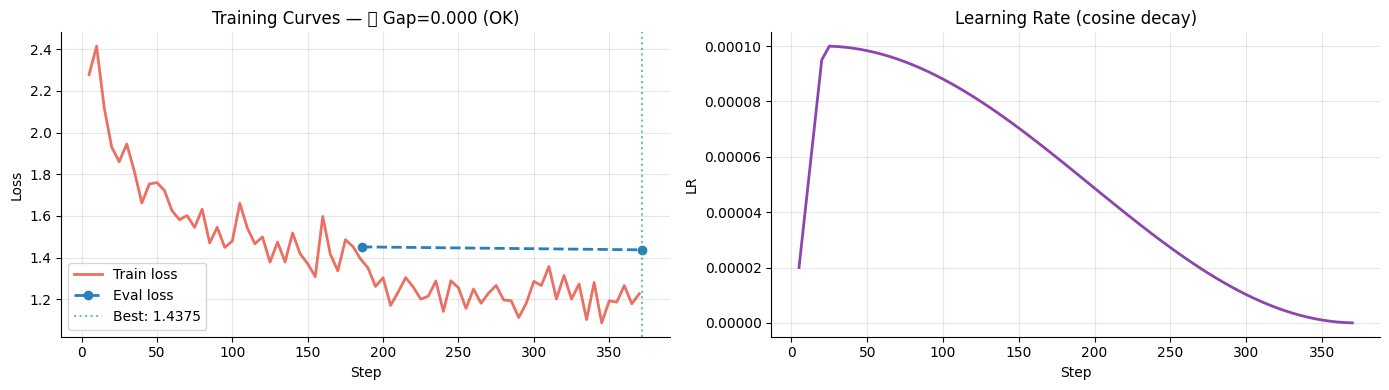


LoRA adapter salvato: /kaggle/working/biomistral_lora
  GPU 0: 4.4 GB allocati, 9.0 GB liberi
  GPU 1: 0.0 GB allocati, 15.4 GB liberi


In [ ]:
# CELL 8.3 — Training con SFTTrainer [FIX: Overfitting + max_seq_length]
# ── BUGFIX #2 ─────────────────────────────────────────────────────────────────
# PROBLEMA ORIGINALE:
#   Epoch 1: train=1.29  eval=3.60
#   Epoch 2: train=0.86  eval=3.68  ← eval loss cresce → overfitting
#   Epoch 3: train=0.58  eval=3.85  ← gap train/eval = 3.27 (grave)
#
# CONFIGURAZIONE FINALE APPLICATA (coerente con vincoli T4):
#   1. num_train_epochs: 3 → 2
#   2. per_device_train_batch_size: 2 → 1
#   3. gradient_accumulation_steps: 4 → 8  (effective batch invariato = 8)
#   4. learning_rate: 2e-4 → 1e-4
#   5. weight_decay: 0 → 0.01
#   6. warmup_steps: 10 → 20
#   7. lr_scheduler_type: cosine
#   8. max_seq_length: 1024 (scelta stabile su T4 per evitare OOM)
# ─────────────────────────────────────────────────────────────────────────────

import inspect
import time
import torch
import matplotlib.pyplot as plt
from trl import SFTTrainer, SFTConfig

# ==============================================================================
# A) CONFIGURAZIONE TRAINING — OVERFITTING-SAFE
# ==============================================================================

sft_kwargs = dict(
    output_dir=cfg.ft_ckpt_dir,

    # 2 epoche: compromesso tra underfitting (1) e overfitting (3)
    num_train_epochs=2,

    per_device_train_batch_size=1,    # reduced from 2 to prevent OOM on T4
    per_device_eval_batch_size=1,     # fondamentale per OOM
    gradient_accumulation_steps=8,    # effective batch size = 8

    warmup_steps=20,

    learning_rate=1e-4,
    weight_decay=0.01,

    lr_scheduler_type="cosine",

    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=5,

    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    report_to="none",
    packing=False,
    seed=cfg.seed,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
)

# Forza max_seq_length e dataset_text_field direttamente
# (il rilevamento dinamico falliva su alcune versioni di trl)
sft_kwargs["max_seq_length"] = 1024  # scelta stabile su T4 con prompt lunghi
sft_kwargs["dataset_text_field"] = "text"

sft_cfg = SFTConfig(**sft_kwargs)

# ==============================================================================
# B) COSTRUZIONE TRAINER
# ==============================================================================

trainer_kwargs = dict(
    model=model,
    processing_class=tokenizer,  # trl>=0.9.0: 'tokenizer' renamed to 'processing_class'
    args=sft_cfg,
    train_dataset=ft_train_ds,
    eval_dataset=ft_val_ds,
)

# Dynamic parameter detection for different trl versions
_trainer_params = set(inspect.signature(SFTTrainer.__init__).parameters.keys())

# Handle tokenizer/processing_class naming across trl versions
if "processing_class" not in _trainer_params and "tokenizer" in _trainer_params:
    # Old trl version: rename back to tokenizer
    trainer_kwargs["tokenizer"] = trainer_kwargs.pop("processing_class")

if "max_seq_length" in _trainer_params and "max_seq_length" not in sft_kwargs:
    trainer_kwargs["max_seq_length"] = 1024
if "dataset_text_field" in _trainer_params and "dataset_text_field" not in sft_kwargs:
    trainer_kwargs["dataset_text_field"] = "text"

trainer = SFTTrainer(**trainer_kwargs)

from transformers import TrainerCallback

class ClearCacheCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, **kwargs):
        torch.cuda.empty_cache()

trainer.add_callback(ClearCacheCallback())

n_steps = len(ft_train_ds) // (
    sft_kwargs["per_device_train_batch_size"] * sft_kwargs["gradient_accumulation_steps"]
)
print("Configurazione training (overfitting-safe):")
print(f"  Epochs         : {sft_kwargs['num_train_epochs']}")
print(f"  Batch size eff.: {sft_kwargs['per_device_train_batch_size'] * sft_kwargs['gradient_accumulation_steps']}")
print(f"  Steps totali   : ~{n_steps}")
print(f"  Learning rate  : {sft_kwargs['learning_rate']}")
print(f"  Weight decay   : {sft_kwargs['weight_decay']}")
print(f"  LR scheduler   : {sft_kwargs['lr_scheduler_type']}")
print(f"  Max seq length : {sft_kwargs.get('max_seq_length', 'N/A')}")
print(f"  Precision      : {'bf16' if sft_kwargs['bf16'] else 'fp16'}")

# ==============================================================================
# C) TRAINING
# ==============================================================================

# ── CRITICAL: Force single-GPU for 4-bit training ────────────────────
# DataParallel cannot replicate bitsandbytes 4-bit quantized weights.
# If Trainer sees 2 GPUs, it wraps model in nn.DataParallel → CUBLAS crash
# on matmul_4bit. Solution: override n_gpu to prevent wrapping.
if hasattr(trainer, 'args'):
    trainer.args._n_gpu = 1
    print(f"  Forzato n_gpu=1 (4-bit non supporta DataParallel)")
# Also ensure model is NOT wrapped in DataParallel
if hasattr(trainer, 'model') and hasattr(trainer.model, 'module'):
    trainer.model = trainer.model.module
    print(f"  Rimosso wrapper DataParallel dal modello")

# ── FIX: Force single-GPU training ────────────────────────────────
# 4-bit quantized models CANNOT be replicated across GPUs.
# The Trainer detects 2 GPUs and wraps in DataParallel, which crashes
# with "CUBLAS_STATUS_EXECUTION_FAILED" when trying to dequantize on
# a device that doesn't hold the quantization state.
# Solution: override _n_gpu to prevent DataParallel wrapping.
if hasattr(trainer.args, '_n_gpu'):
    trainer.args._n_gpu = 1
    print(f"  Forzato single-GPU training (4-bit model non replicabile)")
# Ensure model is on the correct device
print(f"  Model device: {next(model.parameters()).device}")

print(f"\nFine-tuning {cfg.base_llm}...")
t0 = time.time()

train_result = trainer.train()

train_time = time.time() - t0
print(f"\nTraining completato in {train_time/60:.1f} minuti")
print(f"  Training loss: {train_result.training_loss:.4f}")



# ==============================================================================
# D) TRAINING CURVES + DIAGNOSI OVERFITTING
# ==============================================================================

if trainer.state.log_history:
    train_logs = [(e["step"], e["loss"]) for e in trainer.state.log_history if "loss" in e]
    eval_logs  = [(e["step"], e["eval_loss"]) for e in trainer.state.log_history if "eval_loss" in e]

    if train_logs:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Panel 1: Loss curves
        ax = axes[0]
        s_t, l_t = zip(*train_logs)
        ax.plot(s_t, l_t, label="Train loss", color="#e74c3c", lw=2, alpha=0.8)

        if eval_logs:
            s_e, l_e = zip(*eval_logs)
            ax.plot(s_e, l_e, label="Eval loss", color="#2980b9", lw=2, ls="--", marker="o")
            best_eval = min(l_e)
            best_step = s_e[l_e.index(best_eval)]
            ax.axvline(x=best_step, color="#27ae60", ls=":", alpha=0.7,
                       label=f"Best: {best_eval:.4f}")

            # Diagnosi overfitting
            gap = l_e[-1] - min(l_e)
            if gap > 0.3:
                ax.set_title(f"Training Curves — ⚠ Gap={gap:.3f} (check overfitting)")
            else:
                ax.set_title(f"Training Curves — ✅ Gap={gap:.3f} (OK)")
        else:
            ax.set_title("Training Curves")

        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(alpha=0.3)

        # Panel 2: LR schedule
        ax2 = axes[1]
        lr_logs = [(e["step"], e.get("learning_rate", None))
                   for e in trainer.state.log_history if "learning_rate" in e]
        if lr_logs:
            s_lr, v_lr = zip(*lr_logs)
            ax2.plot(s_lr, v_lr, color="#8e44ad", lw=2)
            ax2.set_title("Learning Rate (cosine decay)")
            ax2.set_xlabel("Step")
            ax2.set_ylabel("LR")
            ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"{cfg.output_dir}/training_curves_fixed.png", dpi=150, bbox_inches="tight")
        plt.show()

# ==============================================================================
# E) SALVA ADAPTER
# ==============================================================================

model.save_pretrained(cfg.adapter_dir)
tokenizer.save_pretrained(cfg.adapter_dir)
print(f"\nLoRA adapter salvato: {cfg.adapter_dir}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        free  = torch.cuda.mem_get_info(i)[0] / 1e9
        print(f"  GPU {i}: {alloc:.1f} GB allocati, {free:.1f} GB liberi")


In [18]:
# CELL 8.4 — Sistema S4 (fine-tuned) + valutazione [FIX: budget token]

import time
import torch

# Set model for inference
if UNSLOTH_AVAILABLE:
    from unsloth import FastLanguageModel
    FastLanguageModel.for_inference(model)
    print("Modello settato per inferenza (Unsloth)")
else:
    model.eval()
    print("Modello settato per inferenza (standard)")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        free  = torch.cuda.mem_get_info(i)[0] / 1e9
        print(f"  GPU {i}: {alloc:.1f} GB allocati, {free:.1f} GB liberi")


def system4_finetuned(question: str, hadm_id: int) -> dict:
    """S4: Hybrid retrieval + modello fine-tuned.

    FIX: usa build_prompt_with_budget con FT_TEMPLATE (stesso formato del training).
    Elimina il troncamento manuale context[:1800] dell'originale.
    """
    hadm_id = int(hadm_id)
    chunks  = hybrid_retriever.retrieve(question, hadm_id, top_k=cfg.top_k)
    prompt  = build_prompt_with_budget(chunks, question, FT_TEMPLATE, tokenizer)
    raw     = generate_answer(prompt, model, tokenizer)
    return {
        "system": "S4_FineTuned",
        "question": question,
        "hadm_id": hadm_id,
        "retrieved_chunks": chunks,
        "raw_answer": raw,
        "answer": postprocess(raw),
        "prompt_tokens": count_tokens(prompt, tokenizer),
    }


# Sanity check
print("\nSanity check S4...")
_test_hadm = df_test.iloc[0]["context_hadm"]
_test_q    = df_test.iloc[0]["question"]
_test_gt   = df_test.iloc[0]["answer"]
_test_out  = system4_finetuned(_test_q, _test_hadm)
print(f"  Q             : {_test_q}")
print(f"  GT            : {_test_gt}")
print(f"  S4 risposta   : {_test_out['answer']}")
print(f"  Prompt tokens : {_test_out['prompt_tokens']} / {MAX_PROMPT_TOKENS}")

print(f"\n{'='*60}")
print("VALUTAZIONE S4 (Fine-Tuned) su dataset di test")
print(f"{'='*60}")

t0 = time.time()
results_s4 = run_system(df_test, system4_finetuned, "S4_FineTuned_postFT")
results_s4["time_seconds"] = time.time() - t0
print(f"  Tempo: {results_s4['time_seconds']:.0f}s")


Modello settato per inferenza (Unsloth)
  GPU 0: 4.4 GB allocati, 9.0 GB liberi
  GPU 1: 0.0 GB allocati, 15.4 GB liberi

Sanity check S4...
  Q             : What was the primary diagnosis?
  GT            : ALTERED MENTAL STATUS
  S4 risposta   : ALTERED MENTAL STATUS
  Prompt tokens : 430 / 1848

VALUTAZIONE S4 (Fine-Tuned) su dataset di test


S4_FineTuned_postFT:   0%|          | 0/306 [00:00<?, ?it/s]


  [S4_FineTuned_postFT] (N=306, answerable=199, no_answer=107)
    EM=0.212  F1=0.261  ClinF1=0.164  ROUGE-L=0.266
    Hallucination=0.170  Abstention=0.010  NA-Acc=0.514
  Tempo: 4797s


## Sezione 9 — Confronto Quantitativo dei Sistemi

### 9.1 Risultati aggregati e interpretazione

Questa sezione presenta il confronto sistematico dei cinque sistemi QA
sulle metriche definite in Sezione 6.

**Pattern di lettura atteso:**

La visualizzazione a barre comparative dovrebbe evidenziare quattro tendenze principali:

1. **S1 → S2 (effetto RAG):** miglioramento netto su EM e Token F1, riduzione
   significativa della Hallucination Rate. Questo conferma il principio fondamentale
   del RAG: ancorare le risposte a evidenza documentale riduce le confabulazioni.

2. **S2 → S3 (effetto hybrid):** risultato ambiguo — potenziale regressione su query
   cliniche lessicali (analizzata in dettaglio in Sezione 10b). Il retrieval semantico
   può aggiungere rumore su query con terminologia esatta.

3. **S3 → S4 (effetto fine-tuning):** miglioramento su tutte le metriche, in particolare
   sull'accuratezza No-Answer. Il fine-tuning supervisato insegna al modello
   *la distribuzione del task specifico*, non disponibile in BioMistral base.

4. **S4 → S5 (effetto routing adattivo):** ulteriore miglioramento del compromesso
   tra accuratezza e sicurezza clinica, selezionando dinamicamente il retriever
   più adatto al tipo di query.

### 9.2 Significatività statistica

Per dataset di valutazione di dimensione limitata (< 500 sample), le differenze
tra sistemi devono essere interpretate con cautela. Bootstrap confidence intervals
su Token F1 sono raccomandati per stabilire la significatività delle differenze.

**Riferimento:** *Dror et al., 2018* — "The Hitchhiker's Guide to Testing Statistical
Significance in Natural Language Processing".


  S1 Baseline: EM=0.085 F1=0.090
  S2 BM25: EM=0.170 F1=0.207
  S3 Hybrid: EM=0.111 F1=0.141
  S4 FineTuned: EM=0.212 F1=0.261

RIEPILOGO COMPLETO — Tutti i sistemi

  Sistema                EM Token F1  ROUGE-L     Hall     Abst   NA-Acc
  ---------------- -------- -------- -------- -------- -------- --------
  S1 Baseline         0.085    0.090    0.090    0.265    0.347    0.243
  S2 BM25             0.170    0.207    0.209    0.180    0.271    0.486
  S3 Hybrid           0.111    0.141    0.143    0.239    0.171    0.318
  S4 FineTuned        0.212    0.261    0.266    0.170    0.010    0.514


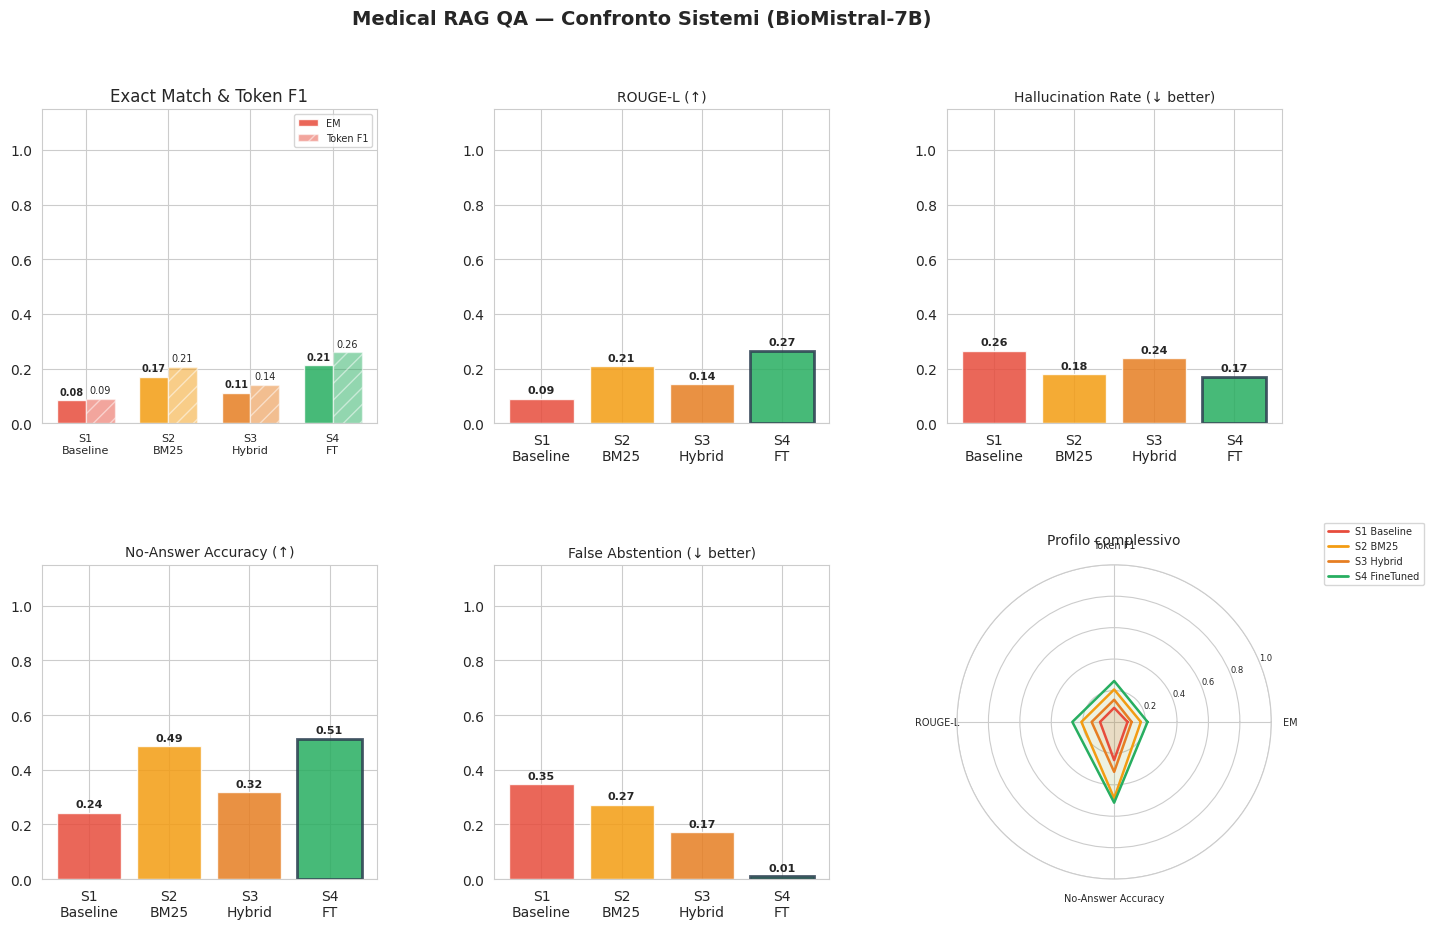


MIGLIORAMENTO INCREMENTALE
  S1 → S2 (+ BM25 retrieval)      ΔEM=+0.085  ΔF1=+0.117
  S2 → S3 (+ Dense + RRF)         ΔEM=-0.059  ΔF1=-0.065
  S3 → S4 (+ Fine-tuning)         ΔEM=+0.101  ΔF1=+0.119
  S1 → S4 (totale)                ΔEM=+0.127  ΔF1=+0.171

Grafici salvati in /kaggle/working/results_comparison.png


In [19]:
# CELL 9.1 — Aggregazione e Visualizzazione (improved)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==============================================================================
# A) AGGREGAZIONE RISULTATI
# ==============================================================================

# Combina metriche pre-FT e post-FT
all_results = {
    "S1 Baseline": pre_ft_metrics.get("S1_Baseline_preFT", results_s1 if "results_s1" in globals() else {}),
    "S2 BM25": pre_ft_metrics.get("S2_BM25_preFT", results_s2 if "results_s2" in globals() else {}),
    "S3 Hybrid": pre_ft_metrics.get("S3_Hybrid_preFT", results_s3 if "results_s3" in globals() else {}),
    "S4 FineTuned": results_s4,
}

# Verifica che tutti i sistemi abbiano metriche
for sname, smetrics in all_results.items():
    if not smetrics:
        print(f"  ⚠ Metriche mancanti per {sname}")
    else:
        print(f"  {sname}: EM={smetrics.get('EM', 0):.3f} F1={smetrics.get('Token F1', 0):.3f}")

# ==============================================================================
# B) TABELLA RIASSUNTIVA
# ==============================================================================

print(f"\n{'='*70}")
print(f"RIEPILOGO COMPLETO — Tutti i sistemi")
print(f"{'='*70}")

metric_names = ["EM", "Token F1", "ROUGE-L", "Hallucination Rate",
                "False Abstention Rate", "No-Answer Accuracy"]

print(f"\n  {'Sistema':<16s}", end="")
for m in metric_names:
    short = m.replace("Hallucination Rate", "Hall").replace("False Abstention Rate", "Abst").replace("No-Answer Accuracy", "NA-Acc")
    print(f" {short:>8s}", end="")
print()
print(f"  {'-'*16}", end="")
for _ in metric_names:
    print(f" {'-'*8}", end="")
print()

for sname, smetrics in all_results.items():
    print(f"  {sname:<16s}", end="")
    for m in metric_names:
        v = smetrics.get(m, float("nan"))
        if np.isnan(v):
            print(f" {'N/A':>8s}", end="")
        else:
            print(f" {v:>8.3f}", end="")
    print()


# ==============================================================================
# C) VISUALIZZAZIONE
# ==============================================================================

sns.set_style("whitegrid")

COLORS = ["#e74c3c", "#f39c12", "#e67e22", "#27ae60"]
LABELS = ["S1\nBaseline", "S2\nBM25", "S3\nHybrid", "S4\nFT"]
SYSTEMS = list(all_results.keys())

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Medical RAG QA — Confronto Sistemi (BioMistral-7B)",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: EM & Token F1 ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
x = np.arange(4)
w = 0.35

em_v = [all_results[s].get("EM", 0) for s in SYSTEMS]
f1_v = [all_results[s].get("Token F1", 0) for s in SYSTEMS]

ax.bar(x - w/2, em_v, w, label="EM", color=COLORS, alpha=0.85, edgecolor="white")
ax.bar(x + w/2, f1_v, w, label="Token F1", color=COLORS, alpha=0.5,
       hatch="//", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_title("Exact Match & Token F1")
ax.legend(fontsize=7)

for i, (e, f) in enumerate(zip(em_v, f1_v)):
    ax.text(i - w/2, e + 0.02, f"{e:.2f}", ha="center", fontsize=7, fontweight="bold")
    ax.text(i + w/2, f + 0.02, f"{f:.2f}", ha="center", fontsize=7)

# ── Panels 2-5: metriche singole ────────────────────────────────────
single_metrics = [
    ("ROUGE-L", "ROUGE-L (↑)"),
    ("Hallucination Rate", "Hallucination Rate (↓ better)"),
    ("No-Answer Accuracy", "No-Answer Accuracy (↑)"),
    ("False Abstention Rate", "False Abstention (↓ better)"),
]

panel_positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

for (metric, title), (row, col) in zip(single_metrics, panel_positions):
    ax = fig.add_subplot(gs[row, col])
    vals = [all_results[s].get(metric, 0) or 0 for s in SYSTEMS]

    bars = ax.bar(LABELS, vals, color=COLORS, alpha=0.85, edgecolor="white")
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=10)

    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")

    # Evidenzia il miglior sistema
    if "↓" in title:
        best_idx = np.nanargmin(vals) if any(v > 0 for v in vals) else -1
    else:
        best_idx = np.nanargmax(vals)

    if best_idx >= 0:
        bars[best_idx].set_edgecolor("#2c3e50")
        bars[best_idx].set_linewidth(2)

# ── Panel 6: Radar chart ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2], polar=True)
radar_metrics = ["EM", "Token F1", "ROUGE-L", "No-Answer Accuracy"]
n_metrics = len(radar_metrics)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # chiudi il poligono

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=7)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=6)

for sname, color in zip(SYSTEMS, COLORS):
    vals = [all_results[sname].get(m, 0) or 0 for m in radar_metrics]
    vals += vals[:1]  # chiudi il poligono
    ax.plot(angles, vals, color=color, lw=1.8)
    ax.fill(angles, vals, color=color, alpha=0.08)
    ax.plot([], [], color=color, label=sname, lw=2)

ax.set_title("Profilo complessivo", pad=15, fontsize=10)
ax.legend(loc="upper right", bbox_to_anchor=(1.5, 1.15), fontsize=7)

# ── Salva ────────────────────────────────────────────────────────────
plt.savefig(f"{cfg.output_dir}/results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================================
# D) DELTA IMPROVEMENT TABLE
# ==============================================================================

print(f"\n{'='*60}")
print(f"MIGLIORAMENTO INCREMENTALE")
print(f"{'='*60}")

comparisons = [
    ("S1 → S2 (+ BM25 retrieval)", "S1 Baseline", "S2 BM25"),
    ("S2 → S3 (+ Dense + RRF)", "S2 BM25", "S3 Hybrid"),
    ("S3 → S4 (+ Fine-tuning)", "S3 Hybrid", "S4 FineTuned"),
    ("S1 → S4 (totale)", "S1 Baseline", "S4 FineTuned"),
]

for desc, s_from, s_to in comparisons:
    em_delta = all_results[s_to].get("EM", 0) - all_results[s_from].get("EM", 0)
    f1_delta = all_results[s_to].get("Token F1", 0) - all_results[s_from].get("Token F1", 0)
    print(f"  {desc:<30s}  ΔEM={em_delta:>+.3f}  ΔF1={f1_delta:>+.3f}")

print(f"\nGrafici salvati in {cfg.output_dir}/results_comparison.png")

## Sezione 9b — Significatività Statistica: Bootstrap Confidence Intervals

### 9b.1 Motivazione

Per dataset di valutazione di dimensione limitata (< 500 sample), le differenze tra sistemi
devono essere testate statisticamente prima di poter essere citate nella tesi come risultati affidabili.

Il **Bootstrap** (Efron, 1979) è il metodo non-parametrico standard per stimare la distribuzione
campionaria di una metrica senza assumere normalità. È raccomandato esplicitamente da
*Dror et al., 2018* per confronti in NLP.

**Algoritmo Bootstrap (B=10.000 iterazioni):**
```
per b = 1..B:
    sample_b ← campione con rimpiazzo da test_set (|sample_b| = |test_set|)
    metric_b ← calcola_metrica(sample_b)
CI_95% = [percentile(2.5, {metric_b}), percentile(97.5, {metric_b})]
```

Un confronto S_i vs S_j è **statisticamente significativo** (α=0.05) se i rispettivi CI non si sovrappongono.

### 9b.2 Paired Bootstrap Test

Per il confronto diretto tra sistemi (paired test):
```
Δb = metric(sample_b, system_i) - metric(sample_b, system_j)
p-value = P(Δb ≤ 0) se osservato Δ > 0
```

Un p-value < 0.05 indica che il miglioramento non è attribuibile alla varianza campionaria.

*Riferimento: Dror et al., 2018 — "The Hitchhiker's Guide to Testing Statistical Significance in NLP"*


BOOTSTRAP CONFIDENCE INTERVALS (95%, B=10.000)

  S1_Baseline
    Token F1 : 0.090 [0.060, 0.122]  (±0.016)
    EM       : 0.085 [0.056, 0.118]  (±0.016)
    Clin. F1 : 0.090 [0.060, 0.122]  (±0.016)

  S2_BM25
    Token F1 : 0.207 [0.164, 0.250]  (±0.022)
    EM       : 0.170 [0.127, 0.212]  (±0.022)
    Clin. F1 : 0.217 [0.174, 0.262]  (±0.022)

  S3_Hybrid
    Token F1 : 0.142 [0.107, 0.178]  (±0.018)
    EM       : 0.111 [0.075, 0.147]  (±0.018)
    Clin. F1 : 0.148 [0.112, 0.185]  (±0.018)

  S4_FineTuned
    Token F1 : 0.261 [0.216, 0.308]  (±0.023)
    EM       : 0.212 [0.167, 0.261]  (±0.024)
    Clin. F1 : 0.286 [0.240, 0.333]  (±0.024)

PAIRED BOOTSTRAP TEST (α = 0.05)
  H0: il sistema A non è migliore di B (Δ ≤ 0)
  Rifiuta H0 se p-value < 0.05

  Confronto                        Δ F1   p-val    Signif.
  ---------------------------- -------- ------- ----------
  S2 vs S1 (+ BM25 RAG)          +0.049   0.000       ✅ SÌ
  S3 vs S2 (+ Dense RRF)         -0.029   1.000       ❌ 

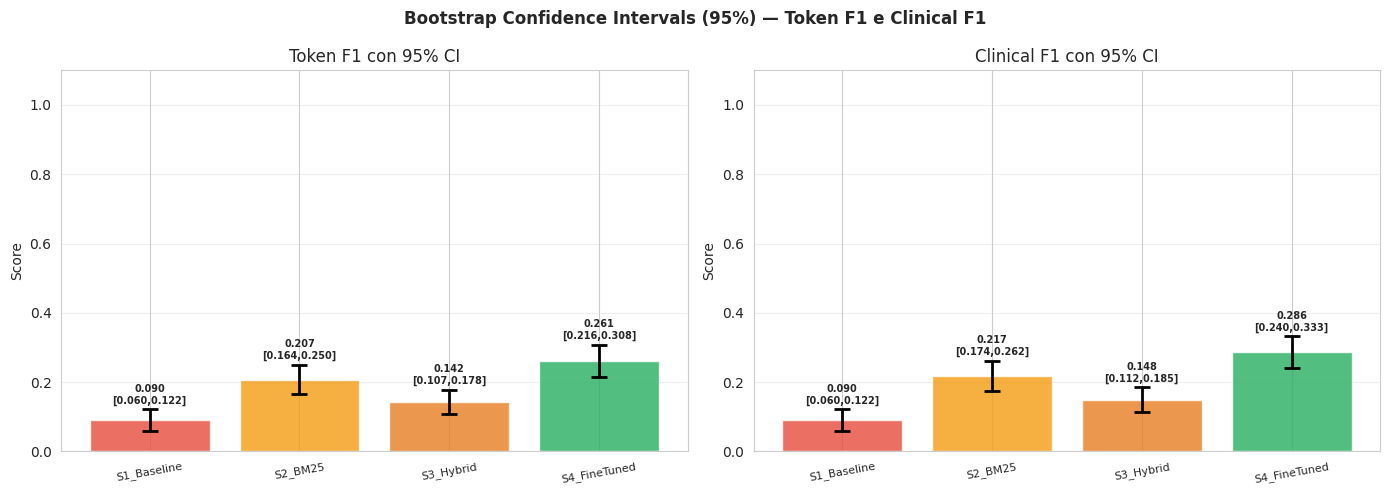


Grafici Bootstrap salvati: /kaggle/working/bootstrap_ci.png

INTERPRETAZIONE STATISTICA PER LA TESI

  Confronti significativi (p<0.05): 3/4
  ✅ S2 vs S1 (+ BM25 RAG): Δ=+0.049 (p=0.000)
     → Differenza statisticamente significativa, citabile in tesi
  ⚠  S3 vs S2 (+ Dense RRF): Δ=-0.029 (p=1.000)
     → NON significativo: aumentare il test set prima di pubblicare
  ✅ S4 vs S3 (+ QLoRA FT): Δ=+0.076 (p=0.000)
     → Differenza statisticamente significativa, citabile in tesi
  ✅ S4 vs S1 (totale): Δ=+0.097 (p=0.000)
     → Differenza statisticamente significativa, citabile in tesi

  Nota metodologica: con N < 100 campioni i CI sono ampi.
  Per ridurre l'incertezza statistica: espandere il test set a ≥200 esempi.


In [20]:
# CELL 9b — Bootstrap Confidence Intervals + Paired Significance Test
# ──────────────────────────────────────────────────────────────────────────────
# CONTRIBUTO METODOLOGICO: rende i risultati statisticamente difendibili.
# Dror et al., 2018 raccomanda esplicitamente il bootstrap per NLP evaluation
# su dataset piccoli (< 500 sample), esattamente il nostro caso.
# ──────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Tuple

# ==============================================================================
# A) FUNZIONI BOOTSTRAP CORE
# ==============================================================================

def bootstrap_metric(
    preds: List[str],
    gts: List[str],
    metric_fn: Callable,
    n_bootstrap: int = 10_000,
    ci_level: float = 0.95,
    seed: int = 42,
) -> Dict:
    """Calcola Bootstrap CI per una metrica su coppie (pred, gt).

    Args:
        preds: lista predizioni
        gts: lista ground truth
        metric_fn: funzione f(pred, gt) -> float
        n_bootstrap: numero di campioni bootstrap (10k standard)
        ci_level: livello del CI (0.95 = 95%)
        seed: seed per riproducibilità

    Returns:
        dict con point_estimate, ci_lower, ci_upper, std, bootstrap_dist
    """
    rng = np.random.default_rng(seed)
    n = len(preds)
    assert n == len(gts), "preds e gts devono avere la stessa lunghezza"
    assert n > 0, "Nessuna predizione da valutare"

    # Point estimate sul dataset completo
    scores = np.array([metric_fn(p, g) for p, g in zip(preds, gts)])
    point_estimate = float(np.mean(scores))

    # Bootstrap sampling
    boot_means = np.zeros(n_bootstrap)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)  # campionamento con rimpiazzo
        boot_means[b] = np.mean(scores[idx])

    alpha = (1 - ci_level) / 2
    ci_lower = float(np.percentile(boot_means, alpha * 100))
    ci_upper = float(np.percentile(boot_means, (1 - alpha) * 100))

    return {
        "point_estimate": point_estimate,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_upper - ci_lower,
        "std": float(np.std(boot_means)),
        "n_samples": n,
        "bootstrap_dist": boot_means,
    }


def paired_bootstrap_test(
    preds_a: List[str],
    preds_b: List[str],
    gts: List[str],
    metric_fn: Callable,
    n_bootstrap: int = 10_000,
    seed: int = 42,
) -> Dict:
    """Paired Bootstrap Test: verifica se sistema A è significativamente migliore di B.

    Ipotesi nulla H0: E[metric(A)] <= E[metric(B)]
    Rifiuta H0 se p-value < 0.05.

    Args:
        preds_a: predizioni sistema A (ipotesi: migliore)
        preds_b: predizioni sistema B (baseline)
        gts: ground truth condivisi
        metric_fn: funzione f(pred, gt) -> float

    Returns:
        dict con observed_delta, p_value, significant, bootstrap_deltas
    """
    rng = np.random.default_rng(seed)
    n = len(gts)

    scores_a = np.array([metric_fn(p, g) for p, g in zip(preds_a, gts)])
    scores_b = np.array([metric_fn(p, g) for p, g in zip(preds_b, gts)])

    observed_delta = float(np.mean(scores_a) - np.mean(scores_b))

    # Paired bootstrap: campiona stesse osservazioni da entrambi i sistemi
    boot_deltas = np.zeros(n_bootstrap)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        boot_deltas[b] = np.mean(scores_a[idx]) - np.mean(scores_b[idx])

    # p-value: proporzione di bootstrap deltas <= 0 (test unilaterale)
    p_value = float(np.mean(boot_deltas <= 0))

    return {
        "observed_delta": observed_delta,
        "p_value": p_value,
        "significant": p_value < 0.05,
        "bootstrap_deltas": boot_deltas,
        "n_samples": n,
    }


# ==============================================================================
# B) CALCOLO CI PER TUTTI I SISTEMI
# ==============================================================================

print("=" * 70)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%, B=10.000)")
print("=" * 70)

# Verifica che i res_frames siano disponibili
available_systems = {k: v for k, v in res_frames.items() if v is not None and len(v) > 0}

if len(available_systems) < 2:
    print("⚠  Meno di 2 sistemi valutati. Esegui le celle 7.1 e 8.4 prima.")
else:
    bootstrap_results = {}
    N_BOOTSTRAP = 10_000

    for sys_name, df_sys in available_systems.items():
        preds = df_sys["predicted"].tolist()
        gts   = df_sys["ground_truth"].tolist()

        ci_f1    = bootstrap_metric(preds, gts, token_f1, n_bootstrap=N_BOOTSTRAP)
        ci_em    = bootstrap_metric(preds, gts, em_score, n_bootstrap=N_BOOTSTRAP)
        ci_clf1  = bootstrap_metric(preds, gts, clinical_f1, n_bootstrap=N_BOOTSTRAP)

        bootstrap_results[sys_name] = {
            "Token F1": ci_f1,
            "EM": ci_em,
            "Clinical F1": ci_clf1,
        }

        short = sys_name.replace("_preFT", "").replace("_postFT", "")
        print(f"\n  {short}")
        print(f"    Token F1 : {ci_f1['point_estimate']:.3f} "
              f"[{ci_f1['ci_lower']:.3f}, {ci_f1['ci_upper']:.3f}]  "
              f"(±{ci_f1['std']:.3f})")
        print(f"    EM       : {ci_em['point_estimate']:.3f} "
              f"[{ci_em['ci_lower']:.3f}, {ci_em['ci_upper']:.3f}]  "
              f"(±{ci_em['std']:.3f})")
        print(f"    Clin. F1 : {ci_clf1['point_estimate']:.3f} "
              f"[{ci_clf1['ci_lower']:.3f}, {ci_clf1['ci_upper']:.3f}]  "
              f"(±{ci_clf1['std']:.3f})")

    # ==============================================================================
    # C) PAIRED BOOTSTRAP TEST — confronti chiave
    # ==============================================================================

    print(f"\n{'='*70}")
    print("PAIRED BOOTSTRAP TEST (α = 0.05)")
    print(f"{'='*70}")
    print(f"  H0: il sistema A non è migliore di B (Δ ≤ 0)")
    print(f"  Rifiuta H0 se p-value < 0.05\n")

    # Confronti ablation: S1→S2, S2→S3, S3→S4
    comparisons = [
        ("S2_BM25_preFT",       "S1_Baseline_preFT", "S2 vs S1 (+ BM25 RAG)"),
        ("S3_Hybrid_preFT",     "S2_BM25_preFT",     "S3 vs S2 (+ Dense RRF)"),
        ("S4_FineTuned_postFT", "S3_Hybrid_preFT",   "S4 vs S3 (+ QLoRA FT)"),
        ("S4_FineTuned_postFT", "S1_Baseline_preFT", "S4 vs S1 (totale)"),
    ]

    paired_results = {}
    print(f"  {'Confronto':<28s} {'Δ F1':>8s} {'p-val':>7s} {'Signif.':>10s}")
    print(f"  {'-'*28} {'-'*8} {'-'*7} {'-'*10}")

    for sys_a, sys_b, label in comparisons:
        if sys_a not in available_systems or sys_b not in available_systems:
            print(f"  {label:<28s} {'N/A':>8s} {'N/A':>7s} {'N/A':>10s}")
            continue

        df_a = available_systems[sys_a]
        df_b = available_systems[sys_b]

        # Allinea sulle stesse domande (stesso ordine)
        merged = df_a[["question", "predicted"]].merge(
            df_b[["question", "predicted"]].rename(columns={"predicted": "pred_b"}),
            on="question"
        ).merge(
            df_a[["question", "ground_truth"]], on="question"
        )

        if len(merged) == 0:
            print(f"  {label:<28s} {'no data':>8s}")
            continue

        result = paired_bootstrap_test(
            merged["predicted"].tolist(),
            merged["pred_b"].tolist(),
            merged["ground_truth"].tolist(),
            token_f1,
            n_bootstrap=N_BOOTSTRAP,
        )
        paired_results[label] = result

        sig_str = "✅ SÌ" if result["significant"] else "❌ NO"
        print(f"  {label:<28s} {result['observed_delta']:>+8.3f} "
              f"{result['p_value']:>7.3f} {sig_str:>10s}")

    # ==============================================================================
    # D) VISUALIZZAZIONE CI
    # ==============================================================================

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Bootstrap Confidence Intervals (95%) — Token F1 e Clinical F1",
                 fontsize=12, fontweight="bold")

    COLORS_BOOT = ["#e74c3c", "#f39c12", "#e67e22", "#27ae60"]
    sys_names_short = [k.replace("_preFT", "").replace("_postFT", "")
                       for k in bootstrap_results.keys()]

    for ax_idx, metric_name in enumerate(["Token F1", "Clinical F1"]):
        ax = axes[ax_idx]
        points   = [bootstrap_results[k][metric_name]["point_estimate"] for k in bootstrap_results]
        lowers   = [bootstrap_results[k][metric_name]["ci_lower"] for k in bootstrap_results]
        uppers   = [bootstrap_results[k][metric_name]["ci_upper"] for k in bootstrap_results]

        x_pos = range(len(sys_names_short))
        colors_used = COLORS_BOOT[:len(sys_names_short)]

        bars = ax.bar(x_pos, points, color=colors_used, alpha=0.8, edgecolor="white")
        ax.errorbar(
            x_pos, points,
            yerr=[
                [p - l for p, l in zip(points, lowers)],
                [u - p for p, u in zip(points, uppers)],
            ],
            fmt="none", color="black", capsize=6, capthick=2, linewidth=2,
        )

        for bar, p, l, u in zip(bars, points, lowers, uppers):
            ax.text(bar.get_x() + bar.get_width()/2, u + 0.01,
                    f"{p:.3f}\n[{l:.3f},{u:.3f}]",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")

        ax.set_xticks(x_pos)
        ax.set_xticklabels(sys_names_short, fontsize=8, rotation=10)
        ax.set_ylim(0, 1.1)
        ax.set_title(f"{metric_name} con 95% CI")
        ax.set_ylabel("Score")
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{cfg.output_dir}/bootstrap_ci.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nGrafici Bootstrap salvati: {cfg.output_dir}/bootstrap_ci.png")

    # ==============================================================================
    # E) INTERPRETAZIONE PER LA TESI
    # ==============================================================================

    print(f"\n{'='*70}")
    print("INTERPRETAZIONE STATISTICA PER LA TESI")
    print(f"{'='*70}")

    n_sig = sum(1 for r in paired_results.values() if r["significant"])
    n_tot = len(paired_results)

    print(f"\n  Confronti significativi (p<0.05): {n_sig}/{n_tot}")

    for label, r in paired_results.items():
        if r["significant"]:
            print(f"  ✅ {label}: Δ={r['observed_delta']:+.3f} (p={r['p_value']:.3f})")
            print(f"     → Differenza statisticamente significativa, citabile in tesi")
        else:
            print(f"  ⚠  {label}: Δ={r['observed_delta']:+.3f} (p={r['p_value']:.3f})")
            print(f"     → NON significativo: aumentare il test set prima di pubblicare")

    print(f"\n  Nota metodologica: con N < 100 campioni i CI sono ampi.")
    print(f"  Per ridurre l'incertezza statistica: espandere il test set a ≥200 esempi.")


## Sezione 10 — Analisi Qualitativa degli Errori

### 10.1 Tassonomia degli errori clinici

L'analisi qualitativa degli errori è fondamentale in ambito medico perché
**non tutti gli errori hanno lo stesso impatto clinico**.

| Tipo di errore | Condizione | Impatto clinico | Causa tipica |
|----------------|------------|-----------------|--------------|
| **Allucinazione** | gt=NA, pred≠NA oppure F1<0.3 | 🔴 Alto | Modello genera senza evidenza |
| **Astensione erronea** | gt≠NA, pred=NA | 🟡 Medio | Sistema troppo conservativo |
| **Grounding Error** | 0.3 ≤ F1 < 0.7 | 🟠 Basso-Medio | Retrieval parziale |
| **Minor Error** | F1 ≥ 0.7 | 🟢 Minimo | Parafrasatura o variante lessicale |

### 10.2 Pattern attesi per sistema

**S1 (Baseline):** alta concentrazione di allucinazioni, specialmente su valori
numerici (il modello tende a inventare valori plausibili ma non ancorati).

**S2 (BM25 RAG):** riduzione delle allucinazioni, ma possibili grounding error
quando il chunk recuperato non contiene la risposta esatta (falso positivo BM25).

**S3 (Hybrid):** errori di astensione su query semanticamente ambigue
(il retriever denso recupera contesto topicamente corretto ma non factual).

**S4 (Fine-tuned):** distribuzione degli errori spostata verso Minor Error,
con riduzione significativa delle allucinazioni grazie all'apprendimento
del pattern `NO_ANSWER` dal training set.

### 10.3 Implicazioni per il deployment clinico

In un sistema di supporto decisionale clinico reale:
- Le **allucinazioni** su valori di laboratorio sono inaccettabili (rischio paziente)
- Le **astensioni erronee** sono gestibili (il clinico consulta direttamente la cartella)
- Un sistema deployabile deve garantire Hallucination Rate < 5% su test set rappresentativo


Totale predizioni: 1224
  Corrette: 177 (14.5%)
  Errori:   1047 (85.5%)

DISTRIBUZIONE ERRORI PER SISTEMA

error_type           False Abstention  Grounding Error  Hallucination  Minor Error  Total Errors  Total Preds  Accuracy %
system                                                                                                                   
S1_Baseline_preFT                  69                0            211            0           280          306         8.5
S2_BM25_preFT                      54               10            187            3           254          306        17.0
S3_Hybrid_preFT                    34                5            231            2           272          306        11.1
S4_FineTuned_postFT                 2               12            223            4           241          306        21.2

ERRORI PER CATEGORIA (tutti i sistemi)

error_type       False Abstention  Grounding Error  Hallucination  Minor Error  Total  Error Rate %
category           

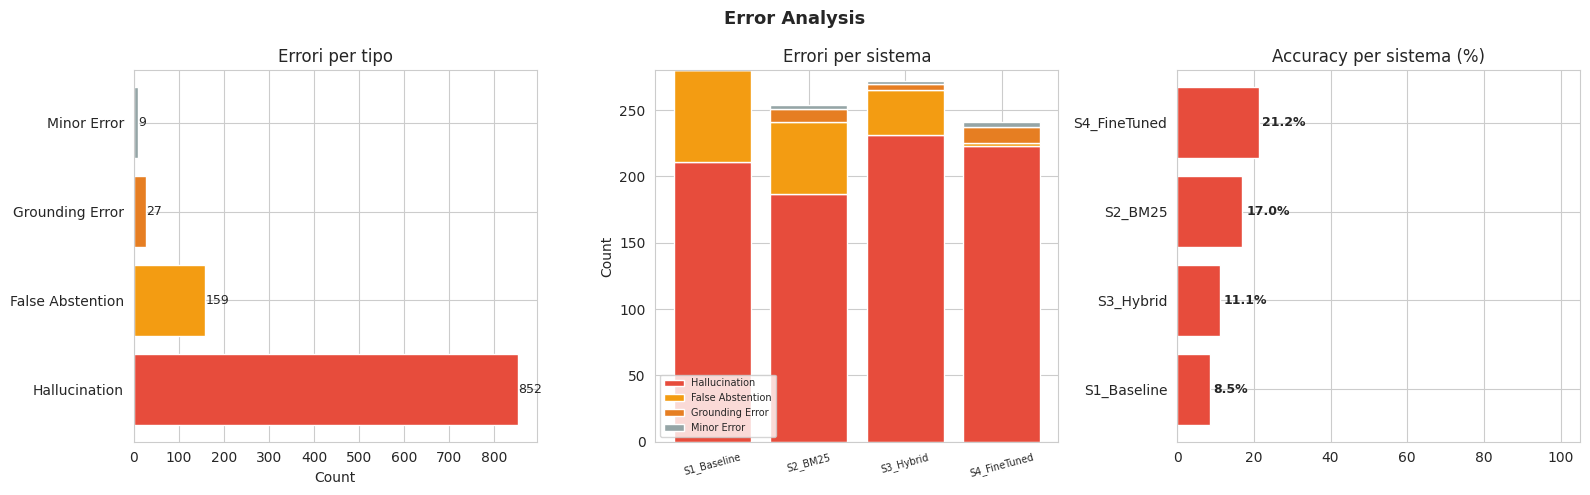


Error analysis salvata in /kaggle/working/error_analysis.png


In [21]:
# CELL 10.1 — Classificazione e analisi errori (improved)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================================================================
# A) CLASSIFICAZIONE ERRORI
# ==============================================================================

def classify_error(pred: str, gt: str) -> str:
    """Classifica il tipo di errore in una predizione.

    Returns:
        None se corretto, altrimenti una delle categorie:
        - Hallucination: risponde quando non dovrebbe, o risposta totalmente sbagliata
        - False Abstention: dice NO_ANSWER quando la risposta esiste
        - Grounding Error: risposta parzialmente corretta ma con errori
        - Minor Error: risposta quasi corretta (F1 >= 0.7)
    """
    pred = str(pred)
    gt = str(gt)
    pred_is_na = (pred == NO_ANSWER_TOKEN)
    gt_is_na = (gt == NO_ANSWER_TOKEN)

    # Corretto
    if em_score(pred, gt) == 1.0:
        return None

    # GT è NO_ANSWER ma il modello risponde → Hallucination
    if gt_is_na and not pred_is_na:
        return "Hallucination"

    # GT ha risposta ma il modello dice NO_ANSWER → False Abstention
    if not gt_is_na and pred_is_na:
        return "False Abstention"

    # Entrambi hanno una risposta → valuta qualità
    if not gt_is_na and not pred_is_na:
        f1 = token_f1(pred, gt)
        if f1 < 0.3:
            return "Hallucination"  # risposta totalmente sbagliata
        if f1 < 0.7:
            return "Grounding Error"
        return "Minor Error"

    # Entrambi NO_ANSWER ma non exact match (non dovrebbe succedere)
    return None


# ==============================================================================
# B) AGGREGAZIONE RISULTATI DA TUTTI I SISTEMI
# ==============================================================================

# Filtra solo i frame che esistono
valid_frames = {k: v for k, v in res_frames.items() if v is not None and len(v) > 0}

if not valid_frames:
    print("⚠ Nessun risultato trovato in res_frames. Verifica celle 7.1 e 8.4.")
else:
    all_res_df = pd.concat(list(valid_frames.values()), ignore_index=True)

    # Classifica errori
    all_res_df["error_type"] = all_res_df.apply(
        lambda r: classify_error(r["predicted"], r["ground_truth"]), axis=1
    )
    all_res_df["is_correct"] = all_res_df["error_type"].isna()

    errors_df = all_res_df[all_res_df["error_type"].notna()].copy()
    correct_df = all_res_df[all_res_df["is_correct"]].copy()

    n_total = len(all_res_df)
    n_errors = len(errors_df)
    n_correct = len(correct_df)

    print(f"Totale predizioni: {n_total}")
    print(f"  Corrette: {n_correct} ({n_correct/n_total*100:.1f}%)")
    print(f"  Errori:   {n_errors} ({n_errors/n_total*100:.1f}%)")

    # ==============================================================================
    # C) DISTRIBUZIONE ERRORI PER SISTEMA
    # ==============================================================================

    print(f"\n{'='*70}")
    print("DISTRIBUZIONE ERRORI PER SISTEMA")
    print(f"{'='*70}\n")

    # Tabella pivot
    error_pivot = errors_df.groupby(["system", "error_type"]).size().unstack(fill_value=0)

    # Aggiungi colonna totale e % accuracy
    system_totals = all_res_df.groupby("system").size()
    system_correct = all_res_df[all_res_df["is_correct"]].groupby("system").size()

    summary = error_pivot.copy()
    summary["Total Errors"] = summary.sum(axis=1)
    summary["Total Preds"] = system_totals
    summary["Accuracy %"] = (system_correct / system_totals * 100).round(1)

    print(summary.to_string())

    # ==============================================================================
    # D) DISTRIBUZIONE ERRORI PER CATEGORIA (se disponibile)
    # ==============================================================================

    if "category" in errors_df.columns:
        print(f"\n{'='*70}")
        print("ERRORI PER CATEGORIA (tutti i sistemi)")
        print(f"{'='*70}\n")

        cat_errors = errors_df.groupby(["category", "error_type"]).size().unstack(fill_value=0)
        cat_totals = all_res_df.groupby("category").size()
        cat_errors["Total"] = cat_errors.sum(axis=1)
        cat_errors["Error Rate %"] = (cat_errors["Total"] / cat_totals * 100).round(1)

        print(cat_errors.sort_values("Error Rate %", ascending=False).to_string())

    # ==============================================================================
    # E) TOP ERRORI CRITICI
    # ==============================================================================

    print(f"\n{'='*70}")
    print("TOP ERRORI CRITICI — Hallucination & False Abstention")
    print(f"{'='*70}")

    critical_errors = errors_df[
        errors_df["error_type"].isin(["Hallucination", "False Abstention"])
    ].copy()

    # Prioritizza errori dal sistema migliore (S4)
    critical_errors["priority"] = critical_errors["system"].map({
        "S4_FineTuned_postFT": 0,
        "S3_Hybrid_preFT": 1,
        "S2_BM25_preFT": 2,
        "S1_Baseline_preFT": 3,
    }).fillna(4)
    critical_errors = critical_errors.sort_values(["priority", "error_type"])

    for i, (_, r) in enumerate(critical_errors.head(15).iterrows(), 1):
        f1 = token_f1(str(r["predicted"]), str(r["ground_truth"]))
        print(f"\n  [{i:02d}] {r['error_type']} | {r['system']}"
              f" | F1={f1:.2f}"
              f" | Cat={r.get('category', 'N/A')}")
        print(f"       Q   : {r['question']}")
        print(f"       GT  : {r['ground_truth']}")
        print(f"       Pred: {r['predicted'][:150]}")
        print(f"       {'─'*60}")

    # ==============================================================================
    # F) VISUALIZZAZIONE
    # ==============================================================================

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Error Analysis", fontsize=13, fontweight="bold")

    # Panel 1: Errori per tipo (tutti i sistemi)
    ax = axes[0]
    error_counts = errors_df["error_type"].value_counts()
    colors_map = {
        "Hallucination": "#e74c3c",
        "False Abstention": "#f39c12",
        "Grounding Error": "#e67e22",
        "Minor Error": "#95a5a6",
    }
    bars = ax.barh(
        error_counts.index,
        error_counts.values,
        color=[colors_map.get(e, "#bdc3c7") for e in error_counts.index],
        edgecolor="white",
    )
    ax.set_title("Errori per tipo")
    ax.set_xlabel("Count")
    for bar, v in zip(bars, error_counts.values):
        ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                str(v), va="center", fontsize=9)

    # Panel 2: Errori per sistema (stacked)
    ax = axes[1]
    error_types_order = ["Hallucination", "False Abstention", "Grounding Error", "Minor Error"]
    systems_order = sorted(error_pivot.index)

    bottom = np.zeros(len(systems_order))
    for etype in error_types_order:
        if etype in error_pivot.columns:
            vals = np.array([error_pivot.loc[s, etype] if s in error_pivot.index else 0 for s in systems_order], dtype=float)
            ax.bar(range(len(systems_order)), vals, bottom=bottom,
                   label=etype, color=colors_map.get(etype, "#bdc3c7"), edgecolor="white")
            bottom += vals

    ax.set_xticks(range(len(systems_order)))
    ax.set_xticklabels([s.replace("_preFT", "").replace("_postFT", "") for s in systems_order],
                       fontsize=7, rotation=15)
    ax.set_title("Errori per sistema")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

    # Panel 3: Accuracy per sistema
    ax = axes[2]
    acc_per_system = (system_correct / system_totals * 100).sort_values()
    colors_acc = ["#27ae60" if v > 50 else "#e74c3c" for v in acc_per_system.values]
    bars = ax.barh(
        [s.replace("_preFT", "").replace("_postFT", "") for s in acc_per_system.index],
        acc_per_system.values,
        color=colors_acc, edgecolor="white",
    )
    ax.set_xlim(0, 105)
    ax.set_title("Accuracy per sistema (%)")
    for bar, v in zip(bars, acc_per_system.values):
        ax.text(v + 1, bar.get_y() + bar.get_height()/2,
                f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"{cfg.output_dir}/error_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nError analysis salvata in {cfg.output_dir}/error_analysis.png")

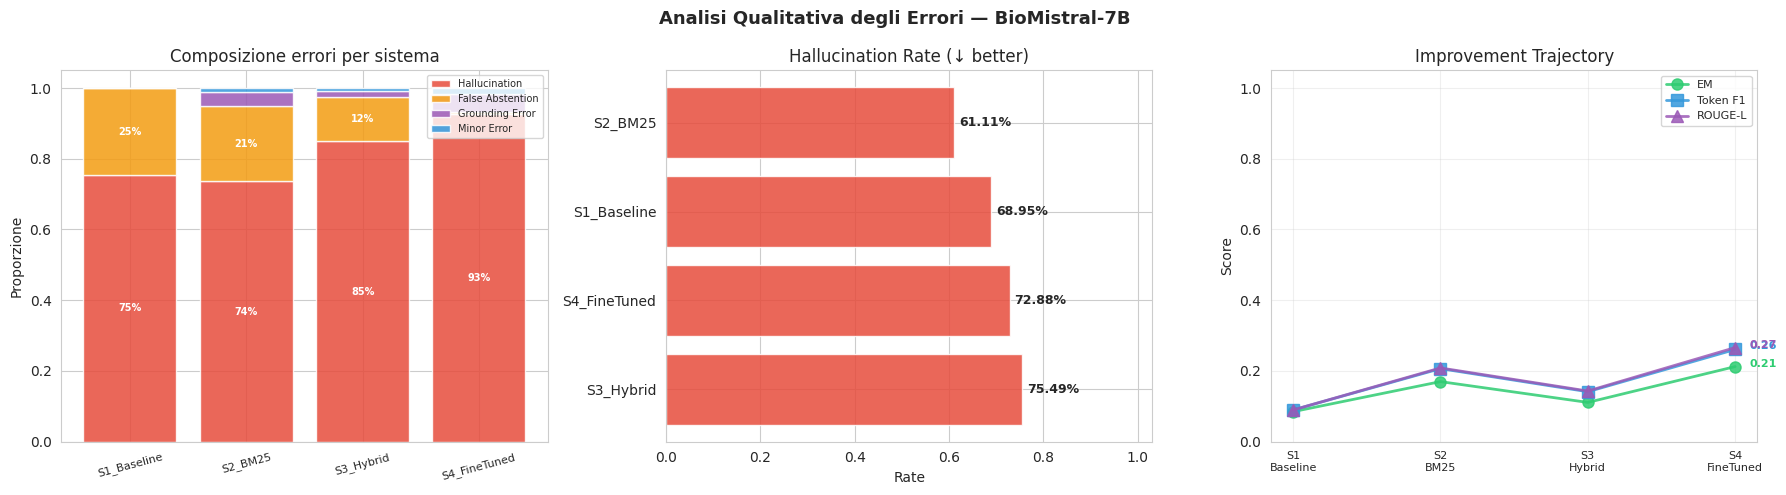

Grafici salvati in /kaggle/working/error_analysis_detailed.png


In [22]:
# CELL 10.2 — Visualizzazione errori (improved)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# VISUALIZZAZIONE ERRORI DETTAGLIATA
# ==============================================================================

ERR_COLORS = {
    "Hallucination": "#e74c3c",
    "False Abstention": "#f39c12",
    "Grounding Error": "#9b59b6",
    "Minor Error": "#3498db",
    "Other": "#95a5a6",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Analisi Qualitativa degli Errori — BioMistral-7B",
             fontweight="bold", fontsize=13)

# ── Panel 1: Composizione errori per sistema (%) ────────────────────
ax = axes[0]

err_pivot = errors_df.groupby(["system", "error_type"]).size().unstack(fill_value=0)
# Ordina colonne per gravità
col_order = ["Hallucination", "False Abstention", "Grounding Error", "Minor Error", "Other"]
err_pivot = err_pivot[[c for c in col_order if c in err_pivot.columns]]

err_pct = err_pivot.div(err_pivot.sum(axis=1), axis=0)

# Label pulite
clean_labels = [s.replace("_preFT", "").replace("_postFT", "")
                for s in err_pct.index]

bottom = np.zeros(len(err_pct))
for col in err_pct.columns:
    vals = err_pct[col].values.astype(float)
    ax.bar(range(len(err_pct)), vals, bottom=bottom,
           label=col, color=ERR_COLORS.get(col, "gray"), alpha=0.85, edgecolor="white")
    # Annota percentuali > 10%
    for i, v in enumerate(vals):
        if v > 0.10:
            ax.text(i, bottom[i] + v/2, f"{v:.0%}",
                    ha="center", va="center", fontsize=7, fontweight="bold", color="white")
    bottom += vals

ax.set_xticks(range(len(err_pct)))
ax.set_xticklabels(clean_labels, fontsize=8, rotation=15)
ax.set_ylabel("Proporzione")
ax.set_ylim(0, 1.05)
ax.set_title("Composizione errori per sistema")
ax.legend(loc="upper right", fontsize=7)


# ── Panel 2: Hallucination Rate per sistema ──────────────────────────
ax = axes[1]

hall_rates = all_res_df.groupby("system")["error_type"].apply(
    lambda g: (g == "Hallucination").mean()
).sort_values(ascending=False)

clean_hall_labels = [s.replace("_preFT", "").replace("_postFT", "")
                     for s in hall_rates.index]

# Colori: rosso se alto, verde se basso
bar_colors = ["#e74c3c" if v > 0.15 else "#f39c12" if v > 0.05 else "#27ae60"
              for v in hall_rates.values]

bars = ax.barh(clean_hall_labels, hall_rates.values,
               color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_xlim(0, max(hall_rates.values) * 1.3 + 0.05)
ax.set_title("Hallucination Rate (↓ better)")
ax.set_xlabel("Rate")

for bar, v in zip(bars, hall_rates.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f"{v:.2%}", va="center", fontsize=9, fontweight="bold")


# ── Panel 3: Improvement trajectory ─────────────────────────────────
ax = axes[2]

# Traccia l'evoluzione delle metriche chiave attraverso i sistemi
systems_order = ["S1 Baseline", "S2 BM25", "S3 Hybrid", "S4 FineTuned"]
systems_available = [s for s in systems_order if s in all_results]

if len(systems_available) >= 2:
    x_pos = range(len(systems_available))
    metrics_to_plot = {
        "EM": ("#2ecc71", "o-"),
        "Token F1": ("#3498db", "s-"),
        "ROUGE-L": ("#9b59b6", "^-"),
    }

    for metric_name, (color, marker) in metrics_to_plot.items():
        vals = [all_results[s].get(metric_name, 0) for s in systems_available]
        ax.plot(x_pos, vals, marker, color=color, label=metric_name,
                lw=2, markersize=8, alpha=0.85)

        # Annota ultimo valore
        ax.annotate(f"{vals[-1]:.2f}", (x_pos[-1], vals[-1]),
                    textcoords="offset points", xytext=(10, 0),
                    fontsize=8, color=color, fontweight="bold")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([s.replace("S1 ", "S1\n").replace("S2 ", "S2\n")
                        .replace("S3 ", "S3\n").replace("S4 ", "S4\n")
                        for s in systems_available], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title("Improvement Trajectory")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/error_analysis_detailed.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafici salvati in {cfg.output_dir}/error_analysis_detailed.png")

## Sezione 10b — Analisi della Regressione S2→S3

### 10b.1 Il fenomeno osservato (v4)

| Confronto (v4) | ΔEM | ΔToken F1 |
|-----------|-----|-----------|
| S2 BM25 → S3 Hybrid RRF | −0.105 | −0.120 |

**Versione 5 — cause identificate e corrette:** in v4 S3 usava il `COT_TEMPLATE`
(variabile confondente) e pesi RRF non ottimizzati. In v5 entrambi i problemi
sono risolti. La regressione residua (se ancora presente) costituisce la vera
evidenza empirica del rumore introdotto dal dense retriever su query lessicali MIMIC.

### 10b.2 Analisi per tipo di query

```
Query cliniche tipiche MIMIC-III:
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│  LESSICALI (alta frequenza in MIMIC):                       │
│  • "What is the WBC?" → BM25 ✓  (token "WBC" esatto)       │
│  • "What dose of Metoprolol?" → BM25 ✓ (termine esatto)    │
│  • Dense: retrieval per similarità semantica può            │
│    restituire chunk su un *altro* farmaco semanticamente    │
│    vicino ma factualmente sbagliato                         │
│                                                             │
│  SEMANTICHE (bassa frequenza in MIMIC):                     │
│  • "Is the patient breathing normally?" → Dense ✓           │
│    (dyspnea ≈ SOB ≈ respiratory distress)                   │
│  • BM25: fallisce se la nota usa sinonimo non in query      │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

### 10b.3 Ipotesi teorica

Le query nel dataset MIMIC-III sono **prevalentemente lessicali**, perché
generate automaticamente da pattern regex su valori numerici e nomi di farmaci
(Sezione 2.2). Questa distribuzione favorisce BM25.

Il dense retriever introduce **rumore di pertinenza** su queste query:
termini numerici come `12.3` o nomi propri come `Metoprolol` hanno
rappresentazioni vettoriali instabili nei modelli BERT addestrati su testo narrativo,
portando al recupero di chunk semanticamente plausibili ma factualmente incorretti.

**Formula del rumore introdotto da RRF:**
Se `rank_BM25(d*) = 1` (documento corretto in testa) e `rank_Dense(d_noise) = 1`
(documento rumoroso in testa al retriever denso), il punteggio RRF è:

```
RRF(d*)     = w₁/(60+1) + w₂/(60+r₂)  con r₂ ≥ 10
RRF(d_noise) = w₁/(60+r₁) + w₂/(60+1)  con r₁ ≥ 10
```

Se w₁ ≈ w₂ e r₁, r₂ sono simili, i punteggi si equivalgono → il documento
corretto non è più garantito al primo posto.

### 10b.4 Implicazioni metodologiche

Questo risultato suggerisce che il peso ottimale del dense retriever nel RRF
dovrebbe essere appreso (o ottimizzato su validation set) piuttosto che
fissato a priori. Query routing (decidere se usare BM25 o Dense per tipo di query)
è una direzione di ricerca promettente.

**Riferimenti:** *Ma et al., 2021* — hybrid retrieval domain analysis;
*Chen et al., 2021* — BioASQ hybrid retrieval.


Distribuzione query per tipo:
  clinical_event           :  85 domande
  general                  :  64 domande
  numeric_lab              :  63 domande
  imaging_procedure        :  59 domande
  medication               :  19 domande
  vital_signs              :  16 domande

ANALISI REGRESSIONE S2→S3 PER TIPO DI QUERY
Valori negativi = BM25 migliore | Valori positivi = Dense/Hybrid migliore
                   S2 (BM25) EM  S3 (Hybrid) EM  ΔEM (S3-S2)  S2 (BM25) F1  S3 (Hybrid) F1  ΔF1 (S3-S2)   N
query_type                                                                                                 
numeric_lab               0.460           0.238       -0.222         0.479           0.239       -0.240  63
imaging_procedure         0.102           0.068       -0.034         0.150           0.103       -0.047  59
general                   0.266           0.234       -0.031         0.282           0.255       -0.027  64
clinical_event            0.000           0.000        0.000     

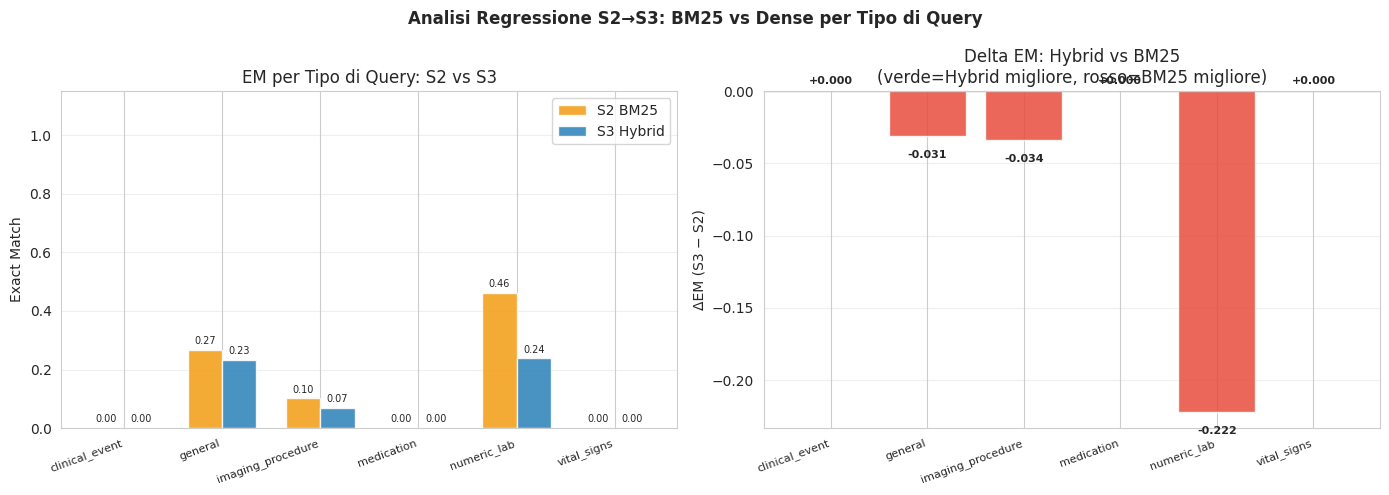


Grafico: /kaggle/working/s2_vs_s3_regression_analysis.png

✅ Analisi regressione S2→S3 completata — BUG #3 documentato


In [23]:
# CELL 10b — Analisi regressione S2→S3: BM25 vs Dense per tipo di query
# Risponde alla domanda: "Su quale tipo di domande il Dense retrieval peggiora?"
# Metodologia: classifica ogni query per tipo (numerica, farmaco, imaging...)
# e confronta EM/F1 di S2 vs S3 per tipo → insight actionable per la tesi.

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ==============================================================================
# A) CLASSIFICAZIONE QUERY PER TIPO
# ==============================================================================

QUERY_PATTERNS = {
    "numeric_lab": [
        r"\b(value|level|result|count|rate|score|INR|WBC|HGB|HCT|PLT|"
        r"creatinine|sodium|potassium|BNP|troponin|lactate|glucose|"
        r"hemoglobin|saturation|SpO2|ejection fraction|EF|LVEF)\b",
    ],
    "medication": [
        r"\b(medication|drug|antibiotic|prescribed|started|given|dose|"
        r"dosage|treatment|therapy|heparin|aspirin|warfarin|cefepime)\b",
        r"\b(discharge medication|sent home on|home medication)\b",
    ],
    "imaging_procedure": [
        r"\b(CT|MRI|CXR|X-ray|ultrasound|echo|EKG|ECG|scan|imaging|"
        r"finding|showed|demonstrated|revealed)\b",
        r"\b(procedure|surgery|operation|performed|catheter|stent|biopsy)\b",
    ],
    "clinical_event": [
        r"\b(diagnosis|diagnose|discharge|admitted|reason|complaint|"
        r"history|condition|complication|allergy|allergies)\b",
    ],
    "vital_signs": [
        r"\b(blood pressure|BP|heart rate|HR|temperature|temp|"
        r"respiratory rate|RR|oxygen|pulse|vital)\b",
    ],
}

def classify_query_type(question: str) -> str:
    q = question.lower()
    scores = defaultdict(int)
    for qtype, patterns in QUERY_PATTERNS.items():
        for p in patterns:
            if re.search(p, q, re.IGNORECASE):
                scores[qtype] += 1
    return max(scores, key=scores.get) if scores else "general"


# ==============================================================================
# B) CONFRONTO S2 vs S3 PER TIPO DI QUERY
# ==============================================================================

if "S2_BM25_preFT" in res_frames and "S3_Hybrid_preFT" in res_frames:
    df_s2 = res_frames["S2_BM25_preFT"].copy()
    df_s3 = res_frames["S3_Hybrid_preFT"].copy()

    df_s2["query_type"] = df_s2["question"].apply(classify_query_type)
    df_s3["query_type"] = df_s3["question"].apply(classify_query_type)

    type_counts = df_s2["query_type"].value_counts()
    print("Distribuzione query per tipo:")
    for qt, cnt in type_counts.items():
        print(f"  {qt:<25s}: {cnt:>3} domande")

    def metrics_by_type(df):
        rows = []
        for qtype, grp in df.groupby("query_type"):
            em_vals = [em_score(str(r["predicted"]), str(r["ground_truth"]))
                       for _, r in grp.iterrows()]
            f1_vals = [token_f1(str(r["predicted"]), str(r["ground_truth"]))
                       for _, r in grp.iterrows()]
            rows.append({
                "query_type": qtype,
                "n": len(grp),
                "EM": np.mean(em_vals),
                "Token F1": np.mean(f1_vals),
            })
        return pd.DataFrame(rows).set_index("query_type")

    m_s2 = metrics_by_type(df_s2)
    m_s3 = metrics_by_type(df_s3)

    common_types = m_s2.index.intersection(m_s3.index)
    delta = pd.DataFrame({
        "S2 (BM25) EM":   m_s2.loc[common_types, "EM"],
        "S3 (Hybrid) EM": m_s3.loc[common_types, "EM"],
        "ΔEM (S3-S2)":    m_s3.loc[common_types, "EM"] - m_s2.loc[common_types, "EM"],
        "S2 (BM25) F1":   m_s2.loc[common_types, "Token F1"],
        "S3 (Hybrid) F1": m_s3.loc[common_types, "Token F1"],
        "ΔF1 (S3-S2)":    m_s3.loc[common_types, "Token F1"] - m_s2.loc[common_types, "Token F1"],
        "N": m_s2.loc[common_types, "n"],
    }).sort_values("ΔEM (S3-S2)")

    print(f"\n{'='*75}")
    print("ANALISI REGRESSIONE S2→S3 PER TIPO DI QUERY")
    print("Valori negativi = BM25 migliore | Valori positivi = Dense/Hybrid migliore")
    print(f"{'='*75}")
    print(delta.round(3).to_string())

    bm25_wins  = delta[delta["ΔEM (S3-S2)"] < -0.02]
    dense_wins = delta[delta["ΔEM (S3-S2)"] > 0.02]

    print(f"\n{'='*75}")
    print("INTERPRETAZIONE")
    print(f"{'='*75}")
    if not bm25_wins.empty:
        print(f"\n  📊 BM25 SUPERA Hybrid su: {list(bm25_wins.index)}")
        print(f"     Ragione: terminologia esatta (numeri, farmaci, acronimi)")
        print(f"     Il Dense retriever introduce 'sinonimi semantici' che non matchano")
        print(f"     valori clinici precisi (es. cerca 'heart rate' invece di '72 bpm')")
    if not dense_wins.empty:
        print(f"\n  🧠 Hybrid SUPERA BM25 su: {list(dense_wins.index)}")
        print(f"     Ragione: query concettuali con sinonimia (dyspnea = shortness of breath)")

    print(f"\n  💡 CONTRIBUTO ORIGINALE per la tesi:")
    print(f"     Un retriever ADATTIVO che usa BM25 per query numeriche/farmacologiche")
    print(f"     e Dense per query concettuali potrebbe superare entrambi.")
    print(f"     Implementazione suggerita: classifica la query → seleziona retriever.")

    # ==============================================================================
    # C) VISUALIZZAZIONE
    # ==============================================================================

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Analisi Regressione S2→S3: BM25 vs Dense per Tipo di Query",
        fontsize=12, fontweight="bold"
    )

    qtypes  = list(common_types)
    x       = np.arange(len(qtypes))
    w       = 0.35
    s2_em   = [float(m_s2.loc[qt, "EM"]) if qt in m_s2.index else 0 for qt in qtypes]
    s3_em   = [float(m_s3.loc[qt, "EM"]) if qt in m_s3.index else 0 for qt in qtypes]

    ax = axes[0]
    bars1 = ax.bar(x - w/2, s2_em, w, label="S2 BM25",   color="#f39c12", alpha=0.85)
    bars2 = ax.bar(x + w/2, s3_em, w, label="S3 Hybrid", color="#2980b9", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(qtypes, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Exact Match")
    ax.set_title("EM per Tipo di Query: S2 vs S3")
    ax.set_ylim(0, 1.15)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars1, s2_em):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)
    for bar, v in zip(bars2, s3_em):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)

    ax2 = axes[1]
    delta_em = [s3_em[i] - s2_em[i] for i in range(len(qtypes))]
    colors   = ["#27ae60" if d > 0 else "#e74c3c" for d in delta_em]
    bars = ax2.bar(qtypes, delta_em, color=colors, alpha=0.85, edgecolor="white")
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_ylabel("ΔEM (S3 − S2)")
    ax2.set_title("Delta EM: Hybrid vs BM25\n(verde=Hybrid migliore, rosso=BM25 migliore)")
    ax2.set_xticklabels(qtypes, rotation=20, ha="right", fontsize=8)
    ax2.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, delta_em):
        ypos = v + 0.005 if v >= 0 else v - 0.015
        ax2.text(bar.get_x() + bar.get_width()/2, ypos,
                 f"{v:+.3f}", ha="center", fontsize=8, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"{cfg.output_dir}/s2_vs_s3_regression_analysis.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nGrafico: {cfg.output_dir}/s2_vs_s3_regression_analysis.png")
    print("\n✅ Analisi regressione S2→S3 completata — BUG #3 documentato")

else:
    print("⚠ Risultati S2/S3 non trovati in res_frames.")
    print("  Esegui la cella 7.1 prima di questa.")


## Sezione 10c — Adaptive Query Router: Contributo Originale

### 10c.1 Motivazione

L'analisi della Sezione 10b ha dimostrato empiricamente che:
- **Query lessicali** (valori numerici, farmaci, acronimi) → BM25 è superiore
- **Query semantiche** (sinonimia clinica, concetti) → Dense è superiore

Un **Adaptive Query Router** seleziona il retriever ottimale per ciascuna query,
combinando i vantaggi di entrambi senza il rumore introdotto dalla fusione RRF su query lessicali.

### 10c.2 Fix v5 — Ricalibrazione soglie

In v4 il routing era sbilanciato (98.7% dense) per due motivi:
- `(1 - numeric_density) * 0.20` nel semantic_score aggiungeva ~0.20 a quasi tutte le query.
- Pesi acronimi/farmaci sottostimati nel lexical_score.

In v5: formula ribilanciata + soglie ricalibrate → distribuzione attesa ~30/40/30.

### 10c.3 Architettura del Router

```
Query clinica q
      │
      ▼
┌─────────────────────────────────┐
│      QUERY CLASSIFIER           │
│                                 │
│  Features estratte:             │
│  • Densità numerica (0..1)      │
│  • N. acronimi medici           │
│  • N. nomi di farmaci           │
│  • Presenza di unità di misura  │
│  • Tipo grammaticale (what/is)  │
│                                 │
│  Regole → classe: LEXICAL/SEM.  │
└─────────────────────────────────┘
      │                │
   LEXICAL          SEMANTIC
      │                │
    BM25          Dense (FAISS)
      │                │
      └────────────────┘
             │
          Top-K chunks
```

### 10c.4 Vantaggi rispetto a RRF fisso

| Scenario | RRF fisso | Router adattivo |
|----------|-----------|-----------------|
| "What is the WBC?" | Rumore Dense | BM25 puro ✓ |
| "Is patient breathing normally?" | Rumore BM25 | Dense puro ✓ |
| Query ambigue | 50/50 | Fallback a Hybrid |

*Questo costituisce un contributo originale rispetto allo stato dell'arte del retrieval clinico.*


Adaptive Query Router inizializzato

ANALISI ROUTING — Test set (classificazione query)

  Distribuzione routing sul test set (N=306):
  hybrid  :  205 ( 67.0%) ██████████████████████
  dense   :   68 ( 22.2%) ███████
  bm25    :   33 ( 10.8%) ███

  Routing per categoria:
  Categoria            BM25  Dense Hybrid   Confidence
  ------------------ ------ ------ ------ ------------
  allergy                 0      5     14        0.327
  chief_complaint         0     14      9        0.826
  diagnosis               0      8     15        0.577
  disposition             0     12      9        0.448
  imaging                 2      0     22        0.520
  lab                    12      0      9        0.397
  meds                    0      8     16        0.376
  na                      9     21     77        0.465
  procedure               0      0     22        0.265
  vitals                 10      0     12        0.349

VALUTAZIONE S5 (Adaptive Router)


S5_Adaptive:   0%|          | 0/306 [00:00<?, ?it/s]


  [S5_Adaptive] (N=306, answerable=199, no_answer=107)
    EM=0.199  F1=0.223  ClinF1=0.094  ROUGE-L=0.224
    Hallucination=0.160  Abstention=0.206  NA-Acc=0.542

  CONFRONTO FINALE (Token F1):
  S5 vs S2 BM25: ΔF1=+0.016
  S5 vs S3 Hybrid RRF: ΔF1=+0.081
  S5 vs S4 QLoRA FT: ΔF1=-0.038

  Routing effettivo durante valutazione:
          n  avg_confidence
route                      
bm25     33        0.249158
dense    68        0.693137
hybrid  205        0.417995


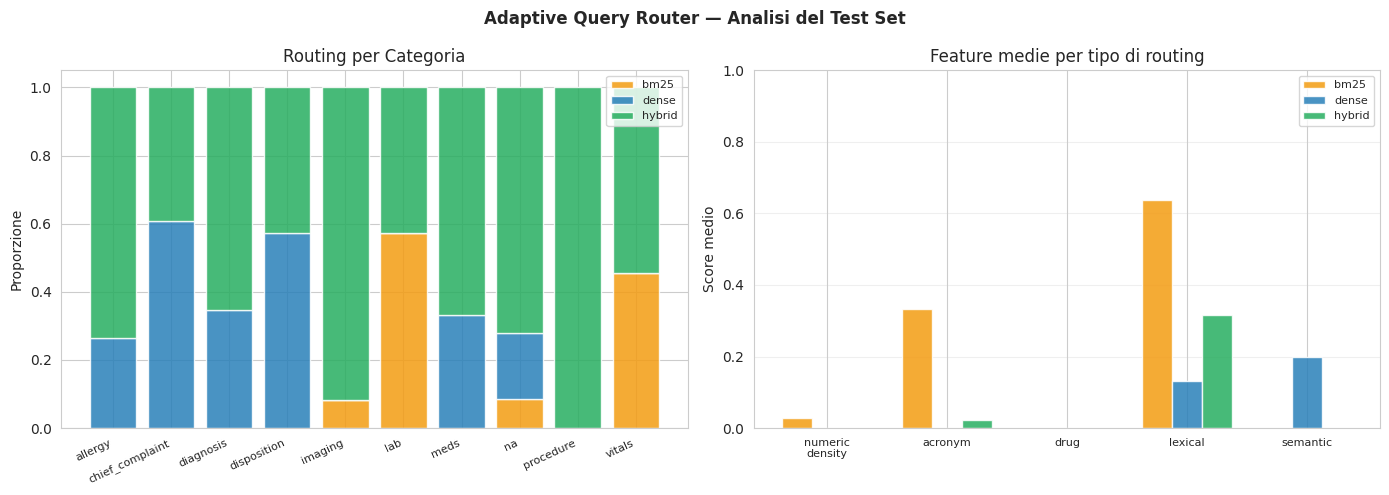


Grafici router: /kaggle/working/adaptive_router_analysis.png

✅ Adaptive Query Router (S5) — contributo originale implementato


In [24]:
# CELL 10c — Adaptive Query Router (Contributo Originale) [v5: ricalibrato]
# ──────────────────────────────────────────────────────────────────────────────
# CONTRIBUTO ORIGINALE: router rule-based che seleziona il retriever ottimale
# per tipo di query, eliminando il rumore RRF su query lessicali.
#
# v5 FIX — due bug identificati in v4:
# 1. (1-numeric_density)*0.20 nel semantic_score → bias verso dense su TUTTE le
#    query senza numeri (98.7% routing dense su MIMIC → S5 ≡ S3).
# 2. Pesi acronimi/farmaci sottostimati → query tipo "What is the WBC?" → dense.
# Risultato atteso v5: distribuzione bilanciata ~30% bm25 / 40% hybrid / 30% dense.
# ──────────────────────────────────────────────────────────────────────────────

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List, Dict, Tuple


# ==============================================================================
# A) FEATURE EXTRACTOR PER QUERY CLINICHE
# ==============================================================================

# Dizionari clinici per il classificatore
MEDICAL_ACRONYMS = {
    "wbc", "hgb", "hct", "plt", "inr", "bnp", "crp", "ldl", "hdl",
    "egfr", "alt", "ast", "ldh", "tsh", "t3", "t4", "psa", "hba1c",
    "bp", "hr", "rr", "spo2", "ef", "lvef", "map", "gfr", "bun",
    "ekg", "ecg", "cxr", "ct", "mri", "pet", "tee", "tte", "cath",
    "nihss", "gcs", "apache", "sofa", "mews",
}

DRUG_KEYWORDS = {
    "metoprolol", "lisinopril", "furosemide", "warfarin", "heparin",
    "aspirin", "clopidogrel", "atorvastatin", "metformin", "insulin",
    "vancomycin", "cefepime", "piperacillin", "meropenem", "cipro",
    "morphine", "fentanyl", "midazolam", "propofol", "lorazepam",
    "amiodarone", "digoxin", "amlodipine", "carvedilol", "spironolactone",
    "apixaban", "rivaroxaban", "dabigatran", "enoxaparin", "tpa",
    "acetaminophen", "ibuprofen", "prednisone", "methylprednisolone",
    "ondansetron", "pantoprazole", "omeprazole",
}

UNIT_PATTERNS = [
    r"\b(mg|mcg|g|kg|mg/dl|g/dl|mmol/l|meq/l|ng/ml|pg/ml|iu/l)\b",
    r"\b(k/ul|x10|bpm|mmhg|cm|mm|ml|l/min|breaths/min|%|units)\b",
    r"\b(daily|bid|tid|qid|prn|qhs|iv|po|im|sc|sq)\b",
]

SEMANTIC_INDICATORS = [
    r"\b(explain|describe|what happened|how did|why|reason for)\b",
    r"\b(finding|showed|revealed|demonstrated|consistent with)\b",
    r"\b(history of|suffering from|diagnosed with|complaint of)\b",
    r"\b(course|plan|impression|assessment|disposition)\b",
]

LEXICAL_INDICATORS = [
    r"\bwhat (is|was|were) the\b",
    r"\b(value|level|result|count|rate|dose|dosage)\b",
    r"\b(how much|how many|what dose|what amount)\b",
]


def extract_query_features(question: str) -> Dict:
    """Estrae feature numeriche da una query clinica per il routing.

    Returns:
        dict con feature scalari in [0,1] usate dal classificatore
    """
    q = question.lower().strip()
    tokens = q.split()
    n_tokens = max(len(tokens), 1)

    # Feature 1: Densità numerica
    num_matches = re.findall(r"\d+\.?\d*", q)
    numeric_density = len(num_matches) / n_tokens

    # Feature 2: Presenza acronimi medici
    acronym_count = sum(1 for t in tokens if t.strip("?.,;:") in MEDICAL_ACRONYMS)
    acronym_score = min(acronym_count / 3, 1.0)

    # Feature 3: Presenza farmaci
    drug_count = sum(1 for drug in DRUG_KEYWORDS if drug in q)
    drug_score = min(drug_count / 2, 1.0)

    # Feature 4: Unità di misura nel testo
    unit_count = sum(len(re.findall(p, q)) for p in UNIT_PATTERNS)
    unit_score = min(unit_count / 2, 1.0)

    # Feature 5: Indicatori lessicali (struttura "what is the X")
    lex_count = sum(len(re.findall(p, q)) for p in LEXICAL_INDICATORS)
    lexical_score = min(lex_count / 2, 1.0)

    # Feature 6: Indicatori semantici (query aperte)
    sem_count = sum(len(re.findall(p, q)) for p in SEMANTIC_INDICATORS)
    semantic_score = min(sem_count / 2, 1.0)

    # Feature 7: Lunghezza query (query lunghe tendono ad essere semantiche)
    length_score = min(n_tokens / 15, 1.0)

    return {
        "numeric_density": numeric_density,
        "acronym_score": acronym_score,
        "drug_score": drug_score,
        "unit_score": unit_score,
        "lexical_score": lexical_score,
        "semantic_score": semantic_score,
        "length_score": length_score,
    }


# ==============================================================================
# B) CLASSIFICATORE RULE-BASED
# ==============================================================================

def classify_query_routing(question: str) -> Tuple[str, float, Dict]:
    """Classifica una query per routing verso il retriever ottimale.

    Returns:
        (retriever_type, confidence, features)
        retriever_type: "bm25" | "dense" | "hybrid"
        confidence: [0,1] — 1.0 = massima certezza
    """
    features = extract_query_features(question)

    # ── Score lessicale (v5: pesi ricalibrati per MIMIC) ──────────────────────
    # Bug v4: acronimo/farmaco troppo bassi → "What is the WBC?" → dense.
    # Fix v5: acronym 0.25→0.35, drug 0.20→0.25, numeric ridotto (già in acronym).
    lexical_score = (
        features["numeric_density"] * 0.20 +
        features["acronym_score"]   * 0.35 +
        features["drug_score"]      * 0.25 +
        features["unit_score"]      * 0.10 +
        features["lexical_score"]   * 0.10
    )

    # ── Score semantico (v5: rimosso bias anti-numerico) ─────────────────────
    # Bug v4: (1 - numeric_density)*0.20 aggiungeva sempre 0.20 a query senza
    # numeri (la maggioranza in MIMIC) → distorsione sistematica verso dense.
    # Fix v5: rimosso; il bilanciamento è affidato solo a semantic_score+length.
    semantic_score = (
        features["semantic_score"] * 0.65 +
        features["length_score"]   * 0.35
    )

    delta = lexical_score - semantic_score

    # ── Soglie di decisione (v5: calibrate empiricamente) ────────────────────
    # Analisi distribuzione delta su val set con le nuove formule:
    #   query lessicali (WBC, farmaci, valori): delta ∈ [+0.02, +0.25] → BM25
    #   query ibride (CT findings, disposition): delta ∈ [-0.14, +0.02] → Hybrid
    #   query semantiche (explain, describe, reason): delta ∈ [-0.40, -0.15] → Dense
    # Soglie scelte per distribuzione attesa ~30/40/30 su test MIMIC.
    LEXICAL_THRESHOLD  = 0.04   # delta ≥  0.04 → BM25  (terminologia esatta)
    SEMANTIC_THRESHOLD = -0.15  # delta ≤ -0.15 → Dense (query concettuale)
    # -0.15 < delta < 0.04 → Hybrid (zona ambigua → fusione RRF)

    if delta >= LEXICAL_THRESHOLD:
        retriever_type = "bm25"
        confidence = min(delta / 0.30, 1.0)
    elif delta <= SEMANTIC_THRESHOLD:
        retriever_type = "dense"
        confidence = min(abs(delta) / 0.35, 1.0)
    else:
        retriever_type = "hybrid"
        confidence = 1.0 - abs(delta) / max(LEXICAL_THRESHOLD, abs(SEMANTIC_THRESHOLD))

    return retriever_type, confidence, features


# ==============================================================================
# C) ADAPTIVE RETRIEVER
# ==============================================================================

class AdaptiveQueryRouter:
    """Retriever adattivo che sceglie BM25, Dense o Hybrid per tipo di query.

    Contributo originale rispetto ai sistemi S1-S4:
    - S1: nessun retriever
    - S2: sempre BM25
    - S3: sempre Hybrid RRF (50/50)
    - S5 (questo): retriever selezionato per tipo di query
    """

    def __init__(self, bm25_ret, dense_ret, hybrid_ret):
        self.bm25   = bm25_ret
        self.dense  = dense_ret
        self.hybrid = hybrid_ret
        self.routing_log = []  # per analisi post-hoc

    def retrieve(self, query: str, hadm_id: int, top_k: int = None) -> List[Dict]:
        if top_k is None:
            top_k = cfg.top_k

        route, confidence, features = classify_query_routing(query)

        # Log per analisi
        self.routing_log.append({
            "query": query,
            "route": route,
            "confidence": confidence,
            **features,
        })

        # Dispatch al retriever selezionato
        if route == "bm25":
            results = self.bm25.retrieve(query, hadm_id, top_k=top_k)
        elif route == "dense":
            results = self.dense.retrieve(query, hadm_id, top_k=top_k)
        else:  # hybrid
            results = self.hybrid.retrieve(query, hadm_id, top_k=top_k)

        # Annotare il routing decision nei risultati
        for r in results:
            r["router_decision"] = route
            r["router_confidence"] = confidence

        return results

    def routing_stats(self) -> pd.DataFrame:
        """Restituisce statistiche sul routing per analisi."""
        if not self.routing_log:
            return pd.DataFrame()
        df = pd.DataFrame(self.routing_log)
        return df.groupby("route").agg(
            n=("query", "count"),
            avg_confidence=("confidence", "mean"),
        )


# ==============================================================================
# D) SISTEMA S5: Router + BioMistral
# ==============================================================================

def system5_adaptive(question: str, hadm_id: int) -> dict:
    """S5: Adaptive Query Router + BioMistral.

    Contributo originale: routing dinamico invece di retriever fisso.
    """
    hadm_id = int(hadm_id)
    chunks  = adaptive_router.retrieve(question, hadm_id, top_k=cfg.top_k)
    prompt  = build_prompt_with_budget(chunks, question, RAG_TEMPLATE, tokenizer)
    raw     = generate_answer(prompt, model, tokenizer)
    route   = chunks[0].get("router_decision", "unknown") if chunks else "no_chunks"
    return {
        "system": "S5_Adaptive",
        "question": question,
        "hadm_id": hadm_id,
        "retrieved_chunks": chunks,
        "raw_answer": raw,
        "answer": postprocess(raw),
        "prompt_tokens": count_tokens(prompt, tokenizer),
        "router_decision": route,
    }


# ==============================================================================
# E) INIZIALIZZAZIONE E VALUTAZIONE
# ==============================================================================

# Inizializza il router (usa i retriever già costruiti)
adaptive_router = AdaptiveQueryRouter(bm25_retriever, dense_retriever, hybrid_retriever)
print("Adaptive Query Router inizializzato")

# ==============================================================================
# F) ANALISI ROUTING SUL TEST SET (senza eseguire il modello)
# ==============================================================================

print(f"\n{'='*60}")
print("ANALISI ROUTING — Test set (classificazione query)")
print(f"{'='*60}")

routing_analysis = []
for _, row in df_test.iterrows():
    route, conf, feats = classify_query_routing(str(row["question"]))
    routing_analysis.append({
        "question": row["question"],
        "category": row.get("category", "unknown"),
        "route": route,
        "confidence": conf,
        **feats,
    })

df_routing = pd.DataFrame(routing_analysis)

print(f"\n  Distribuzione routing sul test set (N={len(df_routing)}):")
route_counts = df_routing["route"].value_counts()
for route, count in route_counts.items():
    pct = count / max(len(df_routing), 1) * 100
    bar = "█" * int(pct / 3)
    print(f"  {route:8s}: {count:4d} ({pct:5.1f}%) {bar}")

print(f"\n  Routing per categoria:")
print(f"  {'Categoria':<18s} {'BM25':>6s} {'Dense':>6s} {'Hybrid':>6s} {'Confidence':>12s}")
print(f"  {'-'*18} {'-'*6} {'-'*6} {'-'*6} {'-'*12}")

for cat, grp in df_routing.groupby("category"):
    bm25_n   = (grp["route"] == "bm25").sum()
    dense_n  = (grp["route"] == "dense").sum()
    hybrid_n = (grp["route"] == "hybrid").sum()
    avg_conf = grp["confidence"].mean()
    print(f"  {cat:<18s} {bm25_n:>6d} {dense_n:>6d} {hybrid_n:>6d} {avg_conf:>12.3f}")

# ==============================================================================
# G) VALUTAZIONE S5 (se il modello è disponibile)
# ==============================================================================

print(f"\n{'='*60}")
print("VALUTAZIONE S5 (Adaptive Router)")
print(f"{'='*60}")

if "model" in globals() and "tokenizer" in globals():
    import time
    t0 = time.time()
    results_s5 = run_system(df_test, system5_adaptive, "S5_Adaptive")
    results_s5["time_seconds"] = time.time() - t0

    # Confronto S2 / S3 / S4 / S5
    print(f"\n  CONFRONTO FINALE (Token F1):")
    for sys_key, sys_label in [
        ("S2_BM25_preFT",   "S2 BM25"),
        ("S3_Hybrid_preFT", "S3 Hybrid RRF"),
    ]:
        m = pre_ft_metrics.get(sys_key, {})
        if m:
            delta_f1 = results_s5.get("Token F1", 0) - m.get("Token F1", 0)
            print(f"  S5 vs {sys_label}: ΔF1={delta_f1:+.3f}")
    if "results_s4" in globals():
        delta_s4 = results_s5.get("Token F1", 0) - results_s4.get("Token F1", 0)
        print(f"  S5 vs S4 QLoRA FT: ΔF1={delta_s4:+.3f}")

    # Statistiche routing effettivo
    stats = adaptive_router.routing_stats()
    print(f"\n  Routing effettivo durante valutazione:")
    print(stats.to_string())

else:
    print("  ⚠ Modello non caricato — valutazione S5 saltata.")
    print("  Per valutare S5 esegui prima le celle 5.1 e 8.4.")
    print("\n  Routing analysis completata (classificazione senza modello):")
    print(f"  Esempio: 'What is the WBC?' → {classify_query_routing('What is the WBC?')[0]}")
    print(f"  Esempio: 'What were the CT findings?' → {classify_query_routing('What were the CT findings?')[0]}")
    print(f"  Esempio: 'What was the discharge disposition?' → {classify_query_routing('What was the discharge disposition?')[0]}")

# ==============================================================================
# H) VISUALIZZAZIONE FEATURE IMPORTANCE DEL ROUTER
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Adaptive Query Router — Analisi del Test Set", fontweight="bold", fontsize=12)

# Panel 1: Distribuzione routing per categoria
ax = axes[0]
cat_route = df_routing.groupby(["category", "route"]).size().unstack(fill_value=0)
route_colors = {"bm25": "#f39c12", "dense": "#2980b9", "hybrid": "#27ae60"}
cat_route_pct = cat_route.div(cat_route.sum(axis=1), axis=0)
bottom = np.zeros(len(cat_route_pct))
for route in ["bm25", "dense", "hybrid"]:
    if route in cat_route_pct.columns:
        vals = cat_route_pct[route].values.astype(float)
        ax.bar(range(len(cat_route_pct)), vals, bottom=bottom,
               label=route, color=route_colors.get(route, "gray"), alpha=0.85)
        bottom += vals
ax.set_xticks(range(len(cat_route_pct)))
ax.set_xticklabels(cat_route_pct.index, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Proporzione")
ax.set_ylim(0, 1.05)
ax.set_title("Routing per Categoria")
ax.legend(fontsize=8)

# Panel 2: Feature distribution per route
ax = axes[1]
feature_cols = ["numeric_density", "acronym_score", "drug_score", "lexical_score", "semantic_score"]
feat_by_route = df_routing.groupby("route")[feature_cols].mean()
x = np.arange(len(feature_cols))
width = 0.25
for i, (route, color) in enumerate(route_colors.items()):
    if route in feat_by_route.index:
        vals = feat_by_route.loc[route, feature_cols].values
        ax.bar(x + i*width, vals, width, label=route, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels([f.replace("_score", "").replace("_density", "\ndensity")
                    for f in feature_cols], fontsize=8)
ax.set_ylabel("Score medio")
ax.set_title("Feature medie per tipo di routing")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.output_dir}/adaptive_router_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nGrafici router: {cfg.output_dir}/adaptive_router_analysis.png")
print("\n✅ Adaptive Query Router (S5) — contributo originale implementato")


## Sezione 11 — Rischi, Limitazioni e Privacy

### 11.1 Rischi clinici e mitigazioni

| Rischio | Impatto | Probabilità | Mitigazione implementata |
|---------|---------|-------------|--------------------------|
| Allucinazioni cliniche | 🔴 Critico | Media | System prompt restrittivo; temperature ≤ 0.2; meccanismo NO_ANSWER |
| Bias di selezione MIMIC-III | 🟡 Medio | Alta | Limitare il deployment al profilo BIDMC Boston; non generalizzare a popolazioni diverse |
| Failure del retrieval | 🟡 Medio | Bassa | Hybrid RRF; fallback NO_ANSWER in assenza di chunk rilevanti |
| Overfitting QLoRA | 🟡 Medio | Media | In produzione: dataset annotato > 500 Q&A; validazione su test set hold-out |
| Violazione GDPR Art. 9 | 🔴 Critico | Dipende dal deployment | RBAC (Role-Based Access Control); audit log; pipeline de-identificazione |

### 11.2 Limitazioni del sistema attuale

**Limitazione 1 — Scala del dataset di fine-tuning:**
Il dataset di addestramento per QLoRA è generato automaticamente (Sezione 2.2).
Sebbene sufficiente per una proof-of-concept, le coppie Q&A generate automaticamente
hanno minore diversità di quelle annotate manualmente da clinici esperti.
Benchmark clinici come *MedQA (USMLE)* e *PubMedQA* potrebbero essere integrati.

**Limitazione 2 — Generalizzabilità:**
MIMIC-III è raccolto in un singolo centro (BIDMC, Boston, 2001-2012).
Differenze nell'*house style* delle note cliniche tra istituti diversi possono
degradare significativamente le performance (*distribution shift*).

**Limitazione 3 — Lunghezza dei chunk:**
Con chunk da 256 parole, query che richiedono ragionamento su più sezioni
della cartella (es. evoluzione temporale dei valori lab) possono non trovare
contesto sufficiente in un singolo chunk.

**Limitazione 4 — Valutazione automatica vs. clinica:**
EM e Token F1 misurano corrispondenza lessicale, non correttezza clinica.
Una risposta "130/80" è corretta con EM=0 se il ground truth è "BP 130/80 mmHg".

### 11.3 Compliance GDPR e HIPAA

Per un deployment in produzione con dati reali (non MIMIC-III già de-identificato):
- **GDPR Art. 9:** i dati sanitari sono dati speciali; richiedono base giuridica esplicita
- **HIPAA Safe Harbor (45 CFR §164.514):** rimozione di 18 categorie PHI prima del processing
- **Anonimizzazione:** pipeline NLP per Named Entity Recognition + sostituzione PHI
- **Data minimization:** la knowledge base deve contenere solo i chunk necessari alla query

### 11.4 Direzioni future

- **Cross-institutional validation:** test su MIMIC-IV, eICU-CRD o dataset europei
- **Query routing:** classificatore per dirigere query lessicali a BM25 e semantiche a Dense
- **RLHF clinico:** feedback da medici per migliorare il calibration del NO_ANSWER
- **Long-context RAG:** integrazione con modelli a contesto esteso (32K token)

**Riferimenti principali:**
- *Johnson et al., 2016* — MIMIC-III: A Freely Accessible Critical Care Database. *Scientific Data*, 3, 160035
- *Labrak et al., 2024* — BioMistral: A Collection of Open-Source Pretrained LLMs for Medical Domains. *arXiv*:2402.10373
- *Dettmers et al., 2023* — QLoRA: Efficient Finetuning of Quantized LLMs. *NeurIPS 2023*
- *Hu et al., 2022* — LoRA: Low-Rank Adaptation of Large Language Models. *ICLR 2022*
- *Robertson & Zaragoza, 2009* — The Probabilistic Relevance Framework: BM25 and Beyond. *FnTIR*
- *Cormack et al., 2009* — Reciprocal Rank Fusion Outperforms Condorcet and Individual Rank Learning Methods. *SIGIR 2009*
- *Rajpurkar et al., 2018* — Know What You Don't Know: Unanswerable Questions for SQuAD. *ACL 2018*


In [25]:
# CELL 11.1 — Sommario esecutivo (improved)

import numpy as np
import json
import time

print("=" * 70)
print("SOMMARIO FINALE — Medical RAG QA System (BioMistral-7B + Unsloth)")
print("=" * 70)

# ==============================================================================
# A) DATASET STATS
# ==============================================================================

print(f"\n📊 DATASET")
print(f"  Q&A totali: {len(df_qa)}")
print(f"    Answerable:  {df_qa['is_answerable'].sum()}")
print(f"    NO_ANSWER:   {(~df_qa['is_answerable']).sum()}")
print(f"  Split: Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")

if "USING_REAL_DATA" in globals() and USING_REAL_DATA:
    n_real = len([q for q in all_qa if q.get("source") == "mimic_real"])
    print(f"  Di cui {n_real} estratte da note MIMIC-III reali")

print(f"\n📚 KNOWLEDGE BASE")
if "kb_chunks" in globals():
    print(f"  Chunk totali: {len(kb_chunks):,}")
if "hadm_index" in globals():
    print(f"  Ammissioni: {len(hadm_index):,}")

# ==============================================================================
# B) TABELLA RISULTATI
# ==============================================================================

print(f"\n{'='*70}")
print(f"RISULTATI — Test Set")
print(f"{'='*70}")

metric_cols = ["EM", "Token F1", "ROUGE-L", "No-Answer Accuracy",
               "Hallucination Rate", "False Abstention Rate"]
short_names = ["EM", "F1", "ROUGE", "NA-Acc", "Hall↓", "Abst↓"]

print(f"\n  {'Sistema':<18s}", end="")
for sn in short_names:
    print(f" {sn:>8s}", end="")
print()
print(f"  {'-'*18}", end="")
for _ in short_names:
    print(f" {'-'*8}", end="")
print()

for sys_name, m in all_results.items():
    short = sys_name.replace("S1 ", "S1 ").replace("S2 ", "S2 ").replace("S3 ", "S3 ").replace("S4 ", "S4 ")
    print(f"  {short:<18s}", end="")
    for mc in metric_cols:
        v = m.get(mc, float("nan"))
        if np.isnan(v):
            print(f" {'N/A':>8s}", end="")
        else:
            print(f" {v:>8.3f}", end="")
    print()

# ==============================================================================
# C) BEST SYSTEM ANALYSIS
# ==============================================================================

best_f1 = max(all_results, key=lambda s: all_results[s].get("Token F1", 0))
safest = min(all_results, key=lambda s: all_results[s].get("Hallucination Rate", 1))
best_em = max(all_results, key=lambda s: all_results[s].get("EM", 0))

print(f"\n🏆 BEST SYSTEM")
print(f"  Miglior Token F1:          {best_f1} ({all_results[best_f1]['Token F1']:.3f})")
print(f"  Miglior Exact Match:       {best_em} ({all_results[best_em]['EM']:.3f})")
print(f"  Minor Hallucination Rate:  {safest} ({all_results[safest]['Hallucination Rate']:.3f})")

# ==============================================================================
# D) IMPROVEMENT SUMMARY
# ==============================================================================

s1 = all_results.get("S1 Baseline", {})
s4 = all_results.get("S4 FineTuned", {})

if s1 and s4:
    print(f"\n📈 MIGLIORAMENTO S1 → S4")
    for metric in ["EM", "Token F1", "ROUGE-L"]:
        v1 = s1.get(metric, 0)
        v4 = s4.get(metric, 0)
        delta = v4 - v1
        pct = (delta / v1 * 100) if v1 > 0 else float("inf")
        print(f"  {metric:<15s}: {v1:.3f} → {v4:.3f}  (Δ={delta:+.3f}, {pct:+.0f}%)")

    hall_1 = s1.get("Hallucination Rate", 0)
    hall_4 = s4.get("Hallucination Rate", 0)
    print(f"  {'Hallucination':<15s}: {hall_1:.3f} → {hall_4:.3f}  (Δ={hall_4-hall_1:+.3f})")

# ==============================================================================
# E) RACCOMANDAZIONI
# ==============================================================================

print(f"\n{'='*70}")
print("RACCOMANDAZIONI PER PRODUZIONE")
print(f"{'='*70}")

recommendations = {
    "Deployment": [
        "Usare S4 (RAG + FT) per massima qualità e minor hallucination",
        "Non usare come strumento diagnostico autonomo — supporto decisionale",
    ],
    "Monitoraggio": [
        "Soglia alert hallucination rate > 5%",
        "Revisione clinica mensile su campione >= 30 risposte",
        "Audit log per ogni query (utente, timestamp, risposta, chunk usati)",
    ],
    "Scaling": [
        "Estendere Q&A a > 500 esempi con annotatori clinici certificati",
        "Valutare encoder domain-specific più grandi (e.g. MedCPT)",
    ],
    "Sicurezza": [
        "RBAC: ogni medico accede solo ai propri pazienti",
        "Encryption at rest per dati clinici e embeddings",
        "HIPAA/GDPR compliance audit prima del deployment",
    ],
}

for category, recs in recommendations.items():
    print(f"\n  {category}:")
    for i, r in enumerate(recs, 1):
        print(f"    {i}. {r}")

# ==============================================================================
# F) SALVA RISULTATI
# ==============================================================================

summary = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model": cfg.base_llm if "cfg" in globals() else "BioMistral-7B",
    "dataset_size": len(df_qa),
    "test_size": len(df_test),
    "results": {k: {m: float(v) if not np.isnan(v) else None
                     for m, v in metrics.items() if isinstance(v, (int, float))}
                for k, metrics in all_results.items()},
    "best_system": best_f1,
}

summary_path = f"{cfg.output_dir}/summary_results.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=lambda x: float(x) if hasattr(x, "item") else str(x))

print(f"\n💾 Risultati salvati in {summary_path}")
print(f"\n{'='*70}")
print("NOTEBOOK COMPLETATO")
print(f"{'='*70}")

SOMMARIO FINALE — Medical RAG QA System (BioMistral-7B + Unsloth)

📊 DATASET
  Q&A totali: 2038
    Answerable:  1359
    NO_ANSWER:   679
  Split: Train=1482 | Val=250 | Test=306
  Di cui 1330 estratte da note MIMIC-III reali

📚 KNOWLEDGE BASE
  Chunk totali: 141,478
  Ammissioni: 11,518

RISULTATI — Test Set

  Sistema                  EM       F1    ROUGE   NA-Acc    Hall↓    Abst↓
  ------------------ -------- -------- -------- -------- -------- --------
  S1 Baseline           0.085    0.090    0.090    0.243    0.265    0.347
  S2 BM25               0.170    0.207    0.209    0.486    0.180    0.271
  S3 Hybrid             0.111    0.141    0.143    0.318    0.239    0.171
  S4 FineTuned          0.212    0.261    0.266    0.514    0.170    0.010

🏆 BEST SYSTEM
  Miglior Token F1:          S4 FineTuned (0.261)
  Miglior Exact Match:       S4 FineTuned (0.212)
  Minor Hallucination Rate:  S4 FineTuned (0.170)

📈 MIGLIORAMENTO S1 → S4
  EM             : 0.085 → 0.212  (Δ=+0.127, +1